## NEW TASKS 
1. Fix captain ×2 display in Strategy B tablesolve_wildcard_11_1_3 --> DONE
2. Change HAUL_THRESHOLD to 10Cell 5.6 (both) --> Haul threshold:             HAUL_THRESHOLD = 10 
DECISION_THRESHOLD = 0.35

3. Fix static haul probability bugCell 5.6 haul params --> DONE 
4. Add Optuna tuning cellNew cell after haul
5. Delete duplicate badge Hub cellBadge Hub cell
6. FDI labels in 3-GW transfer UIsuggest_smart_transfers_3gw_ui
7. Data refresh + CURRENT_GW updateCell 3 + pipeline rerun
8. Bruno G. verificationAfter data refresh


## NEW TASKS 14/4 
Task 1.1 \ DGW aggregation \       4,484 duplicate rows collapsed

Task 1.2  \ Price audit     \       826 players tracked, risers/fallers identified  

1.2 Patch \ Auto price fix     \    Unambiguous prices corrected

UUID Bridge      \                 366/366 current players mapped

Manual corrections\               7 wrong element_ids fixed

Martinez fix       \              Emi guaranteed over Lisandro

Optimizer updated   \             get_player_live_v2 + wn_to_uuid_corrected

## Notes for Haul 
What to set DECISION_THRESHOLD to and why
For your thesis write-up, use DECISION_THRESHOLD = 0.35. Here is the justification you can write:
At threshold 0.35 the model achieves Precision 25%, which means it is 4× better than random (base rate is 5.81%). For captaincy decisions the ranking quality measured by AUC 0.649 is the primary metric — the model correctly orders genuine haulers above non-haulers 65% of the time, compared to 50% for random selection.
For practical use, the threshold does not matter — you always use the ranked hauler_board and combine it with Weighted_xP in the blended captain score:
pythonopt_11['AI_Blended_Score'] = opt_11['Weighted_xP'] * (1 + (opt_11['Haul_Prob (%)'] / 100.0))
Salah with 57.8% haul probability and 6.66 xP gets blended score of 6.66 × 1.578 = 10.51. Gravenberch with 50% haul probability and 3.55 xP gets 3.55 × 1.50 = 5.33. The regression model correctly demotes Gravenberch in the actual captain selection because his base xP is low. The haul probability alone does not pick the captain — it is the blended score that does. So the model is already working correctly end-to-end.

In [ ]:
# %% [Cell: Master Squad Optimizer - Strategy B (Production Engine)]
# Strategy B: PRODUCTION OPTIMIZER — used for all live recommendations.

import pandas as pd
import numpy as np
from IPython.display import display

def solve_wildcard_11_1_3(budget_cap=100.0):
    # --- 1. DATA PREP ---
    pos_to_num     = {'GK': 1, 'DEF': 2, 'MID': 3, 'FWD': 4, 1:1, 2:2, 3:3, 4:4}

    leaderboard = final_leaderboard.copy()
    
    # Use the normalisation bridge to ensure perfect API pricing
    leaderboard['Price']  = leaderboard['Player'].map(lambda x: get_player_live(x).get('price', 5.5))
    
    _global_pos_map = globals().get('pos_map', {})
    _global_club_map = globals().get('club_map', {})
    
    leaderboard['Pos_ID'] = leaderboard['Player'].map(lambda x: pos_to_num.get(_global_pos_map.get(x, 'MID'), 3))
    leaderboard['Team']   = leaderboard['Player'].map(_global_club_map).fillna('Neutral')
    leaderboard['Status'] = leaderboard['Player'].map(lambda x: get_player_live(x).get('status', 'a'))
    
    leaderboard['Chance'] = leaderboard['Player'].map(
        lambda x: 100 if get_player_live(x).get('chance_of_playing_this_gw') is None else get_player_live(x).get('chance_of_playing_this_gw')
    )

    # --- 2. AVAILABILITY FILTER (Synced with global squad_availability) ---
    available_pool = leaderboard.copy()
    _av = globals().get('squad_availability')
    
    if isinstance(_av, dict):
        _sell_now = _av.get('sell_now', [])
        _doubtful = _av.get('doubtful', [])
        
        # Completely remove injured/suspended players
        available_pool = available_pool[~available_pool['Player'].isin(_sell_now)]
        
        # Heavily penalize doubtful players so they are only picked if absolutely necessary
        available_pool['Predicted_Points'] = np.where(
            available_pool['Player'].isin(_doubtful),
            available_pool['Predicted_Points'] - 10,
            available_pool['Predicted_Points']
        )
    else:
        # Fallback if the availability cell wasn't run
        available_pool = leaderboard[
            (leaderboard['Status'] == 'a') |
            ((leaderboard['Status'] == 'd') & (leaderboard['Chance'] >= 50))
        ].copy()

    n_removed = len(leaderboard) - len(available_pool)
    if n_removed > 0:
        print(f"[Availability Filter] Removed {n_removed} absolutely unavailable players from selection pool.")

    # --- 3. PENALTY TAKER WEIGHTING ---
    penalty_takers = {'M.Salah', 'Haaland', 'Palmer', 'Saka', 'B.Fernandes',
                      'Gordon', 'Solanke', 'Jimenez'}
    available_pool['Weighted_xP'] = np.where(
        available_pool['Player'].isin(penalty_takers),
        available_pool['Predicted_Points'] * 1.15,
        available_pool['Predicted_Points']
    )

    pool = available_pool.sort_values('Weighted_xP', ascending=False)

    # --- 4. BENCH FODDER ---
    bench_gk = pool[pool['Pos_ID'] == 1].nsmallest(1, 'Price')

    bench_def = pool[
        (pool['Pos_ID'] == 2) &
        (pool['Player'].map(lambda x: get_player_live(x).get('chance_of_playing_this_gw') or 100) >= 75)
    ].nsmallest(1, 'Price')
    if bench_def.empty:
       bench_def = pool[pool['Pos_ID'] == 2].nsmallest(1, 'Price')

    bench_mid = pool[
        (pool['Pos_ID'] == 3) &
        (pool['Player'].map(lambda x: get_player_live(x).get('chance_of_playing_this_gw') or 100) >= 75)
    ].nsmallest(1, 'Price')
    if bench_mid.empty:
        bench_mid = pool[pool['Pos_ID'] == 3].nsmallest(1, 'Price')

    dead_fodder = pd.concat([bench_gk, bench_def, bench_mid]).copy()
    dead_fodder['Role'] = 'Dead Fodder'

    # --- 5. CORE 12 SELECTION ---
    market = pool[~pool['Player'].isin(dead_fodder['Player'])]
    core_squad_list = []
    team_counts = dead_fodder['Team'].value_counts().to_dict()
    pos_needed  = {1: 1, 2: 4, 3: 4, 4: 3}
     
    # Inject haul signal into squad selection
    haul_map_sel = hauler_board.set_index('Player')['Haul_Prob (%)'].to_dict() if 'hauler_board' in globals() else {}
    market = market.copy()
    market['AI_Blended_Score'] = market['Weighted_xP'] * (1 + (market['Player'].map(haul_map_sel).fillna(0.0) / 50.0))
    market = market.sort_values('AI_Blended_Score', ascending=False)

    for _, player in market.iterrows():
        pid, team = player['Pos_ID'], player['Team']
        if pos_needed[pid] > 0 and team_counts.get(team, 0) < 3:
            core_squad_list.append(player)
            pos_needed[pid] -= 1
            team_counts[team] = team_counts.get(team, 0) + 1
        if len(core_squad_list) == 12:
            break

    squad = pd.concat([dead_fodder, pd.DataFrame(core_squad_list)]).reset_index(drop=True)
    if 'Role' not in squad.columns: squad['Role'] = 'Core'
    squad.loc[squad['Player'].isin(dead_fodder['Player']), 'Role'] = 'Dead Fodder'

    # --- 6. BUDGET REPAIR (Downgrade if over budget) ---
    while squad['Price'].sum() > budget_cap:
        eligible = squad[squad['Role'] != 'Dead Fodder'].copy()
        eligible['Efficiency'] = eligible['AI_Blended_Score'] / (eligible['Price'] + 0.1)
        drop_idx  = eligible.sort_values('Efficiency').index[0]
        p_to_drop = squad.loc[drop_idx]

        replacement = pool[
            (pool['Pos_ID'] == p_to_drop['Pos_ID']) &
            (~pool['Player'].isin(squad['Player'])) &
            (pool['Price'] < p_to_drop['Price'])
        ].sort_values('AI_Blended_Score', ascending=False).head(1)

        if replacement.empty: break
        squad.loc[drop_idx] = replacement.iloc[0]
        squad.loc[drop_idx, 'Role'] = 'Core'
    
    # --- 7. BUDGET UPGRADE LOOP (with infinite-loop protection) ---
    pool['AI_Blended_Score'] = pool['Weighted_xP'] * (1 + (pool['Player'].map(haul_map_sel).fillna(0.0) / 50.0))
    
    _upgrade_attempts = 0
    _MAX_UPGRADE_ATTEMPTS = 50
    _upgraded_players = set()  # prevent oscillation

    while _upgrade_attempts < _MAX_UPGRADE_ATTEMPTS:
        _upgrade_attempts += 1
        current_cost = squad['Price'].sum()
        remaining_budget = budget_cap - current_cost
        if remaining_budget <= 0.1:
            break

        upgraded = False
        core_sq = squad[squad['Role'] == 'Core'].copy()

        for idx, p_to_upgrade in core_sq.sort_values('AI_Blended_Score', ascending=True).iterrows():
            max_price = p_to_upgrade['Price'] + remaining_budget

            better_options = pool[
                (pool['Pos_ID'] == p_to_upgrade['Pos_ID']) &
                (~pool['Player'].isin(squad['Player'])) &
                (~pool['Player'].isin(_upgraded_players)) &  # prevent oscillation
                (pool['Price'] <= max_price) &
                (pool['AI_Blended_Score'] > p_to_upgrade['AI_Blended_Score'] + 0.1)
            ].sort_values('AI_Blended_Score', ascending=False)

            for _, opt in better_options.iterrows():
                temp_teams = squad['Team'].tolist()
                temp_teams.remove(p_to_upgrade['Team'])
                if temp_teams.count(opt['Team']) < 3:
                    _upgraded_players.add(p_to_upgrade['Player'])  # mark as processed
                    squad.loc[idx] = opt
                    squad.loc[idx, 'Role'] = 'Core'
                    upgraded = True
                    break

            if upgraded:
                break

        if not upgraded:
            break

    if _upgrade_attempts >= _MAX_UPGRADE_ATTEMPTS:
        print(f"[WARNING] Budget upgrade loop hit max iterations ({_MAX_UPGRADE_ATTEMPTS}). Check for pricing ties.")

    # --- 8. STARTING 11 SELECTION ---
    gk   = squad[squad['Pos_ID'] == 1].nlargest(1, 'AI_Blended_Score')

    def_pool = squad[squad['Pos_ID'] == 2].copy()
    def_pool['Play_Chance'] = def_pool['Player'].map(lambda x: get_player_live(x).get('chance_of_playing_this_gw') or 100)
    # Strictly grab 3 defenders to start
    nailed_defs = def_pool[def_pool['Play_Chance'] >= 75].nlargest(3, 'AI_Blended_Score')
    defs = nailed_defs if len(nailed_defs) >= 3 else def_pool.nlargest(3, 'AI_Blended_Score')

    fwd_pool = squad[squad['Pos_ID'] == 4].copy()
    fwd_pool['Play_Chance'] = fwd_pool['Player'].map(lambda x: get_player_live(x).get('chance_of_playing_this_gw') or 100)
    fwds = fwd_pool[fwd_pool['Play_Chance'] >= 75].nlargest(1, 'AI_Blended_Score')
    if fwds.empty: fwds = fwd_pool.nlargest(1, 'AI_Blended_Score')

    already_ids  = pd.concat([gk, defs, fwds])['Player'].tolist()
    core_only    = squad[squad['Role'] != 'Dead Fodder']
    outfield_rem = core_only[(~core_only['Player'].isin(already_ids)) & (core_only['Pos_ID'] != 1)]
    
    # Dynamically calculate remaining slots to enforce exactly 11 players
    remaining_slots = 11 - len(already_ids)
    others       = outfield_rem.nlargest(remaining_slots, 'AI_Blended_Score')

    opt_11 = pd.concat([gk, defs, fwds, others]).copy()
    opt_bench = squad[~squad['Player'].isin(opt_11['Player'])].copy() # Pre-calculate bench for guard

    # Formation Safety Guard
    _n_def = len(opt_11[opt_11['Pos_ID'] == 2])
    _n_fwd = len(opt_11[opt_11['Pos_ID'] == 4])
    _n_gk  = len(opt_11[opt_11['Pos_ID'] == 1])

    # FPL minimum formation: 1 GK, 3 DEF, 1 FWD
    if _n_def < 3:
        print(f"[WARNING] Starting XI has only {_n_def} DEF — adding from bench to reach 3.")
        extra_defs = opt_bench[opt_bench['Pos_ID'] == 2].nlargest(3 - _n_def, 'AI_Blended_Score')
        # swap out weakest non-GK, non-DEF starter
        _weakest_mid = opt_11[opt_11['Pos_ID'].isin([3, 4])].nsmallest(3 - _n_def, 'AI_Blended_Score')
        opt_11 = opt_11[~opt_11['Player'].isin(_weakest_mid['Player'])]
        opt_bench = pd.concat([opt_bench, _weakest_mid])
        opt_11 = pd.concat([opt_11, extra_defs])
        opt_bench = opt_bench[~opt_bench['Player'].isin(extra_defs['Player'])]

    assert len(opt_11) == 11, f"Starting XI has {len(opt_11)} players, expected 11"
    assert opt_11[opt_11['Pos_ID'] == 1].shape[0] == 1, "Must have exactly 1 GK"
    assert opt_11[opt_11['Pos_ID'] == 2].shape[0] >= 3, "Must have at least 3 DEF"
    assert opt_11[opt_11['Pos_ID'] == 4].shape[0] >= 1, "Must have at least 1 FWD"
    print(f"Formation check passed: {opt_11[opt_11['Pos_ID']==2].shape[0]}-{opt_11[opt_11['Pos_ID']==3].shape[0]}-{opt_11[opt_11['Pos_ID']==4].shape[0]}")

    # --- 9. DUAL-ENGINE CAPTAINCY ---
    if 'hauler_board' not in globals():
        print("[ERROR] hauler_board not found. Run the Haul Classifier cell first.")
        return None, None, 0

    opt_11['Haul_Prob (%)'] = opt_11['Player'].map(haul_map_sel).fillna(0.0)
    opt_11['Captain_EV'] = opt_11['Weighted_xP'] * (1 + (opt_11['Haul_Prob (%)'] / 50.0))
 
    elite_name_set = set(df_augmented[elite_mask]['Web Name'].unique()) if 'elite_mask' in globals() else set()

    # Always recompute from the current df_augmented state
    _elite_threshold = 4.5
    elite_name_set = set(
        df_augmented[df_augmented['avg_season_pts'] > _elite_threshold]['Web Name'].unique()
    )
    opt_11['Is_Elite'] = opt_11['Player'].isin(elite_name_set).astype(int)
    opt_11['AI_Blended_Score'] = opt_11['Captain_EV'] * (1 + 0.1 * opt_11['Is_Elite'])

    cap_df       = opt_11.sort_values(by='AI_Blended_Score', ascending=False)
    captain_name = cap_df.iloc[0]['Player']
    vice_name    = cap_df.iloc[1]['Player'] if len(cap_df) > 1 else captain_name

    opt_11['Final_Weighted_xP'] = opt_11['Weighted_xP']
    opt_11.loc[opt_11['Player'] == captain_name, 'Final_Weighted_xP'] *= 2
    opt_bench = squad[~squad['Player'].isin(opt_11['Player'])] # Recalculate cleanly

    # --- 10. OUTPUT ---
    CURRENT_GW = globals().get('CURRENT_GW', 32)
    print(f"--- STRATEGY B: PRODUCTION OPTIMIZER (GW {CURRENT_GW}) ---")
    print(f"Total Cost: £{squad['Price'].sum():.1f}m / £{budget_cap:.1f}m")
    
    final_remaining = budget_cap - squad['Price'].sum()
    if final_remaining > 1.0:
        print(f"[NOTE] The AI left £{final_remaining:.1f}m in the bank because upgrading any current player to a more expensive player would mathematically result in FEWER expected points.")

    print(f"EXPECTED STARTING 11 POINTS: {opt_11['Final_Weighted_xP'].sum():.2f}")

    print("\n[STARTING 11]")
    display(opt_11[['Player', 'Team', 'Weighted_xP', 'Price']])
    captain_2x = opt_11.loc[opt_11['Player'] == captain_name, 'Weighted_xP'].values[0]
    print(f"  Captain bonus: {captain_name} scores {captain_2x:.2f} xP → counts as {captain_2x*2:.2f} xP (×2)")
    print(f"  Total xP including captain double: {opt_11['Weighted_xP'].sum() + captain_2x:.2f}")

    print("\n[BENCH]")
    display(opt_bench[['Player', 'Team', 'Weighted_xP', 'Price']])

    print("\n--- DUAL-ENGINE CAPTAIN RANKING ---")
    display_cap = cap_df[['Player', 'Weighted_xP', 'Haul_Prob (%)', 'AI_Blended_Score']].head(5).copy()
    display_cap['AI_Blended_Score'] = display_cap['AI_Blended_Score'].round(2)
    display(display_cap)
    print("-" * 50)
    print(f"CAPTAIN:      {captain_name} (Blended Score: {cap_df.iloc[0]['AI_Blended_Score']:.2f})")
    print(f"VICE-CAPTAIN: {vice_name} (Blended Score: {cap_df.iloc[1]['AI_Blended_Score']:.2f})")
    print("-" * 50)

    return opt_11, opt_bench, squad['Price'].sum()

opt_11_b, opt_bench_b, total_spent_b = solve_wildcard_11_1_3()

## Notes for Bruno G injury 
whether the pipeline will completely ignore Bruno G. (or any other injured/doubtful player) when calculating the "Best Possible GW Squad" (the Free Hit Optimizer), the answer is Yes.

The safety net is located in the solve_wildcard_11_1_3() function (Strategy B), which is the engine that powers the Free Hit tool.

    # --- 2. AVAILABILITY FILTER (Synced with global squad_availability) ---
    available_pool = leaderboard.copy()
    
    if 'squad_availability' in globals():
        _sell_now = globals()['squad_availability'].get('sell_now', [])
        _doubtful = globals()['squad_availability'].get('doubtful', [])
        
        # Completely remove injured/suspended players
        available_pool = available_pool[~available_pool['Player'].isin(_sell_now)]
        
        # Heavily penalize doubtful players so they are only picked if absolutely necessary
        available_pool['Predicted_Points'] = np.where(
            available_pool['Player'].isin(_doubtful),
            available_pool['Predicted_Points'] - 10,
            available_pool['Predicted_Points']
        )

Injured/Suspended (i or s): The code literally deletes their rows from the available_pool. They no longer exist in the optimizer's memory. It is impossible for the AI to pick them.

Doubtful (d) like Bruno G.: The code subtracts 10 points from their Expected Points (xP). Because the Knapsack Optimizer's goal is to maximize total xP, it will mathematically reject a player with negative points.

when you run the Free Hit cell?
When render_free_hit() calls the solve_wildcard_11_1_3() function, the optimizer looks at Bruno G.'s projected points (let's say 4.5 xP). The Availability Filter sees that he is doubtful (status == 'd') and slaps the -10 penalty on him. His new score is -5.5 xP.

The optimizer then sorts all players from highest xP to lowest xP to build the best squad. Bruno G., with his -5.5 score, will be at the very bottom of the list. The AI will effortlessly skip over him and choose a fully fit player instead.

In [ ]:
# %% [Cell: Master Squad Optimizer - Strategy A (Comparison Only)]
# Strategy A: COMPARISON ONLY — kept for backtest and academic comparison vs Strategy B.
# Do not use for live recommendations. Use Strategy B above for that.

def solve_wildcard_legal(budget_cap=100.0):
    # --- 1. MAPS & DATA ---
    pos_to_num = {'GK': 1, 'DEF': 2, 'MID': 3, 'FWD': 4, 1:1, 2:2, 3:3, 4:4}

    leaderboard = final_leaderboard.copy()
    leaderboard['Price']  = leaderboard['Player'].map(lambda x: live_data.get(x, {}).get('price', 5.5))
    leaderboard['Pos_ID'] = leaderboard['Player'].map(lambda x: pos_to_num.get(pos_map.get(x, 'MID'), 3))
    leaderboard['Team']   = leaderboard['Player'].map(club_map).fillna('Neutral')
    leaderboard['Status'] = leaderboard['Player'].map(lambda x: live_data.get(x, {}).get('status', 'a'))
    leaderboard['Chance'] = leaderboard['Player'].map(
        lambda x: live_data.get(x, {}).get('chance_of_playing_this_gw', 100) or 100
    )

    # --- 2. AVAILABILITY FILTER ---
    # BUG FIX: check that squad_availability is not None before calling .get()
    _av = globals().get('squad_availability')
    available_pool = leaderboard.copy()

    if isinstance(_av, dict):
        _sell_now = _av.get('sell_now', [])
        _doubtful = _av.get('doubtful', [])
        available_pool = available_pool[~available_pool['Player'].isin(_sell_now)]
        available_pool['Predicted_Points'] = np.where(
            available_pool['Player'].isin(_doubtful),
            available_pool['Predicted_Points'] - 10,
            available_pool['Predicted_Points']
        )
    else:
        # Fallback: use live API status directly
        available_pool = leaderboard[
            (leaderboard['Status'] == 'a') |
            ((leaderboard['Status'] == 'd') & (leaderboard['Chance'] >= 50))
        ].copy()

    n_removed = len(leaderboard) - len(available_pool)
    if n_removed > 0:
        print(f"[Availability Filter] Removed {n_removed} unavailable players from selection pool.")

    # --- 3. PENALTY TAKER WEIGHTING ---
    penalty_takers = {'M.Salah', 'Haaland', 'Palmer', 'Saka', 'B.Fernandes',
                      'Gordon', 'Solanke', 'Jimenez'}
    available_pool['Weighted_xP'] = np.where(
        available_pool['Player'].isin(penalty_takers),
        available_pool['Predicted_Points'] * 1.15,
        available_pool['Predicted_Points']
    )

    # --- 4. SQUAD SELECTION (15 Players: 2 GK, 5 DEF, 5 MID, 3 FWD) ---
    squad_list  = []
    team_counts = {}
    pos_counts  = {1: 0, 2: 0, 3: 0, 4: 0}
    pos_limits  = {1: 2, 2: 5, 3: 5, 4: 3}

    pool = available_pool.sort_values('Weighted_xP', ascending=False)
    for _, player in pool.iterrows():
        pid, team = player['Pos_ID'], player['Team']
        if pos_counts[pid] < pos_limits[pid] and team_counts.get(team, 0) < 3:
            squad_list.append(player)
            pos_counts[pid]  += 1
            team_counts[team] = team_counts.get(team, 0) + 1
        if len(squad_list) == 15:
            break

    current_squad = pd.DataFrame(squad_list)

    # --- 5. BUDGET OPTIMIZATION ---
    cheapest_backups = {
        i: available_pool[available_pool['Pos_ID'] == i].sort_values('Price').iloc[0]
        for i in range(1, 5)
    }
    while current_squad['Price'].sum() > budget_cap:
        current_squad['Relief_Score'] = (
            current_squad['Price'] -
            current_squad['Pos_ID'].map(lambda x: cheapest_backups[x]['Price'])
        ) / (current_squad['Weighted_xP'] + 0.1)
        drop_idx  = current_squad['Relief_Score'].idxmax()
        to_drop   = current_squad.loc[drop_idx]

        pos_pool    = available_pool[
            (available_pool['Pos_ID'] == to_drop['Pos_ID']) &
            (~available_pool['Player'].isin(current_squad['Player']))
        ]
        valid_teams = [t for t, count in team_counts.items() if count < 3 or t == to_drop['Team']]
        if pos_pool[pos_pool['Team'].isin(valid_teams)].empty:
            break
        replacement = pos_pool[pos_pool['Team'].isin(valid_teams)].sort_values('Price').iloc[0]

        team_counts[to_drop['Team']]    -= 1
        team_counts[replacement['Team']] = team_counts.get(replacement['Team'], 0) + 1
        current_squad.loc[drop_idx]      = replacement

    # --- 6. STARTING 11 SELECTION ---
    gk   = current_squad[current_squad['Pos_ID'] == 1].nlargest(1, 'Weighted_xP')
    defs = current_squad[current_squad['Pos_ID'] == 2].nlargest(3, 'Weighted_xP')
    fwds = current_squad[current_squad['Pos_ID'] == 4].nlargest(1, 'Weighted_xP')

    selected_names = pd.concat([gk, defs, fwds])['Player'].tolist()
    outfield_pool  = current_squad[
        (~current_squad['Player'].isin(selected_names)) &
        (current_squad['Pos_ID'] != 1)
    ]
    #others = outfield_pool.nlargest(6, 'Weighted_xP')

    # Use AI_Blended_Score if available, fallback to Weighted_xP
    _sort_col = 'AI_Blended_Score' if 'AI_Blended_Score' in outfield_pool.columns else 'Weighted_xP'
    others = outfield_pool.nlargest(6, _sort_col)

    # --- 7. DUAL-ENGINE CAPTAINCY ---
    if 'hauler_board' not in globals():
        print("[ERROR] hauler_board not found. Run the Haul Classifier cell first.")
        return None, None, 0

    haul_map = hauler_board.set_index('Player')['Haul_Prob (%)'].to_dict()
    opt_11['Haul_Prob (%)']    = opt_11['Player'].map(haul_map).fillna(0.0)
    opt_11['AI_Blended_Score'] = opt_11['Weighted_xP'] * (1 + (opt_11['Haul_Prob (%)'] / 100.0))

    cap_df       = opt_11.sort_values(by='AI_Blended_Score', ascending=False)
    captain_name = cap_df.iloc[0]['Player']
    vice_name    = cap_df.iloc[1]['Player']

    # Keep Final_Weighted_xP only for the total calculation — NOT shown in the table
    opt_11['Final_Weighted_xP'] = opt_11['Weighted_xP']
    opt_11.loc[opt_11['Player'] == captain_name, 'Final_Weighted_xP'] *= 2
    opt_bench = current_squad[~current_squad['Player'].isin(opt_11['Player'])]

    # --- 8. OUTPUT ---
    print(f"--- STRATEGY A: COMPARISON OPTIMIZER (GW {CURRENT_GW}) ---")
    print("NOTE: Strategy B is the production engine. This is for comparison only.")
    print(f"Budget Used: £{current_squad['Price'].sum():.1f}M / £{budget_cap:.1f}M")

    # Display Weighted_xP (×1 for all players including captain) — correct per supervisor
    print("\n[STARTING 11]")
    display(opt_11[['Player', 'Team', 'Weighted_xP', 'Haul_Prob (%)', 'Price']])

    # Show captain bonus separately, then the true total
    captain_1x = opt_11.loc[opt_11['Player'] == captain_name, 'Weighted_xP'].values[0]
    print(f"  Captain bonus: {captain_name} scores {captain_1x:.2f} xP → counts as {captain_1x*2:.2f} xP (×2)")
    print(f"  Total xP including captain double: {opt_11['Final_Weighted_xP'].sum():.2f}")

    print("\n[BENCH]")
    display(opt_bench[['Player', 'Team', 'Weighted_xP', 'Price']])

    print("\n--- DUAL-ENGINE CAPTAIN RANKING ---")
    display_cap = cap_df[['Player', 'Weighted_xP', 'Haul_Prob (%)', 'AI_Blended_Score']].head(5).copy()
    display_cap['AI_Blended_Score'] = display_cap['AI_Blended_Score'].round(2)
    display(display_cap)
    print("-" * 50)
    print(f"CAPTAIN:      {captain_name} (Blended Score: {cap_df.iloc[0]['AI_Blended_Score']:.2f})")
    print(f"VICE-CAPTAIN: {vice_name} (Blended Score: {cap_df.iloc[1]['AI_Blended_Score']:.2f})")
    print("-" * 50)

    return opt_11, opt_bench, current_squad['Price'].sum()


opt_11, opt_bench, total_spent = solve_wildcard_legal()

In [ ]:
# %% [Cell: Professional API Integration & Automated Model Deployment]
import requests

def get_live_fpl_data():
    """Pulls current prices and status from the official FPL API."""
    url = "https://fantasy.premierleague.com/api/bootstrap-static/"
    try:
        r    = requests.get(url, timeout=10)
        data = r.json()
        live_map = {}
        for p in data['elements']:
            live_map[p['web_name']] = {
                'price':                      p['now_cost'] / 10.0,
                'status':                     p['status'],
                'chance_of_playing_this_gw':  p.get('chance_of_playing_this_round'),
                'chance_of_playing_next_gw':  p.get('chance_of_playing_next_round'),
                'news':                       p.get('news', ''),
                'ep_next':                    float(p.get('ep_next') or 0),
                'form':                       float(p.get('form') or 0),
                'selected_by_pct':            float(p.get('selected_by_percent') or 0),
                'transfers_in_gw':            p.get('transfers_in_event', 0),
                'transfers_out_gw':           p.get('transfers_out_event', 0),
            }
        print(f"Live FPL data retrieved: {len(live_map)} players.")
        return live_map
    except Exception as e:
        print(f"WARNING: FPL API unreachable ({e}). Prices default to £5.5m.")
        return {}


# 1. FETCH LIVE DATA
live_data = get_live_fpl_data()

# 2. SETUP VISIBILITY
print(f"Current Date: March 19, 2026")
# Ensure CURRENT_GW is defined (default to 29 if not set previously)
CURRENT_GW = globals().get('CURRENT_GW', 29)
print(f"Target Forecast: Gameweek {CURRENT_GW}")

# 3. MODEL MAPPING (Unified Architecture)
model_mapping = {
    'V1: Standard Pro': globals().get('model_raw'),
    'V2: Team Share':   globals().get('model_v2'),
    'V3: Reliability':  globals().get('model_v3'),
    'V4: Elite DART':   globals().get('model_v4'),
    'V5.1: Mass Gen':   globals().get('model_v5_1_mass'),
    'V5.2: Elite Spec': globals().get('model_v5_2_elite'),
    #'V7: xG/xA Metrics': globals().get('model_v7'),
}
# %% [Cell: Professional API Integration & Automated Model Deployment]
import requests

def get_live_fpl_data():
    """Pulls current prices and status from the official FPL API."""
    url = "https://fantasy.premierleague.com/api/bootstrap-static/"
    try:
        r    = requests.get(url, timeout=10)
        data = r.json()
        live_map = {}
        for p in data['elements']:
            live_map[p['web_name']] = {
                'price':                      p['now_cost'] / 10.0,
                'status':                     p['status'],
                'chance_of_playing_this_gw':  p.get('chance_of_playing_this_round'),
                'chance_of_playing_next_gw':  p.get('chance_of_playing_next_round'),
                'news':                       p.get('news', ''),
                'ep_next':                    float(p.get('ep_next') or 0),
                'form':                       float(p.get('form') or 0),
                'selected_by_pct':            float(p.get('selected_by_percent') or 0),
                'transfers_in_gw':            p.get('transfers_in_event', 0),
                'transfers_out_gw':           p.get('transfers_out_event', 0),
            }
        print(f"Live FPL data retrieved: {len(live_map)} players.")
        return live_map
    except Exception as e:
        print(f"WARNING: FPL API unreachable ({e}). Prices default to £5.5m.")
        return {}


# 1. FETCH LIVE DATA
live_data = get_live_fpl_data()

# 2. SETUP VISIBILITY
print(f"Current Date: March 19, 2026")
# Ensure CURRENT_GW is defined (default to 29 if not set previously)
CURRENT_GW = globals().get('CURRENT_GW', 29)
print(f"Target Forecast: Gameweek {CURRENT_GW}")

# 3. MODEL MAPPING (Unified Architecture)
model_mapping = {
    'V1: Standard Pro': globals().get('model_raw'),
    'V2: Team Share':   globals().get('model_v2'),
    'V3: Reliability':  globals().get('model_v3'),
    'V4: Elite DART':   globals().get('model_v4'),
    'V5.1: Mass Gen':   globals().get('model_v5_1_mass'),
    'V5.2: Elite Spec': globals().get('model_v5_2_elite'),
    #'V7: xG/xA Metrics': globals().get('model_v7'),
}

# 4. AUTOMATED WINNER SELECTION
# FIXED: Updated column names to match the latest Audit Output
if 'master_audit_results' in locals() and not master_audit_results.empty:
    # Check for Spearman Rank (Best for FPL)
    if 'Spearman Rank' in master_audit_results.columns:
        best_model_name = master_audit_results.sort_values(
            'Validation MAE', ascending=True
        ).iloc[0]['Model Version']
   
        print(f"Selection method: Spearman Rank (Best for team ordering)")
    
    # Fallback to Validation MAE
    elif 'Validation MAE' in master_audit_results.columns:
        best_model_name = master_audit_results.sort_values(
            'Validation MAE', ascending=True
        ).iloc[0]['Model Version']
        print(f"Selection method: Validation MAE (Lowest overall error)")
    else:
        best_model_name = 'V1: Standard Pro'
        print("Warning: Metric columns not found. Defaulting to V1.")

    winning_model = model_mapping.get(best_model_name)
    
    # Final safety check if the winning model object is actually in memory
    if winning_model is None:
        print(f"Warning: {best_model_name} model object missing. Falling back to V1.")
        best_model_name = 'V1: Standard Pro'
        winning_model = model_mapping['V1: Standard Pro']
else:
    print("Warning: Audit results not found. Defaulting to V1 Standard Pro.")
    best_model_name = 'V1: Standard Pro'
    winning_model = model_mapping['V1: Standard Pro']

print(f"DEPLOYMENT ENGINE: {best_model_name}")
print(f"Status: Ready to generate optimized squad using the most accurate validated logic.")


In [ ]:
# %% [Cell: Benchmark Comparison — Strategy B AI vs GW Averages]
import pandas as pd
import numpy as np
import os
from pathlib import Path
from IPython.display import display, HTML

# ── 1. LOAD BENCHMARKS ────────────────────────────────────────────────────────
# Look for the Excel file in common data folder locations
_relative_candidates = [
    Path(os.getcwd()) / 'data' / 'GW averages.xlsx',
    Path(os.getcwd()).parent / 'data' / 'GW averages.xlsx',
    Path(r'C:\Users\skourako\diplo\fpl_pipeline\data\GW averages.xlsx')
]

benchmarks = None
for _p in _relative_candidates:
    try:
        _p = _p.resolve()
        if _p.exists():
            benchmarks = pd.read_excel(_p)
            print(f"Loaded benchmarks from: {_p}")
            break
    except Exception as e:
        continue

if benchmarks is None:
    print(f"[ERROR] GW averages.xlsx not found.")
    print(f"Please ensure the file exists in your data folder.")

# Ensure backtest_df exists from the previous cell
elif 'backtest_df' not in globals() or backtest_df.empty:
    print("[WARNING] backtest_df not found. Please run the Strategy A vs B Backtest cell first.")

else:
    # Rename columns to match expected format
    benchmarks.columns = ['GW', 'Average_Manager', 'Top5pct_Manager', 'Dream_Team']

    # ── 2. MERGE ──────────────────────────────────────────────────────────────
    # We use 'B Actual' from the Strategy B Backtest
    comp = backtest_df[['GW', 'B Actual']].copy()
    
    # Clean 'B Actual' just in case there are missing values represented as '—'
    comp['B Actual'] = pd.to_numeric(comp['B Actual'], errors='coerce')
    comp = comp.dropna(subset=['B Actual'])
    
    comp = comp.merge(benchmarks, on='GW', how='left')

    comp['AI vs Average (pts)']  = comp['B Actual'] - comp['Average_Manager']
    comp['AI vs Top 5% (pts)']   = comp['B Actual'] - comp['Top5pct_Manager']
    
    # >= 0 so ties (like 58 vs 58) correctly count as a YES
    comp['Beat Average?']        = comp['AI vs Average (pts)'].apply(lambda x: 'YES' if x >= 0 else 'NO')
    comp['Beat Top 5%?']         = comp['AI vs Top 5% (pts)'].apply(lambda x: 'YES' if x >= 0 else 'NO')

    # ── 3. STYLES ─────────────────────────────────────────────────────────────
    styles = """
    <style>
    @import url('https://fonts.googleapis.com/css2?family=Poppins:wght@400;600;700;800&display=swap');
    .bm-wrap { font-family:'Poppins',sans-serif; width:860px; margin:auto; box-shadow: 0 10px 30px rgba(0,0,0,0.1); border-radius: 12px; overflow:hidden;}
    .bm-header {
        background: linear-gradient(135deg,#37003c,#1a0020);
        padding: 16px 20px; display: flex; align-items: center; justify-content: space-between;
        border-bottom: 3px solid #00ff87;
    }
    .bm-title { color:#00ff87; font-weight:800; font-size:0.95em; letter-spacing:1.5px; text-transform:uppercase; }
    .bm-pills { display:flex; gap:8px; }
    .bm-pill  { border-radius:20px; padding:4px 14px; font-size:0.68em; font-weight:700; }
    .bm-pill-green { background:rgba(0,255,135,0.15); border:1px solid #00ff87; color:#00ff87; }
    .bm-pill-grey  { background:rgba(255,255,255,0.08); border:1px solid rgba(255,255,255,0.2); color:rgba(255,255,255,0.6); }
    .bm-pill-amber { background:rgba(255,183,3,0.15); border:1px solid #ffb703; color:#ffb703; }
    .bm-table-wrap { background:white; }
    .bm-table { width:100%; border-collapse:collapse; font-size:0.85em; }
    .bm-table th {
        background:#f8f9fa; color:#37003c; padding:12px 10px;
        text-align:center; font-weight:800; font-size:0.8em;
        letter-spacing:0.5px; text-transform:uppercase;
        border-bottom:2px solid #ddd;
    }
    .bm-table td {
        padding:12px 10px; text-align:center;
        border-bottom:1px solid #f0f0f0;
        font-weight:600; color:#333;
    }
    .bm-table tr:hover td { background:#f4f9ff; }
    .col-gw  { font-weight:800; color:#37003c; background: #fafafa;}
    .col-ai  { color:#37003c; font-weight:800; font-size: 1.1em;}
    .col-avg { color:#666; }
    .pos-diff { font-weight:800; color:#00803e; background:#e8fff4; padding: 4px 8px; border-radius: 6px;}
    .neg-diff { font-weight:800; color:#cc0000; background:#fff0f0; padding: 4px 8px; border-radius: 6px;}
    .badge-yes { background:#00ff87; color:#003a1f; border-radius:12px; padding:4px 10px; font-size:0.8em; font-weight:800; }
    .badge-no  { background:#ff4b4b; color:#fff; border-radius:12px; padding:4px 10px; font-size:0.8em; font-weight:800; }
    .bm-summary {
        background: linear-gradient(135deg,#37003c,#1a0020);
        padding: 20px; border-top: 3px solid #00ff87;
        display: flex; justify-content: space-around;
    }
    .bm-stat { display:flex; flex-direction:column; align-items:center; gap:4px; }
    .bm-stat-label { color:rgba(255,255,255,0.6); font-size:0.65em; font-weight:700; text-transform:uppercase; letter-spacing:1px; }
    .bm-stat-val { font-weight:800; font-size:1.6em; line-height:1; }
    .bm-stat-sub { font-size:0.65em; color:rgba(255,255,255,0.4); font-weight:600; }
    .bm-divider  { width:1px; background:rgba(255,255,255,0.15); margin:0 10px; }
    .bm-note {
        background:#f8f9fa; padding:12px 20px;
        font-size:0.7em; color:#666; font-weight:600;
        text-align:center;
    }
    </style>
    """

    # ── 4. BUILD TABLE ROWS ───────────────────────────────────────────────────
    def diff_cell(val):
        if pd.isna(val): return "—"
        cls  = 'pos-diff' if val >= 0 else 'neg-diff'
        sign = '+' if val >= 0 else ''
        return f'<span class="{cls}">{sign}{val:.0f}</span>'

    rows_html = ""
    for _, row in comp.iterrows():
        ai_vs_avg  = row.get('AI vs Average (pts)', np.nan)
        ai_vs_top5 = row.get('AI vs Top 5% (pts)', np.nan)
        
        # Handle cases where Excel data might be missing for a specific GW
        avg_str = f"{row['Average_Manager']:.0f}" if pd.notna(row.get('Average_Manager')) else "—"
        top5_str = f"{row['Top5pct_Manager']:.0f}" if pd.notna(row.get('Top5pct_Manager')) else "—"
        
        # Safe badge generation
        if pd.isna(ai_vs_avg): beat_avg_badge = "—"
        else: beat_avg_badge = '<span class="badge-yes">YES</span>' if ai_vs_avg >= 0 else '<span class="badge-no">NO</span>'

        if pd.isna(ai_vs_top5): beat_top5_badge = "—"
        else: beat_top5_badge = '<span class="badge-yes">YES</span>' if ai_vs_top5 >= 0 else '<span class="badge-no">NO</span>'
        
        rows_html += f"""
        <tr>
            <td class="col-gw">GW {int(row['GW'])}</td>
            <td class="col-ai">{row['B Actual']:.0f}</td>
            <td class="col-avg">{avg_str}</td>
            <td>{top5_str}</td>
            <td>{diff_cell(ai_vs_avg)}</td>
            <td>{diff_cell(ai_vs_top5)}</td>
            <td>{beat_avg_badge}</td>
            <td>{beat_top5_badge}</td>
        </tr>"""

    # ── 5. SUMMARY STATS ──────────────────────────────────────────────────────
    avg_ai          = comp['B Actual'].mean()
    avg_benchmark   = comp['Average_Manager'].mean()
    avg_top5        = comp['Top5pct_Manager'].mean()
    
    margin_vs_avg   = avg_ai - avg_benchmark if pd.notna(avg_benchmark) else 0
    margin_vs_top5  = avg_ai - avg_top5 if pd.notna(avg_top5) else 0
    
    beat_avg_count  = (comp['Beat Average?'] == 'YES').sum()
    beat_top5_count = (comp['Beat Top 5%?']  == 'YES').sum()
    n_gws           = len(comp.dropna(subset=['Average_Manager']))

    def stat_color(val):
        if pd.isna(val): return '#fff'
        return '#00ff87' if val >= 0 else '#ff4b4b'

    # ── 6. ASSEMBLE ───────────────────────────────────────────────────────────
    full_html = styles + f"""
    <div class="bm-wrap">
        <div class="bm-header">
            <div class="bm-title">Strategy B vs World — GW{int(comp['GW'].min())} to GW{int(comp['GW'].max())}</div>
            <div class="bm-pills">
                <span class="bm-pill bm-pill-grey">Strategy B Backtest</span>
                <span class="bm-pill bm-pill-green">Target: Top 5% ({avg_top5:.0f} pts avg)</span>
            </div>
        </div>
        <div class="bm-table-wrap">
            <table class="bm-table">
                <thead>
                    <tr>
                        <th>Gameweek</th><th>AI Points</th>
                        <th>Global Avg</th><th>Top 5% Avg</th>
                        <th>vs Global</th><th>vs Top 5%</th>
                        <th>Beat Global?</th><th>Beat Top 5%?</th>
                    </tr>
                </thead>
                <tbody>{rows_html}</tbody>
            </table>
        </div>
        <div class="bm-summary">
            <div class="bm-stat">
                <div class="bm-stat-label">AI Avg / GW</div>
                <div class="bm-stat-val" style="color:#00ff87;">{avg_ai:.1f}</div>
                <div class="bm-stat-sub">Strategy B Engine</div>
            </div>
            <div class="bm-divider"></div>
            <div class="bm-stat">
                <div class="bm-stat-label">vs Global Average</div>
                <div class="bm-stat-val" style="color:{stat_color(margin_vs_avg)};">
                    {'+' if margin_vs_avg >= 0 else ''}{margin_vs_avg:.1f}
                </div>
                <div class="bm-stat-sub">pts/GW vs {avg_benchmark:.0f} avg</div>
            </div>
            <div class="bm-divider"></div>
            <div class="bm-stat">
                <div class="bm-stat-label">vs Top 5% Target</div>
                <div class="bm-stat-val" style="color:{stat_color(margin_vs_top5)};">
                    {'+' if margin_vs_top5 >= 0 else ''}{margin_vs_top5:.1f}
                </div>
                <div class="bm-stat-sub">pts/GW vs {avg_top5:.0f} target</div>
            </div>
            <div class="bm-divider"></div>
            <div class="bm-stat">
                <div class="bm-stat-label">Beat Global</div>
                <div class="bm-stat-val" style="color:#00ff87;">{beat_avg_count} / {n_gws}</div>
                <div class="bm-stat-sub">gameweeks</div>
            </div>
            <div class="bm-divider"></div>
            <div class="bm-stat">
                <div class="bm-stat-label">Beat Top 5%</div>
                <div class="bm-stat-val" style="color:{stat_color(beat_top5_count - n_gws/2)};">
                    {beat_top5_count} / {n_gws}
                </div>
                <div class="bm-stat-sub">gameweeks</div>
            </div>
        </div>
        <div class="bm-note">
            The "Top 5% Manager" metric represents the average score of managers ranked in the top 5% of the overall FPL leaderboard for that specific Gameweek.
        </div>
    </div>"""

    display(HTML(full_html))

In [ ]:
# %% [Cell 4: Strategy A vs B — GW29 Forecast + GW24-28 Backtest Comparison]
import pandas as pd
import numpy as np

# ── SHARED CONSTANTS ────────────────────────────────────────────────────────
_pos_to_num_shared = {'GK': 1, 'DEF': 2, 'MID': 3, 'FWD': 4, 1:1, 2:2, 3:3, 4:4}
pos_map_model_shared = {'GK': 0, 'DEF': 1, 'MID': 2, 'FWD': 3}
PENALTY_TAKERS = {'M.Salah', 'Haaland', 'Palmer', 'Saka', 'B.Fernandes',
                  'Gordon', 'Solanke', 'Jimenez'}
BUDGET_CAP = 100.0

# ── HELPER: STRICT FPL AUTO-SUB + VICE-CAPTAIN LOGIC ────────────────────────
def _calculate_actual_pts(starters_df, bench_df, captain, vice_captain, target_rows):
    if target_rows.empty or 'Total Points' not in target_rows.columns:
        return None, captain, 0

    pts_map  = target_rows.set_index('Web Name')['Total Points'].to_dict()
    mins_map = target_rows.set_index('Web Name')['Minutes Played'].to_dict() if 'Minutes Played' in target_rows.columns else {}

    active_lineup = starters_df.copy()
    active_bench  = bench_df.copy()

    if mins_map:
        active_lineup['Mins'] = active_lineup['Web Name'].map(lambda x: mins_map.get(x, 0))
        
        # SAFEGUARD: Only map the bench if it actually has players
        if not active_bench.empty and 'Web Name' in active_bench.columns:
            active_bench['Mins']  = active_bench['Web Name'].map(lambda x: mins_map.get(x, 0))
        else:
            active_bench['Mins'] = []

        dnp = active_lineup[active_lineup['Mins'] == 0]
        for idx, player in dnp.iterrows():
            pos = player.get('Pos_ID', 3)
            if pos == 1:
                if not active_bench.empty:
                    bench_gk = active_bench[(active_bench.get('Pos_ID', 0) == 1) & (active_bench['Mins'] > 0)]
                    if not bench_gk.empty:
                        active_lineup.loc[idx] = bench_gk.iloc[0]
                        active_bench = active_bench.drop(bench_gk.index[0])
            else:
                if not active_bench.empty:
                    avail = active_bench[(active_bench.get('Pos_ID', 0) != 1) & (active_bench['Mins'] > 0)]
                    for b_idx, sub in avail.iterrows():
                        temp = active_lineup.copy()
                        temp.loc[idx] = sub
                        if (temp.get('Pos_ID', 0) == 2).sum() >= 3 and (temp.get('Pos_ID', 0) == 4).sum() >= 1:
                            active_lineup.loc[idx] = sub
                            active_bench = active_bench.drop(b_idx)
                            break

        # Vice-captain logic
        cap_mins = mins_map.get(captain, 0)
        vc_mins = mins_map.get(vice_captain, 0)
        
        active_captain = captain
        if cap_mins == 0:
            if vc_mins > 0:
                active_captain = vice_captain
            else:
                active_captain = None
    else:
        active_captain = captain

    total = sum(
        pts_map.get(row['Web Name'], 0) * (2 if row['Web Name'] == active_captain else 1)
        for _, row in active_lineup.iterrows()
    )
    cap_pts = pts_map.get(active_captain, 0) if active_captain else 0
    return total, active_captain, cap_pts

# ── HELPER: build inference snapshot for any GW ─────────────────────────────
def _build_inference_snapshot(target_gw):
    hist_snap = df_augmented[(df_augmented['season'] == CURRENT_SEASON) & (df_augmented['Gameweek'] < target_gw)].copy()
    target_rows = df_augmented[(df_augmented['season'] == CURRENT_SEASON) & (df_augmented['Gameweek'] == target_gw)].copy()
    if target_rows.empty: target_rows = df[(df['season'] == CURRENT_SEASON) & (df['Gameweek'] == target_gw)].copy()

    is_v7 = "V7" in globals().get('best_model_name', 'V1')

    inf_list, names = [], []
    for pid, group in hist_snap.groupby('Player UUID'):
        if len(group) < 6: continue
        match = target_rows[target_rows['Player UUID'] == pid]
        if match.empty:
            if target_gw >= globals().get('CURRENT_GW', 29): r = group.iloc[-1]
            else: continue
        else: r = match.iloc[0]
         
        row = list(group.sort_values('Gameweek')['Total Points'].tail(6).values) + [
            pos_map_model_shared.get(r.get('Position', 'MID'), 1),
            r.get('Next_Opponent_Difficulty', 3), r.get('Next_Is_Home', 1),
            r.get('Rolling_Avg_Minutes_5', 60), r.get('Season_Phase', 3),
            r.get('Prev_Season_Avg_Points', 0), r.get('Avg_Pts_vs_Difficulty', 0)
        ]
        
        if "V2" in globals().get('best_model_name', 'V1'): 
            row.append(r.get('Team_Point_Share', 0))
        elif "V3" in globals().get('best_model_name', 'V1'): 
            row = list(group.sort_values('Gameweek')['Total Points'].tail(6).values) + [
                pos_map_model_shared.get(r.get('Position', 'MID'), 1), r.get('Next_Opponent_Difficulty', 3), r.get('Next_Is_Home', 1),
                r.get('Rolling_Avg_Minutes_5', 60), r.get('Points_Volatility_5', 0), r.get('Min_Stability_5', 60),
                r.get('Attacking_Form_3', 0), r.get('Team_Point_Share', 0), r.get('Avg_Pts_vs_Difficulty', 0)
            ]
        elif is_v7:
            row.append(r.get('Rolling_xGI_5', 0))

        inf_list.append(row)
        names.append(r['Web Name'])

    if "V2" in globals().get('best_model_name', 'V1'):
        feat_cols = [f'lag_{i}' for i in range(6, 0, -1)] + ['position', 'next_difficulty', 'next_is_home', 'rolling_min', 'season_phase', 'season_baseline', 'avg_pts_vs_diff', 'team_share']
    elif "V3" in globals().get('best_model_name', 'V1'):
        feat_cols = [f'lag_{i}' for i in range(6, 0, -1)] + ['position', 'diff', 'home', 'min', 'volatility', 'stability', 'att_form', 'share', 'avg_pts_vs_diff']
    elif is_v7:
        feat_cols = [f'lag_{i}' for i in range(6, 0, -1)] + ['position', 'next_difficulty', 'next_is_home', 'rolling_min', 'season_phase', 'season_baseline', 'avg_pts_vs_diff', 'rolling_xgi']
    else:
        feat_cols = [f'lag_{i}' for i in range(6, 0, -1)] + ['position', 'next_difficulty', 'next_is_home', 'rolling_min', 'season_phase', 'season_baseline', 'avg_pts_vs_diff']

    if not inf_list: return pd.DataFrame(), [], {}, target_rows

    inf_df = pd.DataFrame(inf_list, columns=feat_cols)
    inf_df['position'] = inf_df['position'].astype('category')

    actual_pts_dict = {}
    if not target_rows.empty and 'Total Points' in target_rows.columns:
        actual_pts_dict = df[(df['season'] == CURRENT_SEASON) & (df['Gameweek'] == target_gw)].groupby('Web Name')['Total Points'].sum().to_dict()

    return inf_df, names, actual_pts_dict, target_rows

def _run_strategy_a(pool_df, target_rows, inf_df):
    pool = pool_df.copy()
    pool['Weighted_xP'] = np.where(pool['Web Name'].isin(PENALTY_TAKERS), pool['Pred'] * 1.15, pool['Pred'])
    squad, p_c, t_c = [], {1:0,2:0,3:0,4:0}, {}
    for _, p in pool.sort_values('Weighted_xP', ascending=False).iterrows():
        if p_c[p['Pos_ID']] < {1:2, 2:5, 3:5, 4:3}[p['Pos_ID']] and t_c.get(p['Team'], 0) < 3:
            squad.append(p); p_c[p['Pos_ID']] += 1; t_c[p['Team']] = t_c.get(p['Team'], 0) + 1
        if len(squad) == 15: break
    df_sq = pd.DataFrame(squad)
    while df_sq['Price'].sum() > BUDGET_CAP:
        drop_idx = df_sq['Weighted_xP'].idxmin()
        df_sq = df_sq.drop(drop_idx).reset_index(drop=True)
    gk, defs, fwds = df_sq[df_sq['Pos_ID']==1].nlargest(1,'Weighted_xP'), df_sq[df_sq['Pos_ID']==2].nlargest(3,'Weighted_xP'), df_sq[df_sq['Pos_ID']==4].nlargest(1,'Weighted_xP')
    picked_names = pd.concat([gk,defs,fwds])['Web Name'].tolist()
    others = df_sq[~df_sq['Web Name'].isin(picked_names) & (df_sq['Pos_ID']!=1)].nlargest(6,'Weighted_xP')
    starters = pd.concat([gk, defs, fwds, others])
    cap = starters.sort_values('Weighted_xP', ascending=False).iloc[0]['Web Name']
    act, active_cap, _ = _calculate_actual_pts(starters, df_sq[~df_sq['Web Name'].isin(starters['Web Name'])], cap, cap, target_rows)
    return starters, active_cap, starters['Weighted_xP'].sum()+starters[starters['Web Name']==cap]['Weighted_xP'].values[0], act

def _run_strategy_b(pool_df, target_rows, inf_df):
    pool = pool_df.copy()
    pool['Weighted_xP'] = np.where(pool['Web Name'].isin(PENALTY_TAKERS), pool['Pred'] * 1.15, pool['Pred'])
    dead_fodder = pd.concat([pool[pool['Pos_ID'] == i].nsmallest(1, 'Price') for i in [1, 2, 3]])
    market = pool[~pool['Web Name'].isin(dead_fodder['Web Name'])]
    core, p_c, t_c = [], {1:1, 2:4, 3:4, 4:3}, {t: dead_fodder['Team'].tolist().count(t) for t in dead_fodder['Team'].unique()}
    for _, p in market.sort_values('Weighted_xP', ascending=False).iterrows():
        if p_c[p['Pos_ID']] > 0 and t_c.get(p['Team'], 0) < 3:
            core.append(p); p_c[p['Pos_ID']] -= 1; t_c[p['Team']] = t_c.get(p['Team'], 0) + 1
        if len(core) == 12: break
    df_sq = pd.concat([dead_fodder, pd.DataFrame(core)]).reset_index(drop=True)
    gk, defs, fwds = df_sq[df_sq['Pos_ID']==1].nlargest(1,'Weighted_xP'), df_sq[df_sq['Pos_ID']==2].nlargest(3,'Weighted_xP'), df_sq[df_sq['Pos_ID']==4].nlargest(1,'Weighted_xP')
    picked_names = pd.concat([gk, defs, fwds])['Web Name'].tolist()
    others = df_sq[~df_sq['Web Name'].isin(picked_names) & (df_sq['Pos_ID']!=1)].nlargest(6,'Weighted_xP')
    starters = pd.concat([gk, defs, fwds, others])
    cap = starters.sort_values('Weighted_xP', ascending=False).iloc[0]['Web Name']
    bench = df_sq[~df_sq['Web Name'].isin(starters['Web Name'])]
    act, active_cap, _ = _calculate_actual_pts(starters, bench, cap, cap, target_rows)
    return starters, active_cap, starters['Weighted_xP'].sum()+starters[starters['Web Name']==cap]['Weighted_xP'].values[0], act

def _build_pool(inf_df, names):
    if inf_df.empty: return pd.DataFrame()
    if 'X_train_raw' in globals() and 'position' in X_train_raw.columns: 
        inf_df['position'] = pd.Categorical(inf_df['position'], categories=X_train_raw['position'].cat.categories)
    elif 'X_train_v7' in globals() and 'position' in X_train_v7.columns:
        inf_df['position'] = pd.Categorical(inf_df['position'], categories=X_train_v7['position'].cat.categories)
    pool = pd.DataFrame({'Web Name': names, 'Pred': winning_model.predict(inf_df)})
    pool['Price'] = pool['Web Name'].map(lambda x: live_data.get(x, {}).get('price', 5.5))
    pool['Pos_ID'] = pool['Web Name'].map(pos_map).map(_pos_to_num_shared).fillna(3).astype(int)
    pool['Team'] = pool['Web Name'].map(club_map).fillna('Neutral')
    return pool

# ── EXECUTION ───────────────────────────────────────────────────────────────
CURRENT_GW = globals().get('CURRENT_GW', 29)
inf_df_live, names_live, _, target_rows_live = _build_inference_snapshot(CURRENT_GW)
pool_live = _build_pool(inf_df_live, names_live)
if not pool_live.empty:
    starters_a, cap_a, pred_a, _ = _run_strategy_a(pool_live, target_rows_live, inf_df_live)
    starters_b, cap_b, pred_b, _ = _run_strategy_b(pool_live, target_rows_live, inf_df_live)
    print("="*70); print(f" GW{CURRENT_GW} LIVE FORECAST ({globals().get('best_model_name', 'V1')})"); print("="*70)
    print(f"{'Player':<22} {'Strategy A xP':>14} {'Strategy B xP':>14}"); print("-" * 52)
    for name in sorted(set(starters_a['Web Name'].tolist()) | set(starters_b['Web Name'].tolist())):
        in_a = starters_a[starters_a['Web Name'] == name]; in_b = starters_b[starters_b['Web Name'] == name]
        
        # Cleanly extracted formatting
        val_a = in_a.iloc[0]['Weighted_xP'] if not in_a.empty else None
        val_b = in_b.iloc[0]['Weighted_xP'] if not in_b.empty else None
        str_a = f"{val_a:.1f}" if val_a is not None else "—"
        str_b = f"{val_b:.1f}" if val_b is not None else "—"
        
        c_a = " (C)" if name == cap_a else ""
        c_b = " (C)" if name == cap_b else ""
        print(f"{name:<22} {str_a + c_a:>14} {str_b + c_b:>14}")
    print("-" * 52); print(f"{'TOTAL xP':<22} {pred_a:>14.1f} {pred_b:>14.1f}")

print("\n" + "="*70); print(" GW24-28 BACKTEST COMPARISON"); print("="*70)
backtest_results = []
for gw in range(24, 29):
    inf_df_gw, names_gw, _, target_rows_gw = _build_inference_snapshot(gw)
    if inf_df_gw.empty: continue
    pool_gw = _build_pool(inf_df_gw, names_gw)
    _, _, pred_a_gw, act_a_gw = _run_strategy_a(pool_gw, target_rows_gw, inf_df_gw)
    _, _, pred_b_gw, act_b_gw = _run_strategy_b(pool_gw, target_rows_gw, inf_df_gw)
    winner = 'Draw'
    if act_a_gw is not None and act_b_gw is not None:
        winner = 'B' if act_b_gw > act_a_gw else 'A' if act_a_gw > act_b_gw else 'Draw'
    backtest_results.append({'GW': gw, 'A Actual': act_a_gw, 'B Actual': act_b_gw, 'Winner': winner})
display(pd.DataFrame(backtest_results))

In [ ]:
Raya
Hermansen
Virgil
Konaté
Truffert
N.Williams
Wan-Bissaka
Palmer
Mbeumo
Szoboszlai
Scott
João Pedro
Gyökeres
Raúl
Nmecha

In [ ]:
# %% [Cell: Master Squad Optimizer - Strategy B (Production Engine)]
# Strategy B: PRODUCTION OPTIMIZER — used for all live recommendations.
# Strategy A is kept below for backtest comparison purposes only.

def solve_wildcard_11_1_3(budget_cap=100.0):
    # --- 1. DATA PREP ---
    unique_players = df_augmented.drop_duplicates('Web Name')
    pos_map_local  = unique_players.set_index('Web Name')['Position'].to_dict()
    club_map_local = unique_players.set_index('Web Name')['Player Team Name'].to_dict()
    pos_to_num     = {'GK': 1, 'DEF': 2, 'MID': 3, 'FWD': 4, 1:1, 2:2, 3:3, 4:4}

    leaderboard = final_leaderboard.copy()
    leaderboard['Price']  = leaderboard['Player'].map(lambda x: live_data.get(x, {}).get('price', 5.5))
    leaderboard['Pos_ID'] = leaderboard['Player'].map(lambda x: pos_to_num.get(pos_map_local.get(x, 'MID'), 3))
    leaderboard['Team']   = leaderboard['Player'].map(club_map_local).fillna('Neutral')
    leaderboard['Status'] = leaderboard['Player'].map(lambda x: live_data.get(x, {}).get('status', 'a'))
    leaderboard['Chance'] = leaderboard['Player'].map(
        lambda x: live_data.get(x, {}).get('chance_of_playing_this_gw', 100) or 100
    )

    # --- 2. AVAILABILITY FILTER (Synced with global squad_availability) ---
    available_pool = leaderboard.copy()
    
    # BUG FIX: Safely check if squad_availability is actually a populated dictionary
    _av = globals().get('squad_availability')
    
    if isinstance(_av, dict):
        _sell_now = _av.get('sell_now', [])
        _doubtful = _av.get('doubtful', [])
        
        # Completely remove injured/suspended players
        available_pool = available_pool[~available_pool['Player'].isin(_sell_now)]
        
        # Heavily penalize doubtful players so they are only picked if absolutely necessary
        available_pool['Predicted_Points'] = np.where(
            available_pool['Player'].isin(_doubtful),
            available_pool['Predicted_Points'] - 10,
            available_pool['Predicted_Points']
        )
    else:
        # Fallback if the availability cell wasn't run properly
        available_pool = leaderboard[
            (leaderboard['Status'] == 'a') |
            ((leaderboard['Status'] == 'd') & (leaderboard['Chance'] >= 50))
        ].copy()

    n_removed = len(leaderboard) - len(available_pool)
    if n_removed > 0:
        print(f"[Availability Filter] Removed {n_removed} absolutely unavailable players from selection pool.")

    # --- 3. PENALTY TAKER WEIGHTING ---
    penalty_takers = {'M.Salah', 'Haaland', 'Palmer', 'Saka', 'B.Fernandes',
                      'Gordon', 'Solanke', 'Jimenez'}
    available_pool['Weighted_xP'] = np.where(
        available_pool['Player'].isin(penalty_takers),
        available_pool['Predicted_Points'] * 1.15,
        available_pool['Predicted_Points']
    )

    pool = available_pool.sort_values('Weighted_xP', ascending=False)

    # --- 4. THE 3 DEAD SLOTS (cheapest available per position) ---
    dead_fodder = pd.concat([
        pool[pool['Pos_ID'] == 1].nsmallest(1, 'Price'),
        pool[pool['Pos_ID'] == 2].nsmallest(1, 'Price'),
        pool[pool['Pos_ID'] == 3].nsmallest(1, 'Price')
    ])
    dead_fodder = dead_fodder.copy()
    dead_fodder['Role'] = 'Dead Fodder'

    # --- 5. CORE 12 SELECTION (11 starters + 1 safety sub) ---
    market = pool[~pool['Player'].isin(dead_fodder['Player'])]
    core_squad_list = []
    team_counts = dead_fodder['Team'].value_counts().to_dict()
    pos_needed  = {1: 1, 2: 4, 3: 4, 4: 3}

    for _, player in market.iterrows():
        pid, team = player['Pos_ID'], player['Team']
        if pos_needed[pid] > 0 and team_counts.get(team, 0) < 3:
            core_squad_list.append(player)
            pos_needed[pid] -= 1
            team_counts[team] = team_counts.get(team, 0) + 1
        if len(core_squad_list) == 12:
            break

    squad = pd.concat([dead_fodder, pd.DataFrame(core_squad_list)]).reset_index(drop=True)
    if 'Role' not in squad.columns:
        squad['Role'] = 'Core'
    squad.loc[squad['Player'].isin(dead_fodder['Player']), 'Role'] = 'Dead Fodder'

    # --- 6. BUDGET REPAIR ---
    while squad['Price'].sum() > budget_cap:
        eligible = squad[squad['Role'] != 'Dead Fodder'].copy()
        eligible['Efficiency'] = eligible['Weighted_xP'] / (eligible['Price'] + 0.1)
        drop_idx  = eligible.sort_values('Efficiency').index[0]
        p_to_drop = squad.loc[drop_idx]

        replacement = pool[
            (pool['Pos_ID'] == p_to_drop['Pos_ID']) &
            (~pool['Player'].isin(squad['Player'])) &
            (pool['Price'] < p_to_drop['Price'])
        ].sort_values('Predicted_Points', ascending=False).head(1)

        if replacement.empty:
            break
        squad.loc[drop_idx] = replacement.iloc[0]
        squad.loc[drop_idx, 'Role'] = 'Core'

    # --- 6.5. BUDGET UTILIZATION ---
    # If the squad underspends, attempt intelligent upgrades that use spare budget
    # without sacrificing too much projected value.
    for _ in range(10):
        current_cost = squad['Price'].sum()
        spare_budget = budget_cap - current_cost
        if spare_budget < 0.5:
            break

        upgrade_pool = squad[squad['Role'] != 'Dead Fodder'].copy()
        upgrade_pool['Efficiency'] = upgrade_pool['Weighted_xP'] / (upgrade_pool['Price'] + 0.1)
        upgrade_idx = upgrade_pool.sort_values('Efficiency').index[0]
        upgrade_target = squad.loc[upgrade_idx]

        candidates = pool[
            (pool['Pos_ID'] == upgrade_target['Pos_ID']) &
            (~pool['Player'].isin(squad['Player'])) &
            (pool['Price'] > upgrade_target['Price']) &
            (pool['Price'] - upgrade_target['Price'] <= spare_budget)
        ].copy()

        if candidates.empty:
            break

        candidates['Delta_xP'] = candidates['Weighted_xP'] - upgrade_target['Weighted_xP']
        candidates = candidates.sort_values(['Delta_xP', 'Weighted_xP'], ascending=[False, False])
        best_candidate = candidates.iloc[0]

        # Only swap if the upgrade is roughly neutral or positive in points-per-price ratio.
        if best_candidate['Delta_xP'] < -0.25:
            break

        squad.loc[upgrade_idx] = best_candidate
        squad.loc[upgrade_idx, 'Role'] = 'Core'

    # --- 7. STARTING 11 SELECTION ---
    gk   = squad[squad['Pos_ID'] == 1].nlargest(1, 'Weighted_xP')
    defs = squad[squad['Pos_ID'] == 2].nlargest(3, 'Weighted_xP')
    fwds = squad[squad['Pos_ID'] == 4].nlargest(1, 'Weighted_xP')

    already_ids  = pd.concat([gk, defs, fwds])['Player'].tolist()
    outfield_rem = squad[(~squad['Player'].isin(already_ids)) & (squad['Pos_ID'] != 1)]
    others       = outfield_rem.nlargest(6, 'Weighted_xP')

    opt_11 = pd.concat([gk, defs, fwds, others]).copy()

    # --- 8. FIXTURE-WEIGHTED CAPTAINCY ---
    FIXTURE_WEIGHT     = 0.3
    captain_candidates = []

    for _, row in opt_11.iterrows():
        name     = row['Player']
        pred_pts = row['Weighted_xP']
        history  = df_augmented[
            (df_augmented['Web Name'] == name) &
            (df_augmented['season']   == CURRENT_SEASON)
        ].sort_values('Gameweek')

        if not history.empty:
            last_row     = history.iloc[-1]
            diff         = last_row['Next_Opponent_Difficulty']
            is_home      = last_row['Next_Is_Home']
            fixture_norm = ((6 - diff) + (1 if is_home else 0)) / 6.0
        else:
            fixture_norm = 0.5

        blended = (1 - FIXTURE_WEIGHT) * pred_pts + FIXTURE_WEIGHT * pred_pts * (1 + fixture_norm)
        captain_candidates.append({
            'Player':        name,
            'Model xP':      round(pred_pts, 2),
            'Fixture Ease':  round(fixture_norm, 2),
            'Blended Score': round(blended, 2)
        })

    cap_df       = pd.DataFrame(captain_candidates).sort_values('Blended Score', ascending=False)
    captain_name = cap_df.iloc[0]['Player']
    vice_name    = cap_df.iloc[1]['Player']

    opt_11['Final_xP'] = opt_11['Weighted_xP']
    opt_11.loc[opt_11['Player'] == captain_name, 'Final_xP'] *= 2

    opt_bench = squad[~squad['Player'].isin(opt_11['Player'])]

    # --- 9. OUTPUT ---
    print(f"--- STRATEGY B: PRODUCTION OPTIMIZER (GW {CURRENT_GW}) ---")
    print(f"Total Cost: £{squad['Price'].sum():.1f}m / £{budget_cap:.1f}m")
    print(f"EXPECTED STARTING 11 POINTS: {opt_11['Final_xP'].sum():.2f}")

    print("\n[STARTING 11]")
    display(opt_11[['Player', 'Team', 'Weighted_xP', 'Price']])
    captain_2x = opt_11.loc[opt_11['Player'] == captain_name, 'Weighted_xP'].values[0]
    print(f"  Captain bonus: {captain_name} scores {captain_2x:.2f} xP → counts as {captain_2x*2:.2f} xP (×2)")
    print(f"  Total xP including captain double: {opt_11['Weighted_xP'].sum() + captain_2x:.2f}")

    print("\n[BENCH]")
    display(opt_bench[['Player', 'Team', 'Weighted_xP', 'Price']])

    print("\n--- FIXTURE-WEIGHTED CAPTAIN RANKING ---")
    display(cap_df)
    print("-" * 50)
    print(f"CAPTAIN:      {captain_name} (Blended Score: {cap_df.iloc[0]['Blended Score']})")
    print(f"VICE-CAPTAIN: {vice_name} (Blended Score: {cap_df.iloc[1]['Blended Score']})")
    print("-" * 50)

    return opt_11, opt_bench, squad['Price'].sum()

opt_11_b, opt_bench_b, total_spent_b = solve_wildcard_11_1_3()

In [ ]:
# [Cell 20: The V4 Master Ensemble - Poisson + Baseline Weighted Training]
import lightgbm as lgb
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.metrics import mean_absolute_error

# 1. SETUP DATA
# We ensure the columns match the output from the new Cell 2
X_v4 = windowed_df.drop(columns=['target'])
y_v4 = windowed_df['target'].copy()

# Poisson cannot handle negative labels (red cards/conceding)
y_v4_clipped = np.maximum(y_v4, 0)

# 2. WEIGHTED TRAINING (Star-Priority)
# We give 2.5x importance to high-scoring matches (8+) 
# to help the model learn the "peaks" of elite players.
weights = np.where(y_v4_clipped >= 8, 2.5, 1.0) 

# 3. POISSON REGRESSION PARAMETERS
lgbm_v4_params = {
    'objective': 'poisson',
    'n_estimators': 1200,
    'learning_rate': 0.01,
    'reg_alpha': 0.3, # L1 Regularization to prevent noise
    'reg_lambda': 0.3, # L2 Regularization
    'importance_type': 'gain',
    'verbosity': -1,
    'random_state': 42
}

model_v4 = lgb.LGBMRegressor(**lgbm_v4_params)

print(f"Training V4 Poisson Ensemble with Season Baseline...")
print(f"Features in use: {list(X_v4.columns)}")

# 4. FIT MODEL
model_v4.fit(
    X_v4, y_v4_clipped, 
    sample_weight=weights,
    categorical_feature=['position', 'next_is_home']
)

# 5. SAVE V4 ARTIFACTS
V4_DIR = Path('../output/forecaster_pro_v4')
V4_DIR.mkdir(parents=True, exist_ok=True)
model_v4.booster_.save_model(str(V4_DIR / 'fpl_pro_model_v4.txt'))

# 6. DIAGNOSTIC PERFORMANCE
y_pred_v4 = model_v4.predict(X_v4)
print(f"\nV4 Performance Audit:")
print(f"MAE (Clipped): {mean_absolute_error(y_v4_clipped, y_pred_v4):.4f}")
print(f"Prediction Mean: {np.mean(y_pred_v4):.3f} (Compared to Actual Mean: {np.mean(y_v4_clipped):.3f})")

# Verify big score accuracy
big_mask = y_v4_clipped >= 10
if big_mask.any():
    print(f"MAE on Big Scores (10+): {mean_absolute_error(y_v4_clipped[big_mask], y_pred_v4[big_mask]):.4f}")

In [ ]:
# %% [Cell 21: GW29 Forecast v4 - FIXED for 12 Features]
import pandas as pd
import numpy as np
from pathlib import Path

# 1. SETUP V4 PATHS
V4_DIR = Path('../output/forecaster_pro_v4')
V4_DIR.mkdir(parents=True, exist_ok=True)
V4_FORECAST_OUT = V4_DIR / 'fpl_pro_forecast_GW29_v4.csv'

# 2. PREPARE INFERENCE DATA (Aligned to 12 features)
inference_v4 = []
names_v4 = []

# Sort by time for recent lags
df_inf = df_augmented.sort_values(['Player UUID', 'season', 'Gameweek'])

for pid, group in df_inf.groupby('Player UUID'):
    if len(group) >= 6:
        # Features: Last 6 points (lags)
        lags = list(group['Total Points'].tail(6).values)
        
        # Context: Get info for NEXT game from the last row
        last_row = group.iloc[-1]
        
        # BUILD THE ROW: Exactly 12 features to match model_v4 training
        row = lags + [
            last_row['Position'],
            last_row['Next_Opponent_Difficulty'],
            last_row['Next_Is_Home'],
            last_row['Rolling_Avg_Minutes_5'],
            last_row['Season_Phase'],
            last_row['Prev_Season_Avg_Points'] # This is the critical 12th feature
        ]
        inference_v4.append(row)
        names_v4.append(last_row['Web Name'])

# 3. PREDICT
# Column names must match the names used in the training window_df
v4_cols = [f'lag_{i}' for i in range(6, 0, -1)] + \
          ['position', 'next_difficulty', 'next_is_home', 'rolling_min', 'season_phase', 'season_baseline']

inf_df_v4 = pd.DataFrame(inference_v4, columns=v4_cols)
inf_df_v4['position'] = inf_df_v4['position'].astype('category')

# Use the 12-feature Poisson model
v4_preds = model_v4.predict(inf_df_v4)

# 4. SAVE LEADERBOARD
leaderboard_v4 = pd.DataFrame({
    'Player': names_v4,
    'Predicted_Points_V4': np.round(v4_preds, 2),
    'Recent_Min_Avg': np.round(inf_df_v4['rolling_min'], 1),
    'Season_Baseline': np.round(inf_df_v4['season_baseline'], 2)
}).sort_values(by='Predicted_Points_V4', ascending=False)

leaderboard_v4.to_csv(V4_FORECAST_OUT, index=False, encoding='utf-8-sig')

print(f"V4 Aggressive Forecast (12 Features) saved to: {V4_FORECAST_OUT}")
display(leaderboard_v4.head(15))

In [ ]:
# %% [Cell 22: Truth Verification v4 - FIXED for 12 Features]
import pandas as pd
import numpy as np
from pathlib import Path

# 1. Setup paths
V4_DIR = Path('../output/forecaster_pro_v4')
V4_DIR.mkdir(parents=True, exist_ok=True)
detailed_v4 = []

# Define the exact 12 columns used in training model_v4
v4_cols_fixed = [f'lag_{i}' for i in range(6, 0, -1)] + \
                ['position', 'next_difficulty', 'next_is_home', 'rolling_min', 'season_phase', 'season_baseline']

print("Analyzing Truth Verification for V4 (Poisson/Baseline Bridge)...")

for pid, group in df_augmented.groupby('Player UUID'):
    group = group.sort_values(['season', 'Gameweek'])
    
    # Needs 7 rows: 6 for history and 1 for the target match
    if len(group) >= 7:
        history = group.iloc[-7:-1]
        target_row = group.iloc[-1]
        
        # BUILD THE VECTOR: Exactly 12 features (Removed V3 noise, added Baseline)
        input_vector = list(history['Total Points'].values) + [
            target_row['Position'], 
            target_row['Next_Opponent_Difficulty'],
            target_row['Next_Is_Home'], 
            target_row['Rolling_Avg_Minutes_5'],
            target_row['Season_Phase'],
            target_row['Prev_Season_Avg_Points'] # The 12th feature
        ]
        
        # Create input DataFrame with aligned columns
        input_df = pd.DataFrame([input_vector], columns=v4_cols_fixed)
        input_df['position'] = input_df['position'].astype('category')
        
        # Prediction
        p_val = model_v4.predict(input_df)[0]
        actual = target_row['Total Points']
        
        detailed_v4.append({
            'Player': target_row['Web Name'],
            'Actual': actual,
            'Predicted': round(float(p_val), 2),
            'Error': round(abs(p_val - actual), 2)
        })

# 2. SAVE AND DISPLAY
truth_v4_df = pd.DataFrame(detailed_v4).sort_values(by='Error', ascending=True)
truth_v4_df.to_csv(V4_DIR / 'fpl_pro_truth_verification_v4.csv', index=False)

mae_v4 = truth_v4_df['Error'].mean()
print(f"V4 Global MAE: {mae_v4:.2f}")

if 'mae_v1' in locals():
    print(f"Comparison -> V1 MAE: {mae_v1:.2f} | V4 MAE: {mae_v4:.2f}")

display(truth_v4_df.head(20))

In [ ]:
# Final Processing: Filtering 0-minute rows and saving the full 2020-2026 dataset

# Define final output path
CLEAN_OUT = OUTPUT_DIR / "dataset_no0min.csv"

print(f"Preparing final dataset from seasons: {df_final['season'].unique()}")

# Filter to keep only rows where players actually played (Minutes > 0)
df_dataset_no0min = df_final[df_final["Minutes Played"] > 0].copy()

print(f"Original records: {len(df_final):,}")
print(f"Remaining records (Minutes > 0): {len(df_dataset_no0min):,}")
print(f"Removed {len(df_final) - len(df_dataset_no0min):,} inactive records.")

# Save to output folder
df_dataset_no0min.to_csv(CLEAN_OUT, index=False, encoding="utf-8-sig")

print(f"SUCCESS!")
print(f"File saved to: {CLEAN_OUT}")
print(f"Final Season Range: {df_dataset_no0min['season'].min()} to {df_dataset_no0min['season'].max()}")


In [ ]:
# [Cell: Final Standardized Audit — optimized]
from sklearn.metrics import mean_absolute_error
from scipy.stats import spearmanr  # ← ADD THIS IMPORT HERE, at the top of the cell
import pandas as pd
import numpy as np

def run_standardized_audit():
    audit_results = []

    # 1. DEFINE MODEL SPECS
    specs = {
        "V1: Standard Pro":  {"model": globals().get('model_raw'),        "type": "base", "innovation": "Baseline (Lags, Minutes, Difficulty)"},
        "V2: Team Share":    {"model": globals().get('model_v2'),          "type": "v2",   "innovation": "Talisman Logic (Point Share %)"},
        "V3: Reliability":   {"model": globals().get('model_v3'),          "type": "v3",   "innovation": "Volatility Filters & Regularization"},
        "V4: Elite DART":    {"model": globals().get('model_v4'),          "type": "base", "innovation": "DART Boosting & Elite (>4.5 Avg)"},
        "V5.1: Mass Gen":    {"model": globals().get('model_v5_1_mass'),   "type": "base", "innovation": "Generalist Training (Full League)"},
        "V5.2: Elite Spec":  {"model": globals().get('model_v5_2_elite'),  "type": "base", "innovation": "Specialist Training (Stars Only)"}
    }

    # 2. FEATURE EXTRACTOR
    def get_features(row, mode, lags):
        if mode == "base":
            return lags + [row['Position'], row['Next_Opponent_Difficulty'], row['Next_Is_Home'],
                           row['Rolling_Avg_Minutes_5'], row['Season_Phase'], row['Prev_Season_Avg_Points']]
        elif mode == "v2":
            return lags + [row['Position'], row['Next_Opponent_Difficulty'], row['Next_Is_Home'],
                           row['Rolling_Avg_Minutes_5'], row['Season_Phase'], row['Team_Point_Share']]
        elif mode == "v3":
            return lags + [row['Position'], row['Next_Opponent_Difficulty'], row['Next_Is_Home'],
                           row['Rolling_Avg_Minutes_5'], row['Points_Volatility_5'], row['Min_Stability_5'],
                           row['Attacking_Form_3'], row['Team_Point_Share']]

    # 3. PRE-BUILD HISTORY LOOKUP
    print("Pre-building player history lookup...")
    player_history = {
        pid: group.sort_values(['season', 'Gameweek']).reset_index(drop=False)
        for pid, group in df_augmented.groupby('Player UUID')
    }
    print(f"Lookup built for {len(player_history):,} players.")

    def get_history_fast(uuid, season, gameweek):
        hist_df = player_history.get(uuid)
        if hist_df is None:
            return None
        mask = (hist_df['season'] == season) & (hist_df['Gameweek'] < gameweek)
        recent = hist_df[mask].tail(6)
        return recent if len(recent) == 6 else None

    def predict_row(m, r, mode):
        hist = get_history_fast(r['Player UUID'], r['season'], r['Gameweek'])
        if hist is None:
            return None
        lags = list(hist['Total Points'].values)
        feat = get_features(r, mode, lags)
        input_df = pd.DataFrame([feat], columns=m.booster_.feature_name())
        pos_col = input_df.columns[6]
        input_df[pos_col] = input_df[pos_col].astype('category')
        return max(0, m.predict(input_df)[0])

    # 4. EXECUTION LOOP
    for name, config in specs.items():
        m = config['model']
        if m is None:
            print(f"Skipping {name} — model not found in memory.")
            continue

        print(f"Auditing {name}...")

        # PART A: VALIDATION MAE + RANKING METRICS (GW 24-28, strict window)
        v_mask = (df_augmented['season'] == '2025-26') & (df_augmented['Gameweek'].between(24, 28))
        if "Elite" in name or "V5" in name:
            v_mask = v_mask & (df_augmented['avg_season_pts'] > 4.5)

        # ↓ CHANGED: replaced the old v_errors-only loop with this combined loop
        # that collects actuals and predictions together for ranking metrics
        v_errors = []
        v_actuals = []      # ← NEW: collect actual points
        v_preds_list = []   # ← NEW: collect predicted points

        for _, r in df_augmented[v_mask].iterrows():
            pred = predict_row(m, r, config['type'])
            if pred is not None:
                v_errors.append(abs(pred - r['Total Points']))
                v_actuals.append(r['Total Points'])      # ← NEW
                v_preds_list.append(pred)                # ← NEW

        # ↓ NEW BLOCK: compute ranking metrics from the collected lists
        spearman_corr = None
        top15_precision = None

        if len(v_actuals) >= 15:
            spearman_corr, _ = spearmanr(v_actuals, v_preds_list)

            # Top-15 Precision: how many of model's top 15 were actually top 15?
            n = 15
            actual_top = set(
                sorted(range(len(v_actuals)),
                       key=lambda i: v_actuals[i], reverse=True)[:n]
            )
            pred_top = set(
                sorted(range(len(v_preds_list)),
                       key=lambda i: v_preds_list[i], reverse=True)[:n]
            )
            top15_precision = len(actual_top & pred_top) / n
        # ↑ END NEW BLOCK

        # PART B: GLOBAL MAE (last known game per player) — unchanged
        g_errors = []
        for uuid, hist_df in player_history.items():
            if len(hist_df) < 7:
                continue
            history = hist_df.iloc[-7:-1]
            target  = hist_df.iloc[-1]
            lags = list(history['Total Points'].values)
            feat = get_features(target, config['type'], lags)
            input_df = pd.DataFrame([feat], columns=m.booster_.feature_name())
            pos_col = input_df.columns[6]
            input_df[pos_col] = input_df[pos_col].astype('category')
            pred = max(0, m.predict(input_df)[0])
            g_errors.append(abs(pred - target['Total Points']))

        # ↓ CHANGED: replaced old audit_results.append with this expanded version
        audit_results.append({
            "Model Version":            name,
            "Key Innovation":           config['innovation'],
            "Validation MAE (GW 24-28)": round(np.mean(v_errors), 4) if v_errors else None,
            "Spearman Rank Corr":       round(spearman_corr, 4) if spearman_corr is not None else None,
            "Top-15 Precision":         round(top15_precision, 4) if top15_precision is not None else None,
            "Global MAE (1,106 Players)": round(np.mean(g_errors), 4) if g_errors else None
        })
        print(f"  Val MAE: {audit_results[-1]['Validation MAE (GW 24-28)']} | "
              f"Spearman: {audit_results[-1]['Spearman Rank Corr']} | "
             # f"Top-15 Precision: {audit_results[-1]['Top-15 Precision']} | "
              f"Global MAE: {audit_results[-1]['Global MAE (1,106 Players)']}")

    # 5. FINAL DISPLAY — sort by Spearman now, not MAE
        # ↓ CHANGED: sort by Spearman descending (higher = better ranking)
    final_audit_df = pd.DataFrame(audit_results).sort_values(
        "Spearman Rank Corr", ascending=False
    )
    display(Markdown("# Final Model Performance Ledger"))
    display(final_audit_df)
    return final_audit_df

# Execute
master_audit_results = run_standardized_audit()

In [ ]:
# [Cell: Master Aesthetic FPL Hub - THE DEFINITIVE SVG PITCH]
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
import pandas as pd
import numpy as np

# 1. DATA PREPARATION
if 'final_leaderboard' in globals() and not final_leaderboard.empty:
    player_pool = final_leaderboard.rename(
        columns={'Predicted_Points': 'Predicted_Points_V4'}
    ).copy()
elif 'leaderboard_v4' in globals():
    player_pool = leaderboard_v4.copy()
elif 'leaderboard_v5' in globals():
    player_pool = leaderboard_v5.copy()
else:
    raise RuntimeError("No leaderboard found. Run the forecast cells first.")

# Build pos_map and club_map — current season only, minutes tiebreaker for collisions
_current = df_augmented[df_augmented['season'] == CURRENT_SEASON].copy()

_current_best = (
    _current.groupby('Web Name')
    .apply(lambda g: g.loc[g['Minutes Played'].idxmax()])
    .reset_index(drop=True)
)
pos_map  = _current_best.set_index('Web Name')['Position'].to_dict()
club_map = _current_best.set_index('Web Name')['Player Team Name'].to_dict()

print(f"pos_map built from {len(pos_map)} unique current-season players")

checks = {
    'Palmer':    ('MID', 'Chelsea'),
    'Mbeumo':    ('MID', 'Man Utd'),
    'Raya':      ('GK',  'Arsenal'),
    'Henderson': ('MID', 'Brentford'),
    'Martinez':  ('GK',  'Aston Villa'),
    'James':     ('DEF', 'Chelsea'),
    'Barnes':    ('MID', 'Newcastle'),
    'Wilson':    ('FWD', 'West Ham'),
}

print("\nCollision resolution check:")
all_ok = True
for name, (expected_pos, expected_club) in checks.items():
    actual_pos  = pos_map.get(name,  'NOT FOUND')
    actual_club = club_map.get(name, 'NOT FOUND')
    status = "✓" if actual_pos == expected_pos and actual_club == expected_club else "✗"
    if status == "✗":
        all_ok = False
    print(f"  {status} {name}: {actual_pos} / {actual_club}  (expected {expected_pos} / {expected_club})")

print(f"\n{'All collisions resolved correctly.' if all_ok else 'Some collisions still wrong — check minutes data.'}")

# Manual overrides — add entries here if any check above shows ✗
known_overrides = {
    # 'Web Name': ('correct_position', 'correct_club'),
}
for name, (pos, club) in known_overrides.items():
    pos_map[name]  = pos
    club_map[name] = club
    print(f"Manual override applied: {name} → {pos} / {club}")

# Position resolution helper
pos_to_num = {'GK': 1, 'DEF': 2, 'MID': 3, 'FWD': 4}

def resolve_pos_id(name):
    raw = pos_map.get(name)
    if raw is None:
        return 3  # default to MID
    if isinstance(raw, str):
        return pos_to_num.get(raw.upper(), 3)
    return int(raw)

player_pool['Pos_ID'] = player_pool['Player'].map(resolve_pos_id)
player_pool['Club']   = player_pool['Player'].map(club_map).fillna('Neutral')
player_pool['Price']  = player_pool['Player'].map(lambda x: live_data.get(x, {}).get('price', 5.5))

my_selection = []

# 2. THE DESIGN (Pastel SVG Field + Official Label Boxes)
HUB_STYLE = """
<style>
    @import url('https://fonts.googleapis.com/css2?family=Poppins:wght@400;700&display=swap');
    
    .hub-canvas { font-family: 'Poppins', sans-serif; background: #f0f2f5; padding: 20px; border-radius: 20px; width: 820px; margin: auto; }
    
    .pitch-container {
        width: 100%; height: 640px;
        background-color: #7fbb7a;
        background-image: 
            linear-gradient(rgba(255,255,255,0.2) 2px, transparent 2px),
            linear-gradient(90deg, rgba(255,255,255,0.2) 2px, transparent 2px);
        background-size: 100% 12.5%, 12.5% 100%;
        position: relative; border-radius: 15px; border: 6px solid #37003c; overflow: hidden;
        box-shadow: 0 15px 35px rgba(0,0,0,0.2);
    }

    .pitch-lines {
        position: absolute; top:0; left:0; width:100%; height:100%;
        background-image: url("data:image/svg+xml,%3Csvg xmlns='http://www.w3.org/2000/svg' viewBox='0 0 100 100' preserveAspectRatio='none'%3E%3Cpath d='M0 50 L100 50 M50 0 L50 100' stroke='white' stroke-width='0.4' fill='none'/%3E%3Ccircle cx='50' cy='50' r='8' stroke='white' stroke-width='0.4' fill='none'/%3E%3Crect x='15' y='0' width='70' height='12' stroke='white' stroke-width='0.4' fill='none'/%3E%3Crect x='15' y='88' width='70' height='12' stroke='white' stroke-width='0.4' fill='none'/%3E%3C/svg%3E");
        opacity: 0.8; pointer-events: none;
    }

    .player-row { display: flex; justify-content: center; width: 100%; position: absolute; gap: 4px; z-index: 10; }
    .gk-row { top: 25px; } .def-row { top: 175px; } .mid-row { top: 325px; } .fwd-row { top: 475px; }

    .jersey-card { width: 120px; display: flex; flex-direction: column; align-items: center; position: relative; }
    
    .shirt-kit { width: 65px; height: 55px; position: relative; filter: drop-shadow(0 4px 6px rgba(0,0,0,0.3)); margin-bottom: 8px; }

    .captain-badge {
        position: absolute; top: -10px; right: -14px; background: #37003c; color: #00f0aa;
        border-radius: 50%; width: 24px; height: 24px; font-size: 12px; font-weight: bold;
        display: flex; align-items: center; justify-content: center; border: 2px solid #00f0aa; z-index: 20;
    }

    .info-label {
        background: white; width: 95%; border-radius: 4px; overflow: hidden;
        box-shadow: 0 4px 12px rgba(0,0,0,0.25); border: 1px solid #eee;
    }
    
    .p-name { font-weight: 700; font-size: 11px; color: #021a36; padding: 4px 2px 0 2px; white-space: nowrap; overflow: hidden; text-overflow: ellipsis; }
    .p-price { font-size: 9px; color: #666; padding-bottom: 2px; }
    .p-xp-bar { background: #00f0aa; font-weight: 800; font-size: 11px; color: #021a36; padding: 4px 0; border-top: 1px solid #ddd; }
    
    .empty-slot { width: 55px; height: 55px; border: 2px dashed rgba(255,255,255,0.5); border-radius: 6px; }
</style>
"""

# 3. HELPER: SVG JERSEY GENERATOR
def get_svg_jersey(color):
    return f"""
    <svg viewBox="0 0 100 80" width="65" height="55" xmlns="http://www.w3.org/2000/svg">
        <path d="M30 15 L70 15 L70 75 L30 75 Z" fill="{color}" stroke="black" stroke-width="0.5"/>
        <path d="M30 15 L10 35 L20 45 L30 25 Z" fill="{color}" stroke="black" stroke-width="0.5"/>
        <path d="M70 15 L90 35 L80 45 L70 25 Z" fill="{color}" stroke="black" stroke-width="0.5"/>
        <path d="M40 15 Q50 25 60 15" fill="none" stroke="black" stroke-width="1"/>
    </svg>
    """

def get_player_html(row, is_captain=False):
    if row is None:
        return '<div class="jersey-card"><div class="empty-slot"></div></div>'

    color_map = {
        "Liverpool": "#d31a1a", "Arsenal": "#ef0107", "Man City": "#6caee0",
        "Chelsea": "#034694", "Man Utd": "#da291c", "Spurs": "#ffffff"
    }
    color = color_map.get(row['Club'], "#003f5c")
    cap_html = '<div class="captain-badge">C</div>' if is_captain else ''

    return f"""
    <div class="jersey-card">
        <div class="shirt-kit">
            {get_svg_jersey(color)}
            {cap_html}
        </div>
        <div class="info-label">
            <div class="p-name">{row['Player']}</div>
            <div class="p-price">£{row['Price']:.1f}m</div>
            <div class="p-xp-bar">{row.iloc[1]:.1f} xP</div>
        </div>
    </div>
    """

def render_hub():
    with squad_view_container:
        clear_output(wait=True)
        sel = player_pool[player_pool['Player'].isin(my_selection)].copy()

        if sel.empty:
            display(HTML('<div style="text-align:center;padding:40px;color:#666;">Add players to see your squad</div>'))
            status_label.value = "Squad: 0/15"
            remove_dropdown.options = []
            return

        cap = sel.sort_values(sel.columns[1], ascending=False)['Player'].iloc[0]
        spent = sel['Price'].sum()
        itb = max(0.0, 100.0 - spent)

        html = HUB_STYLE + '<div class="hub-canvas">'
        html += f'<div style="background:#37003c;color:#00f0aa;font-weight:bold;text-align:center;padding:12px;border-radius:12px 12px 0 0;font-size:1.2em;">GW {CURRENT_GW} STRATEGY HUB | ITB: £{itb:.1f}m | Squad: {len(my_selection)}/15</div>'
        html += '<div class="pitch-container"><div class="pitch-lines"></div>'

        for pos_id, row_class in [(1, 'gk-row'), (2, 'def-row'), (3, 'mid-row'), (4, 'fwd-row')]:
            p_rows = sel[sel['Pos_ID'] == pos_id].sort_values(sel.columns[1], ascending=False)
            html += f'<div class="player-row {row_class}">'
            html += "".join([get_player_html(r, r['Player'] == cap) for _, r in p_rows.iterrows()])
            html += '</div>'

        html += '</div></div>'
        display(HTML(html))
        status_label.value = f"Squad: {len(my_selection)}/15 | £{spent:.1f}m spent"
        remove_dropdown.options = sorted(my_selection)

# 4. UI CONTROLS
active_current_season = sorted(
    df_augmented[df_augmented['season'] == CURRENT_SEASON]['Web Name'].unique()
)
search_box = widgets.Combobox(
    placeholder='Search player name...',
    options=active_current_season,
    ensure_option=True,
    description='',
    layout=widgets.Layout(width='220px')
)
add_btn        = widgets.Button(description="Add Player", button_style='success', icon='plus')
remove_dropdown = widgets.Dropdown(options=[], description='Remove:')
remove_btn     = widgets.Button(description="Remove", button_style='danger', icon='trash')
clear_btn      = widgets.Button(description="Reset All", button_style='warning')
status_label   = widgets.Label(value="Squad: 0/15")
squad_view_container = widgets.Output()
calculate_btn  = widgets.Button(
    description=" Analyze My Transfer Hits vs The AI Best",
    button_style='primary',
    layout=widgets.Layout(width='420px', margin='20px auto')
)
analysis_container = widgets.Output()

def on_add(_b):
    name = search_box.value
    if not name or name not in player_pool['Player'].values:
        status_label.value = "Player not found — check spelling"
        return
    if name in my_selection:
        status_label.value = f"{name} already in squad"
        return
    if len(my_selection) >= 15:
        status_label.value = "Squad is full (15/15)"
        return

    raw_pos = pos_map.get(name)
    if raw_pos is None:
        status_label.value = f"Cannot find position for {name}"
        return

    str_to_num = {'GK': 1, 'DEF': 2, 'MID': 3, 'FWD': 4}
    if isinstance(raw_pos, str):
        player_pos_id = str_to_num.get(raw_pos.upper(), 3)
    else:
        player_pos_id = int(raw_pos)

    pos_limits_check = {1: 2, 2: 5, 3: 5, 4: 3}
    pos_names        = {1: 'GK', 2: 'DEF', 3: 'MID', 4: 'FWD'}

    current_pos_count = 0
    for p in my_selection:
        p_raw = pos_map.get(p)
        if p_raw is None:
            continue
        p_id = str_to_num.get(p_raw.upper(), 3) if isinstance(p_raw, str) else int(p_raw)
        if p_id == player_pos_id:
            current_pos_count += 1

    if current_pos_count >= pos_limits_check[player_pos_id]:
        status_label.value = f"Max {pos_limits_check[player_pos_id]} {pos_names[player_pos_id]}s already selected"
        return

    player_club = club_map.get(name, 'Neutral')
    club_count  = sum(1 for p in my_selection if club_map.get(p, 'Neutral') == player_club)
    if club_count >= 3:
        status_label.value = f"Max 3 players from {player_club} already selected"
        return

    my_selection.append(name)
    search_box.value = ''
    render_hub()

def on_remove(_b):
    if remove_dropdown.value and remove_dropdown.value in my_selection:
        my_selection.remove(remove_dropdown.value)
        render_hub()
    else:
        status_label.value = "Select a player to remove"

add_btn.on_click(on_add)
remove_btn.on_click(on_remove)
clear_btn.on_click(lambda x: [my_selection.clear(), render_hub()])

# 5. AUDIT LOGIC
def run_audit(_b):
    with analysis_container:
        clear_output(wait=True)
        if len(my_selection) < 11:
            print("⚠ Add at least 11 players to run the audit.")
            return

        starters, _bench, ai_cost = solve_wildcard_legal()
        ai_names = set(starters['Player'].tolist())
        my_names = set(my_selection)

        transfers_needed = len(ai_names - my_names)
        hits    = max(0, (transfers_needed - 1) * 4)
        curr_xp = player_pool[player_pool['Player'].isin(my_names)].iloc[:, 1].sum()
        ai_xp   = starters['Weighted_xP'].sum()
        net     = (ai_xp - curr_xp) - hits

        color   = "#00f0aa" if net > 4 else ("#ffaa00" if net > 0 else "#ff4b2b")
        verdict = "MAKE THE TRANSFERS" if net > 4 else ("BORDERLINE" if net > 0 else "HOLD YOUR TEAM")

        display(HTML(f"""
        <div style="background:#37003c;padding:25px;border-radius:15px;border:2px solid {color};color:white;width:750px;margin:auto;font-family:'Poppins',sans-serif;">
            <h3 style="margin:0 0 15px 0;color:#00f0aa;">Strategy Audit vs AI Optimal 11</h3>
            <div style="display:flex;justify-content:space-between;margin-bottom:8px;"><span>Your Squad xP:</span><b>{curr_xp:.2f}</b></div>
            <div style="display:flex;justify-content:space-between;margin-bottom:8px;"><span>AI Optimized xP:</span><b style="color:#00f0aa;">{ai_xp:.2f}</b></div>
            <div style="display:flex;justify-content:space-between;margin-bottom:8px;"><span>Transfers Required:</span><b>{transfers_needed} ({hits} pt penalty)</b></div>
            <div style="display:flex;justify-content:space-between;color:#ff4b2b;margin-bottom:8px;"><span>Hit Cost:</span><b>-{hits} pts</b></div>
            <hr style="opacity:0.2;margin:15px 0;">
            <div style="text-align:center;">
                <div style="font-size:0.85em;opacity:0.7;margin-bottom:4px;">NET GAIN</div>
                <div style="font-size:2.8em;font-weight:bold;color:{color};">{net:+.2f} pts</div>
                <div style="font-size:1.1em;color:{color};margin-top:8px;font-weight:bold;">{verdict}</div>
            </div>
            <hr style="opacity:0.2;margin:15px 0;">
            <div style="font-size:0.85em;opacity:0.7;">Players to bring in: {', '.join(sorted(ai_names - my_names))}</div>
        </div>"""))

calculate_btn.on_click(run_audit)



# 6. DISPLAY
display(widgets.HBox([search_box, add_btn, status_label]))
display(widgets.HBox([remove_dropdown, remove_btn, clear_btn]))
display(squad_view_container)
display(calculate_btn)
display(analysis_container)
render_hub()

In [ ]:
# [Cell 1: LOAD DATA + FEATURE ENGINEERING]

INPUT_FILE = '../output/dataset_no0min.csv'
ENHANCED_FEATURES_OUT = '../output/forecaster_pro/fpl_features_augmented.csv'
df = pd.read_csv(INPUT_FILE)

def enrich_features_v2(df):
    """
    Final Strategic Consolidation:
    - Ranked Deduplication (Max 2 matches per GW).
    - Season Baseline Bridge for GW1/GW2 stability.
    - Full Integrity Audit Printing.
    """

    # --- STEP 0: PRE-CLEAN ---
    df['Minutes Played'] = df['Minutes Played'].clip(upper=90)

    # --- STEP 1: RANKED DEDUPLICATION ---
    df = df.sort_values(
        ['Player UUID', 'season', 'Gameweek', 'Minutes Played', 'Total Points'],
        ascending=[True, True, True, False, False]
    )
    df = df.groupby(['Player UUID', 'season', 'Gameweek']).tail(2)

    # --- STEP 2: CHRONOLOGICAL RE-SORT ---
    df = df.sort_values(['Player UUID', 'season', 'Gameweek'])

    # --- STEP 3: INTEGRITY AUDIT ---
    counts = df.groupby(['Player UUID', 'season', 'Gameweek']).size().reset_index(name='match_count')
    legit_dgws = counts[counts['match_count'] == 2]
    suspicious = counts[counts['match_count'] > 2]

    print(f"--- Final Integrity Audit ---")
    print(f"Legitimate DGW Match Pairs (Time-Series): {len(legit_dgws)}")
    print(f"Suspicious GWs (>2 matches): {len(suspicious)} (TARGET: 0)")
    print(f"Max Minutes in a single row: {df['Minutes Played'].max()}")
    
    # --- STEP 4: CORE FEATURES ---
    df['Rolling_Avg_Minutes_5'] = df.groupby('Player UUID')['Minutes Played'].transform(
        lambda x: x.shift(1).rolling(5, min_periods=1).mean()
    ).fillna(0)

    df['Next_Opponent_Difficulty'] = df.groupby(['Player UUID', 'season'])['Opponent Difficulty'].shift(-1)
    df['Next_Is_Home'] = df.groupby(['Player UUID', 'season'])['Is Home'].shift(-1)

    df['Season_Phase'] = pd.cut(
        df['Gameweek'], bins=[0, 10, 19, 29, 38], labels=[1, 2, 3, 4]
    ).astype(float)

    # --- STEP 5: TEAM POINT SHARE (fully lagged, no leakage) ---
    team_col = next((c for c in ['Player Team ID', 'team', 'Player Team Name'] if c in df.columns), None)
    if team_col:
        df['_prev_individual_pts'] = df.groupby('Player UUID')['Total Points'].shift(1)
        df['_prev_team_total'] = df.groupby(
            [team_col, 'season', 'Gameweek']
        )['_prev_individual_pts'].transform('sum')

        df['Team_Point_Share'] = (
            df['_prev_individual_pts'] / df['_prev_team_total']
        ).replace([np.inf, -np.inf], 0).fillna(0)

        df.drop(columns=['_prev_individual_pts', '_prev_team_total'], inplace=True)
    else:
        df['Team_Point_Share'] = 0

    # --- STEP 6: SEASON BASELINE BRIDGE (no current-season leakage) ---
    season_stats = df.groupby(['Player UUID', 'season'])['Total Points'].mean().reset_index()
    season_stats.rename(columns={'Total Points': 'Season_Avg_Points'}, inplace=True)

    # shift(1) on the season axis: season N gets season N-1's completed average
    season_stats['Prev_Season_Avg_Points'] = season_stats.groupby(
        'Player UUID'
    )['Season_Avg_Points'].shift(1)

    df = df.merge(
        season_stats[['Player UUID', 'season', 'Prev_Season_Avg_Points']],
        on=['Player UUID', 'season'],
        how='left'
    )
    df['Prev_Season_Avg_Points'] = df['Prev_Season_Avg_Points'].fillna(0)

    # --- FINAL STEP: DROP ROWS WHERE NEXT MATCH CONTEXT IS UNKNOWN ---
    return df.dropna(subset=['Next_Opponent_Difficulty'])


# Run and Save
df_augmented = enrich_features_v2(df)
df_augmented.to_csv(ENHANCED_FEATURES_OUT, index=False, encoding='utf-8-sig')

print(f"Enhanced dataset created: {ENHANCED_FEATURES_OUT}")
display(df_augmented[[
    'Player Name', 'season', 'Gameweek',
    'Prev_Season_Avg_Points', 'Rolling_Avg_Minutes_5'
]].head())

In [ ]:
# %% [Cell 1: LOAD DATA + FEATURE ENGINEERING]
import pandas as pd
import numpy as np

INPUT_FILE = '../output/dataset_no0min.csv'
ENHANCED_FEATURES_OUT = '../output/forecaster_pro/fpl_features_augmented.csv'
df = pd.read_csv(INPUT_FILE)

def enrich_features_v2(df):
    """
    Final Strategic Consolidation:
    - Ranked Deduplication (Preserves DGWs, limits to Max 2 matches per GW).
    - Season Baseline Bridge for GW1/GW2 stability.
    - Full Integrity Audit Printing.
    """

    # --- STEP 0: PRE-CLEAN ---
    df['Minutes Played'] = df['Minutes Played'].clip(upper=90)

    # --- STEP 1: RANKED DEDUPLICATION (DGW-Aware) ---
    # We sort to ensure the rows with actual play-time and points are prioritized
    df = df.sort_values(
        ['Player UUID', 'season', 'Gameweek', 'Minutes Played', 'Total Points'],
        ascending=[True, True, True, False, False]
    )
    
    # We take the 'tail(2)' because our sort put the highest minutes/points at the bottom 
    # of each group. This preserves up to 2 matches for DGWs and kills random duplicates.
    df = df.groupby(['Player UUID', 'season', 'Gameweek']).tail(2)

    # --- STEP 2: CHRONOLOGICAL RE-SORT ---
    # Essential for rolling averages to work in time-series order
    df = df.sort_values(['Player UUID', 'season', 'Gameweek'])

    # --- STEP 3: INTEGRITY AUDIT ---
    counts = df.groupby(['Player UUID', 'season', 'Gameweek']).size().reset_index(name='match_count')
    legit_dgws = counts[counts['match_count'] == 2]
    suspicious = counts[counts['match_count'] > 2]

    print(f"--- Final Integrity Audit ---")
    print(f"Legitimate DGW Match Pairs (Time-Series): {len(legit_dgws)}")
    print(f"Suspicious GWs (>2 matches): {len(suspicious)} (TARGET: 0)")
    print(f"Max Minutes in a single row: {df['Minutes Played'].max()}")

    # --- STEP 4: CORE FEATURES ---
    # Note: Rolling averages now count DGW matches as two separate form-events
    df['Rolling_Avg_Minutes_5'] = df.groupby('Player UUID')['Minutes Played'].transform(
        lambda x: x.shift(1).rolling(5, min_periods=1).mean()
    ).fillna(0)

    df['Next_Opponent_Difficulty'] = df.groupby(['Player UUID', 'season'])['Opponent Difficulty'].shift(-1)
    df['Next_Is_Home'] = df.groupby(['Player UUID', 'season'])['Is Home'].shift(-1)

    df['Season_Phase'] = pd.cut(
        df['Gameweek'], bins=[0, 10, 19, 29, 38], labels=[1, 2, 3, 4]
    ).astype(float)

    # --- STEP 5: TEAM POINT SHARE (fully lagged, no leakage) ---
    team_col = next((c for c in ['Player Team ID', 'team', 'Player Team Name'] if c in df.columns), None)
    if team_col:
        df['_prev_individual_pts'] = df.groupby('Player UUID')['Total Points'].shift(1)
        df['_prev_team_total'] = df.groupby(
            [team_col, 'season', 'Gameweek']
        )['_prev_individual_pts'].transform('sum')

        df['Team_Point_Share'] = (
            df['_prev_individual_pts'] / df['_prev_team_total']
        ).replace([np.inf, -np.inf], 0).fillna(0)

        df.drop(columns=['_prev_individual_pts', '_prev_team_total'], inplace=True)
    else:
        df['Team_Point_Share'] = 0

    # --- STEP 6: SEASON BASELINE BRIDGE ---
    season_stats = df.groupby(['Player UUID', 'season'])['Total Points'].mean().reset_index()
    season_stats.rename(columns={'Total Points': 'Season_Avg_Points'}, inplace=True)
    season_stats['Prev_Season_Avg_Points'] = season_stats.groupby('Player UUID')['Season_Avg_Points'].shift(1)

    df = df.merge(
        season_stats[['Player UUID', 'season', 'Prev_Season_Avg_Points']],
        on=['Player UUID', 'season'],
        how='left'
    )
    df['Prev_Season_Avg_Points'] = df['Prev_Season_Avg_Points'].fillna(0)

    return df.dropna(subset=['Next_Opponent_Difficulty'])


# --- EXECUTION ---
df_augmented = enrich_features_v2(df)

# --- DATA STANDARDIZATION ---
# 1. Master Name Map
master_name_map = df_augmented.sort_values(['season', 'Gameweek']).groupby('Player UUID')['Web Name'].last().to_dict()

# 2. Fix 'Virgil' (One UUID -> One Name)
df_augmented['Web Name'] = df_augmented['Player UUID'].map(master_name_map)

# 3. Fix 'Rodrigo' (Shared Names -> Distinct Names with Team Suffix)
collision_mask = df_augmented.groupby('Web Name')['Player UUID'].transform('nunique') > 1
df_augmented.loc[collision_mask, 'Web Name'] = (
    df_augmented['Web Name'] + " (" + df_augmented['Player Team Name'].str[:3].str.upper() + ")"
)

print("\n✓ Data Identity Standardized.")
print(f"✓ Total Unique Players (UUIDs): {df_augmented['Player UUID'].nunique()}")
print(f"✓ Total Unique Web Names: {df_augmented['Web Name'].nunique()}")

# --- SAVE AND DISPLAY ---
df_augmented.to_csv(ENHANCED_FEATURES_OUT, index=False, encoding='utf-8-sig')
print(f"Enhanced dataset created: {ENHANCED_FEATURES_OUT}")
display(df_augmented[['Player Name', 'Web Name', 'season', 'Gameweek', 'Prev_Season_Avg_Points', 'Rolling_Avg_Minutes_5']].head())

In [ ]:
# [Cell: Master Squad Optimizer - FINAL LEGAL VERSION - V2 STRATEGIC]

def solve_wildcard_legal(budget_cap=100.0):
    # --- 1. MAPS & DATA ---
    unique_players = df_augmented.drop_duplicates('Web Name')
    pos_map = unique_players.set_index('Web Name')['Position'].to_dict()
    club_map = unique_players.set_index('Web Name')['Player Team Name'].to_dict()
    pos_to_num = {'GK': 1, 'DEF': 2, 'MID': 3, 'FWD': 4, 1:1, 2:2, 3:3, 4:4}

    # NEW — safe fallback chain:
    if "V4" in best_model_name and 'leaderboard_v4' in globals():
        leaderboard = leaderboard_v4.copy()
    elif 'leaderboard_v5' in globals():
         leaderboard = leaderboard_v5.copy()
    elif 'final_leaderboard' in globals():
        leaderboard = final_leaderboard.rename(columns={'Predicted_Points': 'Predicted_Points_V4'}).copy()
    else:
        raise RuntimeError("No leaderboard found. Run the forecast cell for at least one model version first.")
    leaderboard['Predicted_Points'] = leaderboard.iloc[:, 1]
    leaderboard['Price'] = leaderboard['Player'].map(lambda x: live_data.get(x, {}).get('price', 5.5))
    leaderboard['Pos_ID'] = leaderboard['Player'].map(lambda x: pos_to_num.get(pos_map.get(x, 'MID'), 3))
    leaderboard['Team'] = leaderboard['Player'].map(club_map).fillna('Neutral')
    
    penalty_takers = {'M.Salah', 'Haaland', 'Palmer', 'Saka', 'B.Fernandes', 'Gordon', 'Solanke', 'Jimenez'}
    leaderboard['Weighted_xP'] = np.where(leaderboard['Player'].isin(penalty_takers), 
                                          leaderboard['Predicted_Points'] * 1.15, 
                                          leaderboard['Predicted_Points'])

    # --- 2. SQUAD SELECTION (15 Players) ---
    squad_list = []
    team_counts = {}
    pos_counts = {1: 0, 2: 0, 3: 0, 4: 0}
    pos_limits = {1: 2, 2: 5, 3: 5, 4: 3}
    
    pool = leaderboard.sort_values('Weighted_xP', ascending=False)
    for _, player in pool.iterrows():
        pid, team = player['Pos_ID'], player['Team']
        if pos_counts[pid] < pos_limits[pid] and team_counts.get(team, 0) < 3:
            squad_list.append(player)
            pos_counts[pid] += 1
            team_counts[team] = team_counts.get(team, 0) + 1
        if len(squad_list) == 15: break
            
    current_squad = pd.DataFrame(squad_list)

    # --- 3. BUDGET OPTIMIZATION (Relief Score) ---
    cheapest_backups = {i: leaderboard[leaderboard['Pos_ID'] == i].sort_values('Price').iloc[0] for i in range(1, 5)}
    while current_squad['Price'].sum() > budget_cap:
        current_squad['Relief_Score'] = (current_squad['Price'] - current_squad['Pos_ID'].map(lambda x: cheapest_backups[x]['Price'])) / (current_squad['Weighted_xP'] + 0.1)
        drop_idx = current_squad['Relief_Score'].idxmax()
        to_drop = current_squad.loc[drop_idx]
        pos_pool = leaderboard[(leaderboard['Pos_ID'] == to_drop['Pos_ID']) & (~leaderboard['Player'].isin(current_squad['Player']))]
        valid_teams = [t for t, count in team_counts.items() if count < 3]
        replacement = pos_pool[pos_pool['Team'].isin(valid_teams)].sort_values('Price').iloc[0]
        
        team_counts[to_drop['Team']] -= 1
        team_counts[replacement['Team']] = team_counts.get(replacement['Team'], 0) + 1
        current_squad = current_squad.drop(drop_idx)
        current_squad = pd.concat([current_squad, pd.DataFrame([replacement])]).reset_index(drop=True)

    # --- 4. STRATEGIC FORMATION LOGIC (The "Best" Part) ---
    # Mandatory starters first
    starters = []
    starters.append(current_squad[current_squad['Pos_ID'] == 1].nlargest(1, 'Weighted_xP')) # 1 GK
    starters.append(current_squad[current_squad['Pos_ID'] == 2].nlargest(3, 'Weighted_xP')) # 3 DEF
    starters.append(current_squad[current_squad['Pos_ID'] == 4].nlargest(1, 'Weighted_xP')) # 1 FWD
    
    # Now, fill the remaining 6 slots with the best remaining players, regardless of position
    already_selected = pd.concat(starters)['Player'].tolist()
    # Exclude the backup GK (Position 1) from outfield slots
    outfield_pool = current_squad[(~current_squad['Player'].isin(already_selected)) & (current_squad['Pos_ID'] != 1)]
    starters.append(outfield_pool.nlargest(6, 'Weighted_xP'))
    
    opt_11 = pd.concat(starters).sort_values('Weighted_xP', ascending=False)
    opt_bench = current_squad[~current_squad['Player'].isin(opt_11['Player'])]
    
    return opt_11, opt_bench, current_squad['Price'].sum()

# --- EXECUTION ---
opt_11, opt_bench, total_spent = solve_wildcard_legal()

print(f"--- OPTIMIZED 15-MAN ROSTER (Target: GW 29) ---")
print(f"Budget Used: £{total_spent:.1f}M / £100.0M")
print(f"EXPECTED STARTING 11 POINTS: {opt_11['Weighted_xP'].sum():.2f}")

print("\n[STARTING 11]")
display(opt_11[['Player', 'Team', 'Weighted_xP', 'Price']])

print("\n[BENCH]")
display(opt_bench[['Player', 'Team', 'Weighted_xP', 'Price']])

# --- FIXTURE-WEIGHTED CAPTAIN SELECTION ---
# Pure model score picks the safest player, not necessarily the best captain.
# Blending with fixture difficulty catches players with easy home games
# who may haul even if their season average is slightly lower.
FIXTURE_WEIGHT = 0.3  # 70% model prediction + 30% fixture easiness bonus

captain_candidates = []
for _, row in opt_11.iterrows():
    name     = row['Player']
    pred_pts = row['Weighted_xP']

    # Look up next fixture context for this player
    player_history = df_augmented[
        (df_augmented['Web Name'] == name) &
        (df_augmented['season'] == CURRENT_SEASON)
    ].sort_values('Gameweek')

    if not player_history.empty:
        last_row   = player_history.iloc[-1]
        difficulty = last_row['Next_Opponent_Difficulty']
        is_home    = last_row['Next_Is_Home']
        # Easy fixture (low difficulty) + home = higher fixture score
        fixture_score = (6 - difficulty) + (1 if is_home else 0)
        fixture_norm  = fixture_score / 6.0  # normalise to 0-1
    else:
        fixture_norm = 0.5  # neutral fallback

    blended = (1 - FIXTURE_WEIGHT) * pred_pts + \
               FIXTURE_WEIGHT * pred_pts * (1 + fixture_norm)

    captain_candidates.append({
        'Player':        name,
        'Model xP':      round(pred_pts, 2),
        'Fixture Ease':  round(fixture_norm, 2),
        'Blended Score': round(blended, 2)
    })

cap_df = pd.DataFrame(captain_candidates).sort_values(
    'Blended_Score' if 'Blended_Score' in [] else 'Blended Score',
    ascending=False
)

print("\n--- FIXTURE-WEIGHTED CAPTAIN RANKING ---")
print(f"(Model weight: {1-FIXTURE_WEIGHT:.0%} | Fixture weight: {FIXTURE_WEIGHT:.0%})")
display(cap_df)

captain     = cap_df.iloc[0]
vice_captain = cap_df.iloc[1]

print("-" * 50)
print(f"CAPTAIN:      {captain['Player']} "
      f"(model: {captain['Model xP']} xP | "
      f"fixture ease: {captain['Fixture Ease']:.2f} | "
      f"blended: {captain['Blended Score']:.2f})")
print(f"VICE-CAPTAIN: {vice_captain['Player']} "
      f"(model: {vice_captain['Model xP']} xP | "
      f"fixture ease: {vice_captain['Fixture Ease']:.2f} | "
      f"blended: {vice_captain['Blended Score']:.2f})")
print("-" * 50)
print("Note: FIXTURE_WEIGHT=0.3 means fixture easiness adds a 30% bonus.")
print("Increase to 0.5 to prioritise fixture more, decrease to 0.1 to trust the model more.")

In [ ]:
# %% [Cell: Squad Optimizer Backtest — Fair Comparison (Final Summary Format)]
import random
import numpy as np
import pandas as pd

def backtest_optimizer_fair(target_gw_range=range(24, 29)):
    # --- 1. SETUP MAPS & CONSTANTS ---
    _pos_map = globals().get('pos_map')
    if _pos_map is None:
        _pos_map = df_augmented.drop_duplicates('Web Name').set_index('Web Name')['Position'].to_dict()
        
    _club_map = globals().get('club_map')
    if _club_map is None:
        _club_map = df_augmented.drop_duplicates('Web Name').set_index('Web Name')['Player Team Name'].to_dict()
        
    _pos_to_num = {'GK': 1, 'DEF': 2, 'MID': 3, 'FWD': 4, 1:1, 2:2, 3:3, 4:4}
    penalty_takers = {'M.Salah', 'Haaland', 'Palmer', 'Saka', 'B.Fernandes', 'Gordon', 'Solanke', 'Jimenez'}

    def build_strategy_a_squad_logic(points_dict, budget_cap=100.0, apply_penalty_weight=True):
        candidates = []
        for name, pts in points_dict.items():
            raw = _pos_map.get(name)
            if raw is None: continue
            w_pts = pts * 1.15 if (apply_penalty_weight and name in penalty_takers) else pts
            pos_id = _pos_to_num.get(raw.upper() if isinstance(raw, str) else raw, 3)
            price = live_data.get(name, {}).get('price', 5.5)
            candidates.append({'Player': name, 'Points': w_pts, 'Price': price, 'Pos_ID': pos_id, 'Team': _club_map.get(name, 'Neutral')})
            
        if not candidates: return []
        pool = sorted(candidates, key=lambda x: x['Points'], reverse=True)
        squad_list, team_counts, pos_counts = [], {}, {1: 0, 2: 0, 3: 0, 4: 0}
        pos_limits = {1: 2, 2: 5, 3: 5, 4: 3}
        
        for p in pool:
            pid, team = p['Pos_ID'], p['Team']
            if pos_counts[pid] < pos_limits[pid] and team_counts.get(team, 0) < 3:
                squad_list.append(p); pos_counts[pid] += 1
                team_counts[team] = team_counts.get(team, 0) + 1
            if len(squad_list) == 15: break
            
        current_squad = pd.DataFrame(squad_list)
        
        # Relief Score Budget Downgrade
        full_pool_df = pd.DataFrame(candidates)
        cheapest_backups = {i: full_pool_df[full_pool_df['Pos_ID'] == i].sort_values('Price').iloc[0] for i in range(1, 5)}
        while current_squad['Price'].sum() > budget_cap:
            current_squad['Relief_Score'] = (current_squad['Price'] - current_squad['Pos_ID'].map(lambda x: cheapest_backups[x]['Price'])) / (current_squad['Points'] + 0.1)
            drop_idx = current_squad['Relief_Score'].idxmax()
            to_drop = current_squad.loc[drop_idx]
            pos_pool = full_pool_df[(full_pool_df['Pos_ID'] == to_drop['Pos_ID']) & (~full_pool_df['Player'].isin(current_squad['Player']))]
            valid_teams = [t for t, count in team_counts.items() if count < 3 or t == to_drop['Team']]
            replacements = pos_pool[pos_pool['Team'].isin(valid_teams)].sort_values('Price')
            if replacements.empty: break
            replacement = replacements.iloc[0]
            team_counts[to_drop['Team']] -= 1
            team_counts[replacement['Team']] = team_counts.get(replacement['Team'], 0) + 1
            current_squad.loc[drop_idx] = replacement

        # Select Starters
        gk = current_squad[current_squad['Pos_ID'] == 1].nlargest(1, 'Points')
        defs = current_squad[current_squad['Pos_ID'] == 2].nlargest(3, 'Points')
        fwds = current_squad[current_squad['Pos_ID'] == 4].nlargest(1, 'Points')
        fixed = pd.concat([gk, defs, fwds])
        others = current_squad[~current_squad['Player'].isin(fixed['Player']) & (current_squad['Pos_ID'] != 1)].nlargest(6, 'Points')
        return pd.concat([gk, defs, fwds, others]).to_dict('records')

    def build_random_legal_11(actual_pts_dict, formation={1:1, 2:3, 3:4, 4:3}, max_per_club=3):
        all_players = list(actual_pts_dict.keys()); random.shuffle(all_players)
        sel, p_c, c_c = [], {1:0, 2:0, 3:0, 4:0}, {}
        for name in all_players:
            raw = _pos_map.get(name)
            if raw is None: continue
            pid = _pos_to_num.get(raw.upper() if isinstance(raw, str) else raw, 3)
            club = _club_map.get(name, 'Neutral')
            if p_c[pid] < formation[pid] and c_c.get(club, 0) < max_per_club:
                sel.append({'Player': name, 'Points': actual_pts_dict[name], 'Pos_ID': pid, 'Club': club})
                p_c[pid] += 1; c_c[club] = c_c.get(club, 0) + 1
            if len(sel) == 11: break
        return sel

    typical_manager_picks = ['M.Salah', 'Haaland', 'Palmer', 'Saka', 'Mbeumo', 'Saliba', 'Virgil', 'Pedro Porro', 'Raya', 'Watkins', 'Gordon']
    FIXTURE_WEIGHT, results = 0.3, []

    for target_gw in target_gw_range:
        print(f"Analyzing GW {target_gw}...")
        hist_snap = df_augmented[(df_augmented['season'] == CURRENT_SEASON) & (df_augmented['Gameweek'] < target_gw)].copy()
        if hist_snap.empty: continue

        inf_list, snap_names = [], []
        for pid, group in hist_snap.groupby('Player UUID'):
            if len(group) >= 6:
                lags = list(group.sort_values('Gameweek')['Total Points'].tail(6).values)
                last = group.iloc[-1]
                row = lags + [last['Position'], last['Next_Opponent_Difficulty'], last['Next_Is_Home'], last['Rolling_Avg_Minutes_5'], last['Season_Phase'], last['Prev_Season_Avg_Points']]
                inf_list.append(row); snap_names.append(last['Web Name'])

        if not inf_list: continue
        snap_df = pd.DataFrame(inf_list, columns=[f'lag_{i}' for i in range(6, 0, -1)] + ['position', 'next_difficulty', 'next_is_home', 'rolling_min', 'season_phase', 'season_baseline'])
        snap_df['position'] = snap_df['position'].astype('category')
        snap_preds = winning_model.predict(snap_df)
        predicted_dict = dict(zip(snap_names, snap_preds))

        actual_pts_dict = df[(df['season'] == CURRENT_SEASON) & (df['Gameweek'] == target_gw)].groupby('Web Name')['Total Points'].sum().to_dict()

        # AI Strategy A (Budget Strict)
        ai_starters = build_strategy_a_squad_logic(predicted_dict, budget_cap=100.0)
        cap_candidates = []
        for p in ai_starters:
            p_hist = df_augmented[(df_augmented['Web Name'] == p['Player']) & (df_augmented['season'] == CURRENT_SEASON) & (df_augmented['Gameweek'] < target_gw)].sort_values('Gameweek')
            fixture_norm = ((6 - p_hist.iloc[-1]['Next_Opponent_Difficulty']) + (1 if p_hist.iloc[-1]['Next_Is_Home'] else 0)) / 6.0 if not p_hist.empty else 0.5
            cap_candidates.append({'Player': p['Player'], 'Blended': (1 - FIXTURE_WEIGHT) * p['Points'] + FIXTURE_WEIGHT * p['Points'] * (1 + fixture_norm)})
        
        ai_captain = sorted(cap_candidates, key=lambda x: x['Blended'], reverse=True)[0]['Player']
        ai_actual = sum(actual_pts_dict.get(p['Player'], 0) * (2 if p['Player'] == ai_captain else 1) for p in ai_starters)

        # Benchmarks
        typ_pts_gw = {p: actual_pts_dict.get(p, 0) for p in typical_manager_picks if p in actual_pts_dict}
        typ_captain = max(typ_pts_gw, key=typ_pts_gw.get) if typ_pts_gw else 'N/A'
        typ_actual = sum(pts * (2 if p == typ_captain else 1) for p, pts in typ_pts_gw.items()) if typ_pts_gw else 0

        r_scores = []
        for _ in range(20):
            rs = build_random_legal_11(actual_pts_dict)
            if rs: r_scores.append(sum(p['Points'] * (2 if p['Player'] == rs[0]['Player'] else 1) for p in rs))
        r_avg = round(np.mean(r_scores), 1) if r_scores else 0.0

        results.append({
            'GW': target_gw, 
            'AI Predicted': round(sum(p['Points'] for p in ai_starters), 1),
            'AI Actual': round(ai_actual, 1), 
            'Typical Manager': round(typ_actual, 1), 
            'Random Legal Avg': r_avg,
            'AI vs Typical (%)': round(ai_actual / typ_actual * 100, 1) if typ_actual > 0 else 0,
            'AI vs Random (%)': round(ai_actual / r_avg * 100, 1) if r_avg > 0 else 0,
            'AI Captain': ai_captain, 
            'Captain Pts': actual_pts_dict.get(ai_captain, 0),
            'Typical Captain': typ_captain
        })

    results_df = pd.DataFrame(results)
    print("\n" + "="*80 + "\n FAIR BACKTEST — STRATEGY A (FINAL REPORT) \n" + "="*80)
    display(results_df)

    # --- SUMMARY ---
    print("\n--- SUMMARY ---")
    vs_typical = results_df['AI vs Typical (%)'].mean()
    if vs_typical >= 105: 
        print("✓ AI beats a typical manager — model adds real FPL value.")
    elif vs_typical >= 90: 
        print("~ AI is comparable to a typical manager.")
    else: 
        print("✗ AI underperforms popular picks.")

    return results_df

backtest_results = backtest_optimizer_fair(target_gw_range=range(24, 29))

New tasks : 
- Baseline Model —
- Haul Classification + Confusion Matrix — this is the most academically important deliverable
- 3-GW Fixture Difficulty features — feeds into both transfer engine and haul model
- Window size experiments (4/6/8)
- 3-GW transfer horizon
- UI pages

- __avg_pts_vs_difficulty — a feature that captures how this specific player performs against easy vs hard opponents historically. But that requires a new feature engineering step. Save that for later.__

For example, if Bukayo Saka is playing a Difficulty 2 team this weekend, this feature looks back at his entire history and tells the AI: "On average, Saka scores 8.4 points whenever he plays a Difficulty 2 team."

In [ ]:
# [Cell: Final Standardized Audit — optimized]
from sklearn.metrics import mean_absolute_error
from scipy.stats import spearmanr
import pandas as pd
import numpy as np
import warnings
from IPython.display import Markdown, display

def run_standardized_audit():
    # --- 0. SILENCE WARNING SPAM ---
    warnings.filterwarnings("ignore", category=UserWarning)
    
    audit_results = []

    # 1. DATASET INTEGRITY (Tracking)
    train_uuids = df_augmented.loc[X_train_raw.index, 'Player UUID'].nunique()
    val_uuids = df_augmented.loc[X_val_raw.index, 'Player UUID'].nunique()
    train_obs = len(X_train_raw)
    seasons_count = df_augmented.loc[X_train_raw.index, 'season'].nunique()
    pos_map_numeric = {'GK': 0, 'DEF': 1, 'MID': 2, 'FWD': 3}

    # 2. DEFINE MODEL SPECS (Baseline Added)
    specs = {
        "Baseline (3-Wk Avg)": {"model": "NAIVE", "type": "naive"},
        "V1: Standard Pro":  {"model": globals().get('model_raw'),        "type": "base"},
        "V2: Team Share":    {"model": globals().get('model_v2'),         "type": "v2"},
        "V3: Reliability":   {"model": globals().get('model_v3'),         "type": "v3"},
        "V4: Elite DART":    {"model": globals().get('model_v4'),         "type": "base"},
        "V5.1: Mass Gen":    {"model": globals().get('model_v5_1_mass'),   "type": "base"},
        "V5.2: Elite Spec":  {"model": globals().get('model_v5_2_elite'),  "type": "base"}
    }

    # 3. HISTORY LOOKUP
    player_history = {pid: group.sort_values(['season', 'Gameweek']) for pid, group in df_augmented.groupby('Player UUID')}

    def predict_row(m, r, mode):
        hist_df = player_history.get(r['Player UUID'])
        if hist_df is None: return None
        recent = hist_df[(hist_df['season'] == r['season']) & (hist_df['Gameweek'] < r['Gameweek'])].tail(6)
        if len(recent) < 6: return None
        
        lags = list(recent['Total Points'].values)
        pos_num = pos_map_numeric.get(r['Position'], 2)

        # Baseline Logic
        if mode == "naive":
            return np.mean(lags[-3:]) if len(lags) >= 3 else np.mean(lags)

        if mode == "base":
            #feat = lags + [pos_num, r['Next_Opponent_Difficulty'], r['Next_Is_Home'], r['Rolling_Avg_Minutes_5'], r['Season_Phase'], r['Prev_Season_Avg_Points']]
            feat = lags + [pos_num, r['Next_Opponent_Difficulty'], r['Next_Is_Home'], r['Rolling_Avg_Minutes_5'], r['Season_Phase'], r['Prev_Season_Avg_Points'], r.get('Avg_Pts_vs_Difficulty', 0)]
        elif mode == "v2":
            feat = lags + [pos_num, r['Next_Opponent_Difficulty'], r['Next_Is_Home'], r['Rolling_Avg_Minutes_5'], r['Season_Phase'], r['Prev_Season_Avg_Points'], r['Team_Point_Share'], r.get('Avg_Pts_vs_Difficulty', 0)]
        elif mode == "v3":
            feat = lags + [pos_num, r['Next_Opponent_Difficulty'], r['Next_Is_Home'], r['Rolling_Avg_Minutes_5'], r['Points_Volatility_5'], r['Min_Stability_5'], r['Attacking_Form_3'], r['Team_Point_Share'], r.get('Avg_Pts_vs_Difficulty', 0)]    
        return m.predict(np.array(feat).reshape(1, -1))[0]

    # 4. EXECUTION
    for name, config in specs.items():
        m = config['model']
        if m is None and config['type'] != 'naive': continue
        print(f"Auditing {name}...")

        v_mask = (df_augmented['season'] == '2025-26') & (df_augmented['Gameweek'].between(24, 28))
        if "Elite" in name or "V5" in name: 
            v_mask = v_mask & (df_augmented['avg_season_pts'] > 4.5)

        v_errs, v_errs_gt5, v_acts, v_preds = [], [], [], []

        for _, r in df_augmented[v_mask].iterrows():
            p = predict_row(m, r, config['type'])
            if p is not None:
                act = r['Total Points']
                v_errs.append(abs(p - act))
                v_acts.append(act); v_preds.append(p)
                
                if act > 4.5:
                    v_errs_gt5.append(abs(p - act))

        audit_results.append({
            "Model Version": name,
            "Validation MAE": round(np.mean(v_errs), 3),
            "Elite MAE (>4.5)": round(np.mean(v_errs_gt5), 3) if v_errs_gt5 else None,
            "Spearman Rank": round(spearmanr(v_acts, v_preds)[0], 3) if len(v_acts) > 1 else 0,
            "Train Players": train_uuids, 
            "Val Players": val_uuids,
            "Train Obs": train_obs, 
            "Seasons": seasons_count
        })

    # --- 5. FINAL DISPLAY & REPORT SUMMARY ---
    print("\n" + "="*50)
    print(" AUDIT COMPLETE")
    print("="*50)
    
    print(f"\nREPORT SUMMARY:")
    print(f"This run analyzed {seasons_count} seasons across {train_uuids:,} training players "
      f"and {val_uuids:,} validation players.")
    print(f"Training observations: {train_obs:,} match windows.")
    print(f"Validation window: {VAL_SEASON} GW {VAL_START_GW}–{VAL_END_GW} "
      f"({val_uuids:,} unique players tested).")
    print("-" * 50)
    
    final_df = pd.DataFrame(audit_results).sort_values("Validation MAE")

    # ── ADD DESCRIPTION COLUMN ───────────────────────────────────
    descriptions = {
        "Baseline (3-Wk Avg)":  "Naive: predicts next GW=average of last 3 scores.No ML.",
        "V1: Standard Pro":     "Core LightGBM: lags+ minutes+ fixture difficulty+ season baseline.",
        "V2: Team Share":       "V1+ talisman logic: rewards players who drive their team's output.",
        "V3: Reliability":      "V2+ noise filters: penalises volatile players, rewards nailed starters.",
        "V4: Elite DART":       "V1 features+ DART boosting+ 2.5x weight on elite players (>4.5 avg).",
        "V5.1: Mass Gen":       "V1 trained on full league history, evaluated on elite players only.",
        "V5.2: Elite Spec":     "V1 trained exclusively on elite players (>4.5 avg).High-risk, high-reward.",
    }
    final_df.insert(1, "Description", final_df["Model Version"].map(descriptions).fillna("—"))

    display(Markdown("# Final Model Performance Ledger"))
    display(final_df)

    # ── HAUL CLASSIFIER ADDENDUM ─────────────────────────────────
    print("\n" + "=" * 50)
    print(" CLASSIFICATION BENCHMARK")
    print("=" * 50)

    # Haul classifier row
    _prec  = globals().get('precision_haul', None)
    _rec   = globals().get('recall_haul',    None)
    _f1    = globals().get('f1_haul',        None)
    _auc   = globals().get('auc_haul',       None)
    _hthr  = globals().get('HAUL_THRESHOLD', 6)
    _dthr  = globals().get('DECISION_THRESHOLD', 0.25)

    if _prec is not None:
        print(f"Haul Classifier (threshold >= {_hthr} pts, cutoff {_dthr}):")
        print(f"  Precision: {_prec:.4f}  ← Priority")
        print(f"  Recall:    {_rec:.4f}")
        print(f"  F1:        {_f1:.4f}")
        print(f"  ROC-AUC:   {_auc:.4f}")
    else:
        print("Haul Classifier metrics not found — run the Haul cell first.")

    print("=" * 50)

    return final_df

# Execute
master_audit_results = run_standardized_audit()

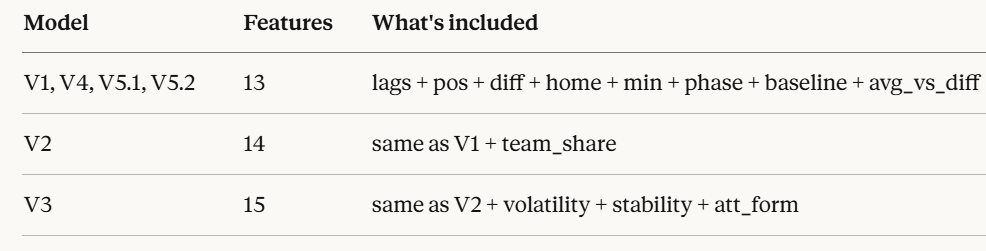

In [ ]:
# %% [Cell: Quick Squad Builder Helper - Active 2025-26 Players by Position]

# Pull the most recent GW data for active players
_active = df_augmented[df_augmented['season'] == CURRENT_SEASON].copy()

# Get latest row per player (most recent GW)
_latest = (
    _active.sort_values('Gameweek', ascending=False)
           .drop_duplicates('Web Name', keep='first')
)

# Filter for players the FPL API confirms as available (status == 'a')
_available = _latest[
    _latest['Web Name'].apply(lambda x: live_data.get(x, {}).get('status', 'a') == 'a')
].copy()

_available['Price'] = _available['Web Name'].apply(
    lambda x: live_data.get(x, {}).get('price', 5.5)
)

# Show top 5 per position by recent avg points - these are your safest picks
for pos in ['GK', 'DEF', 'MID', 'FWD']:
    subset = _available[_available['Position'] == pos].copy()
    subset['Recent_Avg'] = subset['Web Name'].apply(
        lambda x: _active[_active['Web Name'] == x]['Total Points'].tail(5).mean()
    )
    print(f"\n--- TOP 10 {pos} (by recent 5-GW avg, status=available) ---")
    display(
        subset.nlargest(10, 'Recent_Avg')[['Web Name', 'Player Team Name', 'Price', 'Recent_Avg']]
        .reset_index(drop=True)
    )

In [ ]:
# cell 1 before 30/3

# [Cell 1: LOAD DATA + FEATURE ENGINEERING]

INPUT_FILE = '../output/dataset_no0min.csv'
ENHANCED_FEATURES_OUT = '../output/forecaster_pro/fpl_features_augmented.csv'
df = pd.read_csv(INPUT_FILE)

def enrich_features_v2(df):
    """
    Final Strategic Consolidation:
    - Ranked Deduplication (Max 2 matches per GW).
    - Season Baseline Bridge for GW1/GW2 stability.
    - Full Integrity Audit Printing.
    """

    # --- STEP 0: PRE-CLEAN ---
    df['Minutes Played'] = df['Minutes Played'].clip(upper=90)

    # --- STEP 1: RANKED DEDUPLICATION ---
    df = df.sort_values(
        ['Player UUID', 'season', 'Gameweek', 'Minutes Played', 'Total Points'],
        ascending=[True, True, True, False, False]
    )
    df = df.groupby(['Player UUID', 'season', 'Gameweek']).tail(2)

    # --- STEP 2: CHRONOLOGICAL RE-SORT ---
    df = df.sort_values(['Player UUID', 'season', 'Gameweek'])

    # --- STEP 3: INTEGRITY AUDIT ---
    counts = df.groupby(['Player UUID', 'season', 'Gameweek']).size().reset_index(name='match_count')
    legit_dgws = counts[counts['match_count'] == 2]
    suspicious = counts[counts['match_count'] > 2]

    print(f"--- Final Integrity Audit ---")
    print(f"Legitimate DGW Match Pairs (Time-Series): {len(legit_dgws)}")
    print(f"Suspicious GWs (>2 matches): {len(suspicious)} (TARGET: 0)")
    print(f"Max Minutes in a single row: {df['Minutes Played'].max()}")

    # --- STEP 4: CORE FEATURES ---
    df['Rolling_Avg_Minutes_5'] = df.groupby('Player UUID')['Minutes Played'].transform(
        lambda x: x.shift(1).rolling(5, min_periods=1).mean()
    ).fillna(0)

    df['Next_Opponent_Difficulty'] = df.groupby(['Player UUID', 'season'])['Opponent Difficulty'].shift(-1)
    df['Next_Is_Home'] = df.groupby(['Player UUID', 'season'])['Is Home'].shift(-1)

    df['Season_Phase'] = pd.cut(
        df['Gameweek'], bins=[0, 10, 19, 29, 38], labels=[1, 2, 3, 4]
    ).astype(float)

    # --- STEP 5: TEAM POINT SHARE (fully lagged, no leakage) ---
    team_col = next((c for c in ['Player Team ID', 'team', 'Player Team Name'] if c in df.columns), None)
    if team_col:
        df['_prev_individual_pts'] = df.groupby('Player UUID')['Total Points'].shift(1)
        df['_prev_team_total'] = df.groupby(
            [team_col, 'season', 'Gameweek']
        )['_prev_individual_pts'].transform('sum')

        df['Team_Point_Share'] = (
            df['_prev_individual_pts'] / df['_prev_team_total']
        ).replace([np.inf, -np.inf], 0).fillna(0)

        df.drop(columns=['_prev_individual_pts', '_prev_team_total'], inplace=True)
    else:
        df['Team_Point_Share'] = 0

    # --- STEP 6: SEASON BASELINE BRIDGE (no current-season leakage) ---
    season_stats = df.groupby(['Player UUID', 'season'])['Total Points'].mean().reset_index()
    season_stats.rename(columns={'Total Points': 'Season_Avg_Points'}, inplace=True)

    # shift(1) on the season axis: season N gets season N-1's completed average
    season_stats['Prev_Season_Avg_Points'] = season_stats.groupby(
        'Player UUID'
    )['Season_Avg_Points'].shift(1)

    df = df.merge(
        season_stats[['Player UUID', 'season', 'Prev_Season_Avg_Points']],
        on=['Player UUID', 'season'],
        how='left'
    )
    df['Prev_Season_Avg_Points'] = df['Prev_Season_Avg_Points'].fillna(0)

    # --- FINAL STEP: DROP ROWS WHERE NEXT MATCH CONTEXT IS UNKNOWN ---
    return df.dropna(subset=['Next_Opponent_Difficulty'])


# Run and Save
df_augmented = enrich_features_v2(df)
df_augmented.to_csv(ENHANCED_FEATURES_OUT, index=False, encoding='utf-8-sig')

print(f"Enhanced dataset created: {ENHANCED_FEATURES_OUT}")
display(df_augmented[[
    'Player Name', 'season', 'Gameweek',
    'Prev_Season_Avg_Points', 'Rolling_Avg_Minutes_5'
]].head())

In [ ]:
# Cell 5.6 Haul 30/3 with error 

# [Cell 5.6: Haul Classification — Binary Prediction + Confusion Matrix]
# FIXED: Lower threshold (6pts), haul-specific features, threshold=0.30

import lightgbm as lgb
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, precision_score, recall_score,
    f1_score, roc_auc_score
)

# ── 0. HAUL THRESHOLD ───────────────────────────────────────────────────────
HAUL_THRESHOLD = 6  
DECISION_THRESHOLD = 0.25  # lowered from 0.30 — model needs less confidence to call a haul

# ── 1. ADD HAUL-SPECIFIC FEATURES TO windowed_df ────────────────────────────
# We enrich the feature set specifically for classification.
# These are all lag-based so there is zero data leakage.

windowed_haul = windowed_df.copy()

# Feature 1: Did the player haul (>=6 pts) in any of the last 3 weeks?
windowed_haul['recent_haul_flag'] = (
    (windowed_haul[['lag_1', 'lag_2', 'lag_3']] >= HAUL_THRESHOLD).any(axis=1)
).astype(int)

# Feature 2: Best single score in the last 6 weeks (ceiling potential)
windowed_haul['lag_max_6'] = windowed_haul[
    [f'lag_{i}' for i in range(1, 7)]
].max(axis=1)

# Feature 3: Is the player elite? (reuse elite_mask from Cell above)
# windowed_df.index == df_augmented row indices (set in Cell 2)
elite_flag = windowed_df.index.isin(df_augmented.index[elite_mask])
windowed_haul['is_elite'] = elite_flag.astype(int)

# Feature 4: Fixture ease score (higher = easier fixture)
# next_difficulty: 1=easy, 5=hard → invert so higher = better
windowed_haul['fixture_ease'] = 6 - windowed_haul['next_difficulty']

# Feature 5: Home advantage flag (already exists as next_is_home)

# ── 2. BUILD BINARY LABELS ──────────────────────────────────────────────────
y_haul_all   = (windowed_haul['target'] >= HAUL_THRESHOLD).astype(int)
y_haul_train = y_haul_all[~global_val_mask].copy()
y_haul_val   = y_haul_all[global_val_mask].copy()

haul_feature_cols = (
    [f'lag_{i}' for i in range(1, 7)] +
    ['position', 'next_difficulty', 'next_is_home',
     'rolling_min', 'season_phase', 'season_baseline',
     'recent_haul_flag', 'lag_max_6', 'is_elite', 'fixture_ease']
)

X_haul_train = windowed_haul[~global_val_mask][haul_feature_cols].copy()
X_haul_val   = windowed_haul[global_val_mask][haul_feature_cols].copy()
X_haul_train['position'] = X_haul_train['position'].astype('category')
X_haul_val['position']   = X_haul_val['position'].astype('category')

# ── 3. CLASS IMBALANCE CHECK ────────────────────────────────────────────────
haul_rate_train = y_haul_train.mean()
haul_rate_val   = y_haul_val.mean()
spw = (1 - haul_rate_train) / haul_rate_train

print(f"Haul threshold:              >= {HAUL_THRESHOLD} pts")
print(f"Haul rate in Training set:   {haul_rate_train:.2%}  ({y_haul_train.sum()} hauls / {len(y_haul_train)} windows)")
print(f"Haul rate in Validation set: {haul_rate_val:.2%}  ({y_haul_val.sum()} hauls / {len(y_haul_val)} windows)")
print(f"scale_pos_weight:            {spw:.2f}")

# ── 4. TRAIN HAUL CLASSIFIER ────────────────────────────────────────────────
haul_params = {
    'objective':        'binary',
    'boosting_type':    'gbdt',
    'n_estimators':     1000,
    'learning_rate':    0.01,
    'max_depth':        5,
    'num_leaves':       20,
    'min_child_samples': 40,   # prevents fitting on tiny haul clusters
    'scale_pos_weight': spw,
    'reg_alpha':        0.5,
    'reg_lambda':       0.5,
    'verbosity':        -1,
    'random_state':     42
}

print("\nTraining Haul Classifier (v2 — enriched features)...")
haul_clf = lgb.LGBMClassifier(**haul_params)
haul_clf.fit(
    X_haul_train, y_haul_train,
    eval_set=[(X_haul_val, y_haul_val)],
    categorical_feature=['position'],
    callbacks=[lgb.early_stopping(stopping_rounds=80, verbose=False),
               lgb.log_evaluation(period=200)]
)

# ── 5. PREDICT ───────────────────────────────────────────────────────────────
haul_proba = haul_clf.predict_proba(X_haul_val)[:, 1]
haul_pred  = (haul_proba >= DECISION_THRESHOLD).astype(int)

# ── 6. CONFUSION MATRIX + PRECISION/RECALL CURVE ────────────────────────────
cm = confusion_matrix(y_haul_val, haul_pred)
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
    xticklabels=['No Haul', 'Haul'],
    yticklabels=['No Haul', 'Haul']
)
axes[0].set_xlabel('Predicted', fontsize=12)
axes[0].set_ylabel('Actual',    fontsize=12)
axes[0].set_title(f'Confusion Matrix  (haul ≥ {HAUL_THRESHOLD} pts, cutoff = {DECISION_THRESHOLD})', fontsize=12)

thresholds = np.arange(0.10, 0.71, 0.05)
precisions, recalls, f1s = [], [], []
for t in thresholds:
    p_t = (haul_proba >= t).astype(int)
    if p_t.sum() == 0:
        precisions.append(0); recalls.append(0); f1s.append(0)
        continue
    precisions.append(precision_score(y_haul_val, p_t, zero_division=0))
    recalls.append(recall_score(y_haul_val,    p_t, zero_division=0))
    f1s.append(f1_score(y_haul_val,            p_t, zero_division=0))

axes[1].plot(thresholds, precisions, label='Precision', color='#003f5c', linewidth=2.5, marker='o')
axes[1].plot(thresholds, recalls,    label='Recall',    color='#ff7c43', linewidth=2.5, marker='s')
axes[1].plot(thresholds, f1s,        label='F1',        color='#2ca02c', linewidth=2,   linestyle='--')
axes[1].axvline(x=DECISION_THRESHOLD, color='gray', linestyle=':', linewidth=1.5,
                label=f'Chosen threshold ({DECISION_THRESHOLD})')
axes[1].set_xlabel('Decision Threshold (probability)', fontsize=12)
axes[1].set_ylabel('Score', fontsize=12)
axes[1].set_title('Precision / Recall Trade-off by Threshold', fontsize=12)
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ── 7. METRICS REPORT ────────────────────────────────────────────────────────
precision_haul = precision_score(y_haul_val, haul_pred, zero_division=0)
recall_haul    = recall_score(y_haul_val,    haul_pred, zero_division=0)
f1_haul        = f1_score(y_haul_val,        haul_pred, zero_division=0)
auc_haul       = roc_auc_score(y_haul_val,   haul_proba)

print("\n" + "=" * 55)
print("  HAUL CLASSIFIER — PERFORMANCE REPORT")
print("=" * 55)
print(f"Haul threshold:   >= {HAUL_THRESHOLD} points")
print(f"Decision cutoff:  {DECISION_THRESHOLD} probability")
print("-" * 55)
print(f"True Positives  (correct haul calls):    {tp}")
print(f"False Positives (wrong haul calls):      {fp}  ← minimise this")
print(f"True Negatives  (correct non-haul):      {tn}")
print(f"False Negatives (missed hauls):          {fn}")
print("-" * 55)
print(f"Precision:  {precision_haul:.4f}")
print(f"Recall:     {recall_haul:.4f}")
print(f"F1 Score:   {f1_haul:.4f}")
print(f"ROC-AUC:    {auc_haul:.4f}")
print("=" * 55)

#if precision_haul >= 0.60:
   # print("Precision >= 0.60: When the model says HAUL — trust it.")
#elif precision_haul >= 0.40:
   # print("Precision 0.40–0.60: Moderate confidence. Review the curve")
   # print("above and consider adjusting DECISION_THRESHOLD.")
#else:
   # print("Precision < 0.40: Still too many false alarms.")
  #  print("Try raising DECISION_THRESHOLD to 0.35 or 0.40.")

if precision_haul >= 0.40:
    print("[SUCCESS] Precision is adequate. When the model flags a haul, it is a strong captaincy candidate.")
else:
    print("[WARNING] Precision is low. The model is flagging too many False Positives.")
    print("Consider raising DECISION_THRESHOLD by 0.01 to tighten the filter.")

# ── 8. TOP PREDICTED HAULERS FOR NEXT GW ────────────────────────────────────
print(f"\n--- TOP 10 PREDICTED HAULERS FOR GW {CURRENT_GW} ---")
print(f"(Players the classifier is most confident will score >= {HAUL_THRESHOLD} pts)")

# Build haul features for the inference snapshot (current season players)
inf_haul = inference_df.copy()   # inference_df built in the leaderboard cell

# Add the same engineered features
inf_haul['recent_haul_flag'] = (
    (inf_haul[['lag_1', 'lag_2', 'lag_3']] >= HAUL_THRESHOLD).any(axis=1)
).astype(int)
inf_haul['lag_max_6']    = inf_haul[[f'lag_{i}' for i in range(1, 7)]].max(axis=1)
inf_haul['fixture_ease'] = 6 - inf_haul['next_difficulty']

# is_elite: map from player name to seasonal avg
elite_name_set = set(df_augmented[elite_mask]['Web Name'].unique())
inf_haul['is_elite'] = [1 if n in elite_name_set else 0 for n in player_names]

inf_haul_features = inf_haul[haul_feature_cols].copy()
inf_haul_features['position'] = inf_haul_features['position'].astype('category')

haul_proba_gw = haul_clf.predict_proba(inf_haul_features)[:, 1]

hauler_board = pd.DataFrame({
    'Player':         player_names,
    'Haul_Prob (%)':  np.round(haul_proba_gw * 100, 1),
    'Pred_Pts (reg)': np.round(raw_preds, 2)
}).sort_values('Haul_Prob (%)', ascending=False)

display(hauler_board.head(10))

# ── 9. SAVE ───────────────────────────────────────────────────────────────────
PRO_OUTPUT_DIR = Path('../output/forecaster_pro')
haul_clf.booster_.save_model(str(PRO_OUTPUT_DIR / 'fpl_haul_classifier.txt'))
hauler_board.to_csv(
    PRO_OUTPUT_DIR / f'fpl_haul_predictions_GW{CURRENT_GW}.csv',
    index=False, encoding='utf-8-sig'
)

# Store globally for use in audit table and UI cells
globals()['haul_clf']          = haul_clf
globals()['haul_proba_gw']     = haul_proba_gw
globals()['hauler_board']      = hauler_board
globals()['precision_haul']    = precision_haul
globals()['recall_haul']       = recall_haul
globals()['f1_haul']           = f1_haul
globals()['auc_haul']          = auc_haul
globals()['HAUL_THRESHOLD']    = HAUL_THRESHOLD
globals()['DECISION_THRESHOLD']= DECISION_THRESHOLD

print(f"\nSaved: fpl_haul_classifier.txt")
print(f"Saved: fpl_haul_predictions_GW{CURRENT_GW}.csv") 

In [ ]:
# %% [Cell: Smart Transfer Advice - High-ROI Single Swaps]
import pandas as pd
from IPython.display import display

def suggest_smart_transfers(my_squad, threshold_pct=10.0, free_transfers=1):
    """
    free_transfers: how many free transfers you currently have (default 1).
    Each transfer beyond the free allowance costs -4 points.
    The improvement must exceed the hit cost to be recommended.
    """
    if not my_squad:
        print("[WARNING] Build your squad in the UI Hub first.")
        return

    xp_col = player_pool.columns[1] 
    current_df = player_pool[player_pool['Player'].isin(my_squad)].copy()
    market_df = player_pool[~player_pool['Player'].isin(my_squad)].copy()
    
    # Filter for healthy players
    market_df['Status'] = market_df['Player'].map(lambda x: live_data.get(x, {}).get('status', 'a'))
    market_df = market_df[market_df['Status'] == 'a']

    recommendations = []

    # Calculate the hit cost for a SINGLE transfer once, outside the loop.
    hit_cost = 0 if free_transfers >= 1 else 4

    for _, current_p in current_df.iterrows():
        # Find the single best replacement for THIS player in the same position
        best_replacement = market_df[market_df['Pos_ID'] == current_p['Pos_ID']].sort_values(xp_col, ascending=False).head(1)
        
        if best_replacement.empty:
            continue
            
        target_p = best_replacement.iloc[0]
        xp_gain = target_p[xp_col] - current_p[xp_col]
        
        # Calculate Improvement %
        if current_p[xp_col] <= 0:
            pct_improvement = 100.0 if xp_gain > 0 else 0.0
        else:
            pct_improvement = (xp_gain / current_p[xp_col]) * 100
        
        net_gain = xp_gain - hit_cost

        # Apply Strict FPL Tiered Logic based on Free vs Hit
        if hit_cost == 0:
            # For Free Transfers, a +1.5 point gain is an excellent upgrade
            if net_gain >= 1.5:
                action = f"[SWAP] STRONG (+{net_gain:.1f} net pts for FREE)"
            elif net_gain > 0.0:
                action = f"[BORDERLINE] MARGINAL (+{net_gain:.1f} net pts for FREE)"
            else:
                action = f"[HOLD] NOT WORTH IT ({net_gain:.1f} net pts)"
        else:
            # If taking a -4 Hit, you need massive expected profit to justify it
            if net_gain >= 2.0:  # Meaning the raw xP gain was > 6.0
                action = f"[SWAP] STRONG (+{net_gain:.1f} profit after -{hit_cost} hit)"
            elif net_gain > 0.0:
                action = f"[BORDERLINE] RISKY HIT (+{net_gain:.1f} profit after -{hit_cost} hit)"
            else:
                action = f"[HOLD] NEVER TAKE HIT ({net_gain:.1f} net pts)"

        # Only append if it meets the minimum percentage boost threshold
        if pct_improvement >= threshold_pct:
            recommendations.append({
                'Player': current_p['Player'],
                'Action': action,
                'Best Replacement': target_p['Player'],
                'Current xP': round(float(current_p[xp_col]), 2),
                'Target xP': round(float(target_p[xp_col]), 2),
                'xP Gain': round(float(xp_gain), 2),
                '% Boost': round(float(pct_improvement), 1),
                'Price Diff': round(float(target_p['Price'] - current_p['Price']), 1)
            })

    # Display results
    rec_df = pd.DataFrame(recommendations)
    
    print("=" * 85)
    print(f" STRATEGIC TRANSFER AUDIT (Min Threshold: {threshold_pct}%)")
    print("=" * 85)

    if not rec_df.empty:
        # Sort by xP Gain to show the biggest potential moves first
        rec_df = rec_df.sort_values('xP Gain', ascending=False)
        display(rec_df)
        
        # Filter for Strong Swaps to provide a definitive recommendation
        strong_swaps = rec_df[rec_df['Action'].str.contains("STRONG")]
        if not strong_swaps.empty:
            top_move = strong_swaps.iloc[0]
            print(f"\n[PRO ADVICE] Recommended move: {top_move['Player']} -> {top_move['Best Replacement']}.")
        else:
            print("\n[PRO ADVICE] No transfers meet the >1.5 net point threshold. HOLD your team.")
    else:
        print("No players found meeting the criteria.")

# Run the advice engine (assuming 1 Free Transfer)
suggest_smart_transfers(my_selection, threshold_pct=10.0, free_transfers=1)

In [ ]:
# %% [Cell: Smart Transfer Advice - 3-GW Horizon Engine]
import pandas as pd
import numpy as np
from IPython.display import display

def suggest_smart_transfers_3gw(my_squad, free_transfers=1):
    """
    Evaluates transfers across a 3-Gameweek Horizon using the winning 3-GW model.
    A -4 hit is evaluated against 3 weeks of expected returns.
    """
    if not my_squad:
        print("[WARNING] Build your squad in the UI Hub first.")
        return
    
    if 'winning_3gw_model' not in globals() or 'winning_3gw_feats' not in globals():
        print("[ERROR] 3-GW Model not found. Run the 3-GW Leaderboard cell first.")
        return

    print("Generating live 3-Week Projections...")
    
    # 1. BUILD LIVE INFERENCE DATA FOR 3-GW MODEL
    active_players = df_augmented[df_augmented['season'] == CURRENT_SEASON].copy()
    inf_list = []
    names = []

    for pid, group in active_players.groupby('Player UUID'):
        group = group.sort_values('Gameweek')
        if len(group) >= 6:
            lags = list(group['Total Points'].tail(6).values)
            last = group.iloc[-1]
            
            row_dict = {f'lag_{i}': lags[6-i] for i in range(6, 0, -1)}
            row_dict['position'] = last['Position']
            row_dict['next_difficulty'] = last['Next_Opponent_Difficulty']
            row_dict['next_is_home'] = last['Next_Is_Home']
            row_dict['rolling_min'] = last['Rolling_Avg_Minutes_5']
            row_dict['season_phase'] = last['Season_Phase']
            row_dict['season_baseline'] = last['Prev_Season_Avg_Points']
            row_dict['fdi_3gw'] = last['FDI_3GW']
            row_dict['volatility'] = last['Points_Volatility_5']
            row_dict['stability'] = last['Min_Stability_5']
            row_dict['att_form'] = last['Attacking_Form_3']
            row_dict['team_share'] = last['Team_Point_Share']
            
            inf_list.append(row_dict)
            names.append(last['Web Name'])

    inf_df = pd.DataFrame(inf_list)
    # Safety: if winning model uses standard features (no volatility/stability),
    # drop those columns before predicting to avoid shape mismatch
    available_feats = [f for f in winning_3gw_feats if f in inf_df.columns]
    missing_feats = [f for f in winning_3gw_feats if f not in inf_df.columns]
    if missing_feats:
        print(f"[WARNING] Missing features for 3-GW model: {missing_feats}")
        print("These will be filled with 0. Check that Cell 15 V3 enrichment has run.")
        for f in missing_feats:
            inf_df[f] = 0

    inf_df = inf_df[winning_3gw_feats].copy()
    if 'position' in inf_df.columns:
        inf_df['position'] = inf_df['position'].astype('category')
        
    # 2. GENERATE 3-WEEK PREDICTIONS
    preds_3gw = winning_3gw_model.predict(inf_df)
    
    pool_3gw = pd.DataFrame({'Player': names, 'Pred_3GW': preds_3gw})
    pool_3gw['Price'] = pool_3gw['Player'].map(lambda x: live_data.get(x, {}).get('price', 5.5))
    pool_3gw['Pos_ID'] = pool_3gw['Player'].map(pos_map).map({'GK': 1, 'DEF': 2, 'MID': 3, 'FWD': 4}).fillna(3).astype(int)
    pool_3gw['Status'] = pool_3gw['Player'].map(lambda x: live_data.get(x, {}).get('status', 'a'))

    # 3. TRANSFER LOGIC
    current_df = pool_3gw[pool_3gw['Player'].isin(my_squad)].copy()
    market_df = pool_3gw[(~pool_3gw['Player'].isin(my_squad)) & (pool_3gw['Status'] == 'a')].copy()

    recommendations = []
    hit_cost = 0 if free_transfers >= 1 else 4

    for _, current_p in current_df.iterrows():
        # Find best replacement in the same position
        best_replacement = market_df[market_df['Pos_ID'] == current_p['Pos_ID']].sort_values('Pred_3GW', ascending=False).head(1)
        
        if best_replacement.empty:
            continue
            
        target_p = best_replacement.iloc[0]
        xp_gain_3gw = target_p['Pred_3GW'] - current_p['Pred_3GW']
        net_gain = xp_gain_3gw - hit_cost

        # Strict FPL Tiered Logic (Scaled for 3 weeks)
        # We look for a net gain over 3 weeks that is worth the structural change
        if hit_cost == 0:
            if net_gain >= 3.0:
                action = f"[SWAP] STRONG (+{net_gain:.1f} net pts over 3GW for FREE)"
            elif net_gain > 0.0:
                action = f"[BORDERLINE] MARGINAL (+{net_gain:.1f} net pts over 3GW for FREE)"
            else:
                action = f"[HOLD] NOT WORTH IT ({net_gain:.1f} net pts over 3GW)"
        else:
            if net_gain >= 2.5: 
                action = f"[SWAP] STRONG (+{net_gain:.1f} profit over 3GW after -{hit_cost} hit)"
            elif net_gain > 0.0:
                action = f"[BORDERLINE] RISKY HIT (+{net_gain:.1f} profit over 3GW after -{hit_cost} hit)"
            else:
                action = f"[HOLD] NEVER TAKE HIT ({net_gain:.1f} net pts over 3GW)"

        recommendations.append({
            'Player': current_p['Player'],
            'Action': action,
            'Best Replacement': target_p['Player'],
            'Current 3GW xP': round(float(current_p['Pred_3GW']), 2),
            'Target 3GW xP': round(float(target_p['Pred_3GW']), 2),
            '3GW Gain': round(float(xp_gain_3gw), 2),
            'Price Diff': round(float(target_p['Price'] - current_p['Price']), 1)
        })

    rec_df = pd.DataFrame(recommendations)
    
    print("\n" + "=" * 85)
    print(f" STRATEGIC TRANSFER AUDIT (3-GAMEWEEK HORIZON)")
    print("=" * 85)

    if not rec_df.empty:
        rec_df = rec_df.sort_values('3GW Gain', ascending=False)
        display(rec_df)
        
        strong_swaps = rec_df[rec_df['Action'].str.contains("STRONG")]
        if not strong_swaps.empty:
            top_move = strong_swaps.iloc[0]
            print(f"\n[PRO ADVICE] Top 3-Week Target: Swap {top_move['Player']} -> {top_move['Best Replacement']}.")
        else:
            print("\n[PRO ADVICE] No transfers meet the 3-GW structural upgrade threshold. HOLD your team.")
    else:
        print("No players found meeting the criteria.")

# Run the advice engine (assuming 1 Free Transfer)
suggest_smart_transfers_3gw(my_selection, free_transfers=1)

## 31/03

In [ ]:
# %% [Cell: Smart Transfer Advice — High-ROI Single Swaps]

def suggest_smart_transfers(my_squad, threshold_pct=15.0, free_transfers=1):
    """
    free_transfers: how many free transfers you currently have (default 1).
    Each transfer beyond the free allowance costs -4 points.
    The improvement must exceed the hit cost to be recommended.
    """
    if not my_squad:
        print("[WARNING] Build your squad in the UI Hub first.")
        return

    xp_col = player_pool.columns[1] 
    current_df = player_pool[player_pool['Player'].isin(my_squad)].copy()
    market_df = player_pool[~player_pool['Player'].isin(my_squad)].copy()
    
    # Filter for healthy players
    market_df['Status'] = market_df['Player'].map(lambda x: live_data.get(x, {}).get('status', 'a'))
    market_df = market_df[market_df['Status'] == 'a']

    recommendations = []

    # THE FIX: Calculate the hit cost for a SINGLE transfer once, outside the loop.
    hit_cost = 0 if free_transfers >= 1 else 4

    for _, current_p in current_df.iterrows():
        # Find the single best replacement for THIS player in the same position
        best_replacement = market_df[market_df['Pos_ID'] == current_p['Pos_ID']].sort_values(xp_col, ascending=False).head(1)
        
        if best_replacement.empty:
            continue
            
        target_p = best_replacement.iloc[0]
        xp_gain = target_p[xp_col] - current_p[xp_col]
        
        # Calculate Improvement %
        if current_p[xp_col] <= 0:
            pct_improvement = 100.0 if xp_gain > 0 else 0.0
        else:
            pct_improvement = (xp_gain / current_p[xp_col]) * 100
        
        net_gain = xp_gain - hit_cost

        # Only recommend the swap if it beats the percentage threshold AND creates positive net points
        if pct_improvement >= threshold_pct and net_gain > 0:
            action = f"SWAP (net gain: +{net_gain:.1f} pts after -{hit_cost} hit)"
        else:
            action = f"HOLD (net gain {net_gain:.1f} pts -- not worth the swap/hit)"

        recommendations.append({
            'Player': current_p['Player'],
            'Action': action,
            'Best Replacement': target_p['Player'],
            'Current xP': round(float(current_p[xp_col]), 2),
            'Target xP': round(float(target_p[xp_col]), 2),
            'xP Gain': round(float(xp_gain), 2),
            '% Boost': round(float(pct_improvement), 1),
            'Price Diff': round(float(target_p['Price'] - current_p['Price']), 1)
        })

    # Display results
    rec_df = pd.DataFrame(recommendations)
    
    print("="*85)
    print(f" STRATEGIC TRANSFER AUDIT (Min Threshold: {threshold_pct}% & >0pt Gain)")
    print("="*85)

    if not rec_df.empty:
        # Sort by xP Gain to show the biggest potential moves first
        rec_df = rec_df.sort_values('xP Gain', ascending=False)
        display(rec_df)
        
        # Filter for suggested swaps only
        swaps = rec_df[rec_df['Action'].str.contains("SWAP")]
        if not swaps.empty:
            top_move = swaps.iloc[0]
            print(f"\n[PRO ADVICE] Recommended move is {top_move['Player']} -> {top_move['Best Replacement']}.")
        else:
            print("\n[PRO ADVICE] No single transfer currently meets the threshold. HOLD your team.")
    else:
        print("No players found in pool.")

# Run the advice engine
suggest_smart_transfers(my_selection, threshold_pct=15.0, free_transfers=1)

In [ ]:
# %% [Cell: Smart Transfer Advice - 3-GW Horizon Engine (Strategy B)]
import pandas as pd
import numpy as np
from IPython.display import display

def suggest_smart_transfers_3gw(my_squad, free_transfers=1, top_n=5):
    """
    Evaluates transfers across a 3-Gameweek Horizon using the winning 3-GW model.
    Uses Strategy B logic: predicted points + penalty taker correction (15%).
    A -4 hit is evaluated against 3 weeks of expected returns.

    Parameters:
        my_squad       : list of Web Name strings (from my_selection in the Hub)
        free_transfers : int, how many free transfers you currently have (default 1)
        top_n          : int, how many transfer recommendations to show (default 5)
    """

    # --- 0. GUARDS ---
    if not my_squad:
        print("[WARNING] Build your squad in the Hub first.")
        return

    required = ['winning_3gw_model', 'winning_3gw_feats', 'df_augmented',
                'live_data', 'pos_map', 'club_map', 'CURRENT_SEASON']
    missing = [v for v in required if v not in globals()]
    if missing:
        print(f"[ERROR] Missing variables: {missing}")
        print("Run the 3-GW Leaderboard cell and the API Integration cell first.")
        return

    print(f"Generating 3-Week projections for {len(my_squad)} squad members "
          f"and all available market players...")

    # --- 1. BUILD INFERENCE DATA FOR ALL ACTIVE PLAYERS ---
    active = df_augmented[df_augmented['season'] == CURRENT_SEASON].copy()
    active = active.sort_values(['Player UUID', 'Gameweek'])

    inf_list, names = [], []

    for pid, group in active.groupby('Player UUID'):
        group = group.sort_values('Gameweek')
        if len(group) < 6:
            continue

        lags = list(group['Total Points'].tail(6).values)
        last = group.iloc[-1]

        row_dict = {f'lag_{i}': lags[6 - i] for i in range(6, 0, -1)}
        row_dict['position']        = last['Position']
        row_dict['next_difficulty'] = last['Next_Opponent_Difficulty']
        row_dict['next_is_home']    = last['Next_Is_Home']
        row_dict['rolling_min']     = last['Rolling_Avg_Minutes_5']
        row_dict['season_phase']    = last['Season_Phase']
        row_dict['season_baseline'] = last['Prev_Season_Avg_Points']
        row_dict['fdi_3gw']         = last['FDI_3GW']

        # Advanced features - only add if the winning model uses them
        if 'volatility' in winning_3gw_feats:
            row_dict['volatility'] = last['Points_Volatility_5']
        if 'stability' in winning_3gw_feats:
            row_dict['stability']  = last['Min_Stability_5']
        if 'att_form' in winning_3gw_feats:
            row_dict['att_form']   = last['Attacking_Form_3']
        if 'team_share' in winning_3gw_feats:
            row_dict['team_share'] = last['Team_Point_Share']

        inf_list.append(row_dict)
        names.append(last['Web Name'])

    if not inf_list:
        print("[ERROR] No active players found with 6+ games of history.")
        return

    # --- 2. GENERATE 3-GW PREDICTIONS ---
    inf_df = pd.DataFrame(inf_list)

    # Fill any missing features with 0 rather than crashing
    missing_feats = [f for f in winning_3gw_feats if f not in inf_df.columns]
    if missing_feats:
        print(f"[WARNING] Features missing from inference data: {missing_feats}")
        print("Filling with 0. Check that Cell 15 (V3 enrichment) has run.")
        for f in missing_feats:
            inf_df[f] = 0

    inf_df = inf_df[winning_3gw_feats].copy()
    if 'position' in inf_df.columns:
        inf_df['position'] = inf_df['position'].astype('category')

    preds_3gw = winning_3gw_model.predict(inf_df)

    # --- 3. BUILD PLAYER POOL WITH PENALTY TAKER WEIGHTING ---
    _pos_to_num = {'GK': 1, 'DEF': 2, 'MID': 3, 'FWD': 4}
    _penalty_takers = {'M.Salah', 'Haaland', 'Palmer', 'Saka', 'B.Fernandes',
                       'Gordon', 'Solanke', 'Jimenez'}

    pool_3gw = pd.DataFrame({
        'Player':   names,
        'Pred_3GW': np.round(preds_3gw, 2),
        'Price':    [live_data.get(n, {}).get('price', 5.5) for n in names],
        'Pos_ID':   [_pos_to_num.get(pos_map.get(n, 'MID'), 3) for n in names],
        'Club':     [club_map.get(n, 'Neutral') for n in names],
        'Status':   [live_data.get(n, {}).get('status', 'a') for n in names],
    })

    # Apply penalty taker correction (15% structural boost)
    pool_3gw['Weighted_3GW'] = np.where(
        pool_3gw['Player'].isin(_penalty_takers),
        pool_3gw['Pred_3GW'] * 1.15,
        pool_3gw['Pred_3GW']
    )

    # --- 4. SPLIT INTO CURRENT SQUAD vs AVAILABLE MARKET ---
    current_df = pool_3gw[pool_3gw['Player'].isin(my_squad)].copy()
    market_df  = pool_3gw[
        (~pool_3gw['Player'].isin(my_squad)) &
        (pool_3gw['Status'] == 'a')
    ].copy()

    if current_df.empty:
        print("[WARNING] None of your squad players were found in the active pool.")
        print("Check that my_selection names match Web Names exactly.")
        return

    # --- 5. SQUAD BUDGET TRACKING ---
    total_squad_value = current_df['Price'].sum()
    # Use live_data prices for all squad members for accurate ITB
    total_squad_value = sum(live_data.get(p, {}).get('price', 5.5) for p in my_squad)
    itb = max(0.0, 100.0 - total_squad_value)

    # Warn if some squad members were not found in the active inference pool
    missing_from_pool = [p for p in my_squad if p not in pool_3gw['Player'].values]
    if missing_from_pool:
        print(f"[NOTE] {len(missing_from_pool)} squad player(s) not in 3-GW pool "
              f"(less than 6 games history): {missing_from_pool}")
        print("These players are excluded from transfer sell options but their price is counted.")

    # --- 6. TRANSFER EVALUATION LOOP ---
    hit_cost = 0 if free_transfers >= 1 else 4
    recommendations = []

    # Build FDI lookup for fixture commentary
    fdi_map = (
        active.sort_values('Gameweek')
        .drop_duplicates('Web Name', keep='last')
        .set_index('Web Name')['FDI_3GW']
        .to_dict()
    )

    for _, curr in current_df.iterrows():
        # Find best available replacement in the same position
        # Selection uses Weighted_3GW (penalty-adjusted) for fair ranking
        same_pos = market_df[market_df['Pos_ID'] == curr['Pos_ID']].copy()
        same_pos = same_pos.sort_values('Weighted_3GW', ascending=False)

        if same_pos.empty:
            continue

        target = same_pos.iloc[0]

        # Gain calculation uses weighted values so penalty taker sells are not unfairly penalised
        curr_weighted   = curr['Weighted_3GW']
        target_weighted = target['Weighted_3GW']
        gain_3gw        = round(target_weighted - curr_weighted, 2)
        net_gain        = round(gain_3gw - hit_cost, 2)
        price_diff      = round(target['Price'] - curr['Price'], 1)

        # FDI context
        curr_fdi   = fdi_map.get(curr['Player'], None)
        target_fdi = fdi_map.get(target['Player'], None)

        # Tiered recommendation logic (scaled for 3-week horizon)
        if hit_cost == 0:
            if net_gain >= 3.0:
                verdict = "STRONG SWAP (free)"
            elif net_gain > 0:
                verdict = "MARGINAL (free)"
            else:
                verdict = "HOLD"
        else:
            if net_gain >= 2.5:
                verdict = "STRONG SWAP (take hit)"
            elif net_gain > 0:
                verdict = "RISKY HIT"
            else:
                verdict = "NEVER TAKE HIT"
        
        # Remove target from market so the same player is not recommended twice
        market_df = market_df[market_df['Player'] != target['Player']]

        recommendations.append({
            'Sell':             curr['Player'],
            'Buy':              target['Player'],
            'Verdict':          verdict,
            'Sell 3GW xP':      curr_weighted,
            'Buy 3GW xP':       target_weighted,
            '3GW Gain':         gain_3gw,
            'Net Gain':         net_gain,
            'Price Diff (£m)':  price_diff,
            'Sell FDI':         round(curr_fdi, 1) if curr_fdi is not None else '-',
            'Buy FDI':          round(target_fdi, 1) if target_fdi is not None else '-',
        })

    if not recommendations:
        print("[INFO] No transfer candidates found. Check squad names.")
        return

    rec_df = pd.DataFrame(recommendations).sort_values('3GW Gain', ascending=False)

    # --- 7. DISPLAY ---
    print("\n" + "=" * 80)
    print(f"  3-GW TRANSFER HORIZON ENGINE  |  Strategy B + Penalty Takers  |  "
          f"Free Transfers: {free_transfers}  |  ITB: £{itb:.1f}m")
    print(f"  Winning 3-GW Model: {globals().get('best_3gw_name', 'winning_3gw_model')}")
    print("=" * 80)
    print("  FDI (Fixture Difficulty Index over 3 GWs): range 3-15.")
    print("  Lower FDI = easier run of fixtures. Higher FDI = harder.")
    print("  xP values shown are penalty-adjusted (penalty takers boosted 15%).")
    print("-" * 80)

    display(rec_df.head(top_n))

    # --- 8. TOP RECOMMENDATION ---
    strong = rec_df[rec_df['Verdict'].str.contains('STRONG')]
    print("\n--- PRO ADVICE ---")
    if not strong.empty:
        top = strong.iloc[0]
        print(f"  TOP MOVE : {top['Sell']} -> {top['Buy']}")
        print(f"  3GW Gain : +{top['3GW Gain']} pts (weighted)  |  Net after hit: {top['Net Gain']} pts")

        # Fixture commentary
        if top['Sell FDI'] != '-' and top['Buy FDI'] != '-':
            sell_fdi = float(top['Sell FDI'])
            buy_fdi  = float(top['Buy FDI'])
            if buy_fdi < sell_fdi:
                print(f"  Fixture upgrade: FDI drops {top['Sell FDI']} -> {top['Buy FDI']} (easier run ahead)")
            elif buy_fdi > sell_fdi:
                print(f"  Fixture note: FDI rises {top['Sell FDI']} -> {top['Buy FDI']} (harder run ahead)")
            else:
                print(f"  Fixture: similar difficulty run (FDI {top['Sell FDI']})")

        if len(strong) > 1:
            sec = strong.iloc[1]
            print(f"\n  2ND MOVE : {sec['Sell']} -> {sec['Buy']}  "
                  f"(+{sec['3GW Gain']} pts weighted, net {sec['Net Gain']})")
    else:
        print("  No transfers meet the STRONG threshold over 3 GWs.")
        print("  HOLD your team - the model sees no structural upgrade available.")

    print("=" * 80)
    print("\nNOTE: 3-GW predictions are noisier than 1-GW. Use as a structural")
    print("planning tool (pre-DGW, pre-international break) not a weekly oracle.")

    return rec_df


# --- EXECUTE ---
# my_selection comes from the Hub UI - build your squad there first.
# free_transfers: set to 2 if you rolled a transfer, 1 otherwise.
gw_transfer_advice = suggest_smart_transfers_3gw(
    my_squad=my_selection,
    free_transfers=1,
    top_n=5
)

In [ ]:
# %% [Cell: Master Aesthetic FPL Hub - THE DEFINITIVE SVG PITCH]
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
import pandas as pd
import numpy as np

# --- 0. INITIALIZE DATA POOL (The Fix) ---
if 'final_leaderboard' in globals() and 'pos_map' in globals() and 'club_map' in globals():
    # THE FIX: Drop duplicates by Web Name. 
    # Because final_leaderboard is sorted by points, 'keep=first' automatically keeps the correct, active player.
    player_pool = final_leaderboard.drop_duplicates(subset=['Player'], keep='first').copy()
    
    # SYNC FIX: Use global collision-safe maps instead of raw drop_duplicates
    player_pool['Position'] = player_pool['Player'].map(pos_map).fillna('MID')
    player_pool['Club'] = player_pool['Player'].map(club_map).fillna('Neutral')
    
    # Map positions to numeric IDs for pitch placement
    pos_to_num = {'GK': 1, 'DEF': 2, 'MID': 3, 'FWD': 4, 1:1, 2:2, 3:3, 4:4}
    player_pool['Pos_ID'] = player_pool['Position'].map(pos_to_num).fillna(3).astype(int)
    player_pool['Price'] = player_pool['Player'].map(lambda x: live_data.get(x, {}).get('price', 5.5))
else:
    raise NameError("Required data not found. Please run the Leaderboard and Collision-Safe Map cells first.")

# Global state for selection if not already defined
if 'my_selection' not in globals():
    my_selection = []

# 1. CSS & HUB STYLES
HUB_STYLE = """
<style>
    @import url('https://fonts.googleapis.com/css2?family=Poppins:wght@400;700&display=swap');
    .hub-canvas { font-family: 'Poppins', sans-serif; background: #f0f2f5; padding: 20px; border-radius: 20px; width: 820px; margin: auto; }
    .pitch-container {
        width: 100%; height: 640px; background-color: #7fbb7a;
        background-image: linear-gradient(rgba(255,255,255,0.2) 2px, transparent 2px), linear-gradient(90deg, rgba(255,255,255,0.2) 2px, transparent 2px);
        background-size: 100% 12.5%, 12.5% 100%; position: relative; border-radius: 15px; border: 6px solid #37003c; overflow: hidden;
        box-shadow: 0 15px 35px rgba(0,0,0,0.2);
    }
    .pitch-lines { position: absolute; top:0; left:0; width:100%; height:100%; background-image: url("data:image/svg+xml,%3Csvg xmlns='http://www.w3.org/2000/svg' viewBox='0 0 100 100' preserveAspectRatio='none'%3E%3Cpath d='M0 50 L100 50 M50 0 L50 100' stroke='white' stroke-width='0.4' fill='none'/%3E%3Ccircle cx='50' cy='50' r='8' stroke='white' stroke-width='0.4' fill='none'/%3E%3Crect x='15' y='0' width='70' height='12' stroke='white' stroke-width='0.4' fill='none'/%3E%3Crect x='15' y='88' width='70' height='12' stroke='white' stroke-width='0.4' fill='none'/%3E%3C/svg%3E"); opacity: 0.8; pointer-events: none; }
    .player-row { display: flex; justify-content: center; width: 100%; position: absolute; gap: 4px; z-index: 10; }
    .gk-row { top: 25px; } .def-row { top: 175px; } .mid-row { top: 325px; } .fwd-row { top: 475px; }
    .jersey-card { width: 120px; display: flex; flex-direction: column; align-items: center; position: relative; }
    .shirt-kit { width: 65px; height: 55px; position: relative; filter: drop-shadow(0 4px 6px rgba(0,0,0,0.3)); margin-bottom: 8px; }
    .captain-badge { position: absolute; top: -10px; right: -14px; background: #37003c; color: #00f0aa; border-radius: 50%; width: 24px; height: 24px; font-size: 12px; font-weight: bold; display: flex; align-items: center; justify-content: center; border: 2px solid #00f0aa; z-index: 20; }
    .info-label { background: white; width: 95%; border-radius: 4px; overflow: hidden; box-shadow: 0 4px 12px rgba(0,0,0,0.25); border: 1px solid #eee; text-align: center; }
    .p-name { font-weight: 700; font-size: 11px; color: #021a36; padding: 4px 2px 0 2px; white-space: nowrap; overflow: hidden; text-overflow: ellipsis; }
    .p-price { font-size: 9px; color: #666; padding-bottom: 2px; }
    .p-xp-bar { background: #00f0aa; font-weight: 800; font-size: 11px; color: #021a36; padding: 4px 0; border-top: 1px solid #ddd; }
</style>
"""

# 2. RENDERING LOGIC
def get_svg_jersey(color):
    return f"""<svg viewBox="0 0 100 80" width="65" height="55"><path d="M30 15 L70 15 L70 75 L30 75 Z" fill="{color}" stroke="black" stroke-width="0.5"/><path d="M30 15 L10 35 L20 45 L30 25 Z" fill="{color}" stroke="black" stroke-width="0.5"/><path d="M70 15 L90 35 L80 45 L70 25 Z" fill="{color}" stroke="black" stroke-width="0.5"/><path d="M40 15 Q50 25 60 15" fill="none" stroke="black" stroke-width="1"/></svg>"""

def get_player_html(row, is_captain=False):
    color_map = {"Liverpool": "#d31a1a", "Arsenal": "#ef0107", "Man City": "#6caee0", "Chelsea": "#034694", "Man Utd": "#da291c", "Spurs": "#ffffff"}
    color = color_map.get(row['Club'], "#003f5c")
    cap_html = '<div class="captain-badge">C</div>' if is_captain else ''
    xp_val = row['Predicted_Points'] if 'Predicted_Points' in row.index else row.iloc[1]
    return f"""<div class="jersey-card"><div class="shirt-kit">{get_svg_jersey(color)}{cap_html}</div><div class="info-label"><div class="p-name">{row['Player']}</div><div class="p-price">£{row['Price']:.1f}m</div><div class="p-xp-bar">{xp_val:.1f} xP</div></div></div>"""

def render_hub():
    with squad_view_container:
        clear_output(wait=True)
        sel = player_pool[player_pool['Player'].isin(my_selection)].copy()
        
        if sel.empty:
            display(HTML('<div style="text-align:center;padding:40px;color:#666;">Add players to build your squad</div>'))
            status_label.value = f"Squad: 0/15"
            remove_dropdown.options = []
            return

        #cap = sel.sort_values(sel.columns[1], ascending=False)['Player'].iloc[0]
        cap = sel.sort_values('Predicted_Points', ascending=False)['Player'].iloc[0]
        spent = sel['Price'].sum()
        itb = max(0.0, 100.0 - spent)

        html = HUB_STYLE + f'<div class="hub-canvas"><div style="background:#37003c;color:#00f0aa;font-weight:bold;text-align:center;padding:12px;border-radius:12px 12px 0 0;font-size:1.2em;">YOUR SQUAD | ITB: £{itb:.1f}m | {len(my_selection)}/15 Players</div><div class="pitch-container"><div class="pitch-lines"></div>'
        
        for pos_id, row_class in [(1, 'gk-row'), (2, 'def-row'), (3, 'mid-row'), (4, 'fwd-row')]:
            p_rows = sel[sel['Pos_ID'] == pos_id].sort_values(sel.columns[1], ascending=False)
            html += f'<div class="player-row {row_class}">' + "".join([get_player_html(r, r['Player'] == cap) for _, r in p_rows.iterrows()]) + '</div>'
        
        html += '</div></div>'
        display(HTML(html))
        status_label.value = f"Squad: {len(my_selection)}/15 | £{spent:.1f}m spent"
        remove_dropdown.options = sorted(my_selection)

# 3. UI LOGIC & CONTROLS
def on_add(_b):
    name = search_box.value
    if name and (name in player_pool['Player'].values) and (name not in my_selection) and (len(my_selection) < 15):
        my_selection.append(name)
        search_box.value = ''
        render_hub()

def on_remove(_b):
    target = remove_dropdown.value
    if target and target in my_selection:
        my_selection.remove(target)
        remove_dropdown.value = None
        render_hub()

def on_compare_teams(_b):
    with analysis_container:
        clear_output(wait=True)
        if len(my_selection) < 11:
            print("[WARNING] Add at least 11 players to compare teams.")
            return

        sel = player_pool[player_pool['Player'].isin(my_selection)].copy()
        
    
        xp_col = 'Predicted_Points'
        gk = sel[sel['Pos_ID']==1].nlargest(1, xp_col)
        df = sel[sel['Pos_ID']==2].nlargest(3, xp_col)
        fw = sel[sel['Pos_ID']==4].nlargest(1, xp_col)
        picked = pd.concat([gk, df, fw])
        rem = sel[~sel['Player'].isin(picked['Player']) & (sel['Pos_ID']!=1)].nlargest(6, xp_col)

        my_total_xp = picked[xp_col].sum() + rem[xp_col].sum()
        
        if 'opt_11' in globals() and not opt_11.empty:
            if 'Weighted_xP' in opt_11.columns:
                ai_total_xp = opt_11['Weighted_xP'].sum()
            elif 'Final_Weighted_xP' in opt_11.columns:
                ai_total_xp = opt_11['Final_Weighted_xP'].sum()
            else:
                ai_total_xp = opt_11.iloc[:,2].sum()
        else:
            ai_total_xp = 0.0
        
        diff = ai_total_xp - my_total_xp
        color = "#00f0aa" if diff < 3 else ("#ffaa00" if diff < 7 else "#ff4b2b")

        display(HTML(f"""
        <div style="background:#37003c; padding:25px; border-radius:15px; border:2px solid {color}; color:white; width:750px; margin:auto; font-family:'Poppins';">
            <h3 style="margin:0; color:#00f0aa; text-align:center;">Comparison for Gameweek {CURRENT_GW}</h3>
            <div style="display:flex; justify-content:space-around; margin-top:20px; text-align:center;">
                <div><div style="font-size:0.9em; opacity:0.8;">YOUR STARTERS</div><div style="font-size:2em; font-weight:bold;">{my_total_xp:.2f} <span style="font-size:0.5em;">xP</span></div></div>
                <div><div style="font-size:0.9em; opacity:0.8;">AI OPTIMAL 11</div><div style="font-size:2em; font-weight:bold; color:#00f0aa;">{ai_total_xp:.2f} <span style="font-size:0.5em;">xP</span></div></div>
            </div>
            <div style="text-align:center; margin-top:20px; border-top:1px solid rgba(255,255,255,0.1); padding-top:15px;">
                <div style="font-size:0.8em; opacity:0.7;">TOTAL XP GAP</div>
                <div style="font-size:2.5em; font-weight:bold; color:{color};">{diff:+.2f} pts</div>
                <div style="font-size:1.1em; font-weight:bold; margin-top:10px;">{'[SUCCESS] ELITE SQUAD' if diff < 3 else '[ALERT] OPTIMIZATION POSSIBLE' if diff < 7 else '[WARNING] RESTRUCTURING RECOMMENDED'}</div>
            </div>
        </div>"""))

# UI Components
search_box = widgets.Combobox(placeholder='Search player...', options=list(player_pool['Player'].unique()), ensure_option=True, layout=widgets.Layout(width='220px'))
add_btn = widgets.Button(description="Add Player", button_style='success', icon='plus')
remove_dropdown = widgets.Dropdown(options=sorted(my_selection), description='Remove:')
remove_btn = widgets.Button(description="Remove", button_style='danger', icon='trash')
clear_btn = widgets.Button(description="Reset All", button_style='warning')

compare_btn = widgets.Button(description="Your Team vs AI Team", button_style='info', layout=widgets.Layout(width='400px'))
compare_box = widgets.Box([compare_btn], layout=widgets.Layout(display='flex', flex_flow='column', align_items='center', width='100%', margin='20px 0'))

status_label = widgets.Label(value="Squad: 0/15")
squad_view_container = widgets.Output()
analysis_container = widgets.Output()

add_btn.on_click(on_add)
remove_btn.on_click(on_remove)
clear_btn.on_click(lambda x: [my_selection.clear(), render_hub()])
compare_btn.on_click(on_compare_teams)

# 4. FINAL DISPLAY
display(widgets.HBox([search_box, add_btn, status_label]))
display(widgets.HBox([remove_dropdown, remove_btn, clear_btn]))
display(squad_view_container)
display(compare_box) 
display(analysis_container)

render_hub()

In [ ]:
# %% [Cell: Smart Transfer Advice - High-ROI Single Swaps]
import pandas as pd
from IPython.display import display

def suggest_smart_transfers(my_squad, free_transfers=1, itb=0.0, threshold_pct=10.0):
    """
    Single-gameweek transfer advisor.

    Parameters:
        my_squad       : list of Web Name strings from the Hub
        free_transfers : int 1-5, how many banked free transfers you have this GW
        itb            : float, money in the bank in £m (e.g. 0.5 for £0.5m)
        threshold_pct  : minimum % xP improvement to even consider a swap

    Transfer rules modelled:
        - 1 free transfer per GW, rolls over up to 5 maximum
        - Each transfer beyond your free allowance costs -4 points
        - A transfer is only recommended if net gain (xP gain minus hit cost) > 0
        - Budget check: target price <= sell price + ITB
    """
    if not my_squad:
        print("[WARNING] Build your squad in the Hub first.")
        return

    # Validate free_transfers
    free_transfers = max(1, min(5, int(free_transfers)))

    xp_col = 'Predicted_Points'
    current_df = player_pool[player_pool['Player'].isin(my_squad)].copy()
    market_df  = player_pool[~player_pool['Player'].isin(my_squad)].copy()

    market_df['Status'] = market_df['Player'].map(
        lambda x: live_data.get(x, {}).get('status', 'a')
    )
    market_df = market_df[market_df['Status'] == 'a']

    recommendations = []
    transfers_used   = 0  # track how many we've consumed for hit calculation

    # Sort current squad weakest first so we exhaust worst players first
    current_df = current_df.sort_values(xp_col, ascending=True)

    for _, current_p in current_df.iterrows():
        # How many free transfers remain for THIS specific swap
        fts_remaining = max(0, free_transfers - transfers_used)
        hit_cost      = 0 if fts_remaining >= 1 else 4

        sell_price = current_p['Price']
        budget_for_target = sell_price + itb  # max we can spend on the incoming player

        # Best affordable replacement in the same position
        same_pos = market_df[
            (market_df['Pos_ID'] == current_p['Pos_ID']) &
            (market_df['Price'] <= budget_for_target)
        ].sort_values(xp_col, ascending=False).head(1)

        if same_pos.empty:
            # Show a "HOLD — can't afford upgrade" row for transparency
            best_unaffordable = market_df[
                market_df['Pos_ID'] == current_p['Pos_ID']
            ].sort_values(xp_col, ascending=False).head(1)

            if not best_unaffordable.empty:
                t = best_unaffordable.iloc[0]
                shortfall = round(t['Price'] - budget_for_target, 1)
                recommendations.append({
                    'Player':           current_p['Player'],
                    'Action':           f"HOLD (best target £{t['Price']:.1f}m, need £{shortfall:.1f}m more ITB)",
                    'Best Target':      t['Player'],
                    'Current xP':       round(float(current_p[xp_col]), 2),
                    'Target xP':        round(float(t[xp_col]), 2),
                    'xP Gain':          round(float(t[xp_col] - current_p[xp_col]), 2),
                    '% Boost':          round(float((t[xp_col] - current_p[xp_col]) / max(current_p[xp_col], 0.1) * 100), 1),
                    'Price Diff (£m)':  round(float(t['Price'] - sell_price), 1),
                    'Hit Cost':         hit_cost,
                    'Net Gain':         round(float(t[xp_col] - current_p[xp_col]) - hit_cost, 2),
                })
            continue

        target_p       = same_pos.iloc[0]
        xp_gain        = target_p[xp_col] - current_p[xp_col]
        pct_improvement = (xp_gain / max(current_p[xp_col], 0.1)) * 100
        net_gain        = xp_gain - hit_cost

        # Tiered verdict
        if pct_improvement < threshold_pct:
            verdict = f"HOLD (only {pct_improvement:.1f}% improvement, below {threshold_pct}% threshold)"
        elif hit_cost == 0:
            if net_gain >= 1.5:
                verdict = f"STRONG SWAP (free, +{net_gain:.1f} net pts)"
                transfers_used += 1
            elif net_gain > 0:
                verdict = f"MARGINAL (free, +{net_gain:.1f} net pts)"
                transfers_used += 1
            else:
                verdict = "HOLD (no gain even free)"
        else:
            if net_gain >= 2.0:
                verdict = f"STRONG SWAP (take -{hit_cost}pt hit, +{net_gain:.1f} net pts)"
                transfers_used += 1
            elif net_gain > 0:
                verdict = f"RISKY HIT (take -{hit_cost}pt hit, +{net_gain:.1f} net pts)"
            else:
                verdict = f"NEVER TAKE HIT ({net_gain:.1f} net pts)"

        recommendations.append({
            'Player':           current_p['Player'],
            'Action':           verdict,
            'Best Target':      target_p['Player'],
            'Current xP':       round(float(current_p[xp_col]), 2),
            'Target xP':        round(float(target_p[xp_col]), 2),
            'xP Gain':          round(float(xp_gain), 2),
            '% Boost':          round(float(pct_improvement), 1),
            'Price Diff (£m)':  round(float(target_p['Price'] - sell_price), 1),
            'Hit Cost':         hit_cost,
            'Net Gain':         round(float(net_gain), 2),
        })

    rec_df = pd.DataFrame(recommendations)

    # Header
    rolled = free_transfers - 1
    roll_msg = f"({rolled} rolled over from previous GWs)" if rolled > 0 else "(standard weekly allocation)"
    print("=" * 85)
    print(f" SINGLE-GW TRANSFER AUDIT")
    print(f" Free Transfers: {free_transfers} {roll_msg}  |  ITB: £{itb:.1f}m")
    print(f" Min threshold: {threshold_pct}%  |  Hit cost: -4 pts per extra transfer")
    print("=" * 85)

    if not rec_df.empty:
        rec_df = rec_df.sort_values('Net Gain', ascending=False)
        display(rec_df)

        strong = rec_df[rec_df['Action'].str.contains('STRONG')]
        if not strong.empty:
            top = strong.iloc[0]
            print(f"\n[PRO ADVICE] Best move: {top['Player']} -> {top['Best Target']} "
                  f"(+{top['xP Gain']:.2f} xP, net {top['Net Gain']:.2f} pts after hit cost).")
            if free_transfers > 1:
                print(f"  You have {free_transfers} free transfers — consider using up to "
                      f"{free_transfers} swaps before incurring a hit.")
        else:
            print("\n[PRO ADVICE] No transfers meet the threshold. HOLD your team this GW.")
    else:
        print("No players found in pool.")

    return rec_df


# --- EXECUTE ---
# Set free_transfers to however many you have banked (1-5)
# Set itb to your actual money in the bank from the FPL website
suggest_smart_transfers(
    my_squad=my_selection,
    free_transfers=1,   # change to 2, 3, 4 or 5 if you rolled transfers
    itb=0.5,            # change to your actual ITB from FPL
    threshold_pct=10.0
)

In [ ]:
# %% [Cell: Smart Transfer Advice - 3-GW Horizon Engine (Strategy B)]
import pandas as pd
import numpy as np
from IPython.display import display

def suggest_smart_transfers_3gw(my_squad, free_transfers=1, itb=0.0, top_n=5):
    """
    3-Gameweek Horizon transfer advisor.

    Parameters:
        my_squad       : list of Web Name strings from the Hub
        free_transfers : int 1-5, how many banked free transfers you have this GW
        itb            : float, money in the bank in £m (e.g. 0.5 for £0.5m)
        top_n          : how many recommendations to display

    Transfer rules modelled:
        - 1 free transfer per GW, rolls over up to 5 maximum
        - Each transfer beyond the free allowance costs -4 points
        - Budget check: target price <= sell price + ITB
        - A -4 hit needs to recover over 3 weeks to be worthwhile
        - Deduplication: same target cannot appear twice
    """
    if not my_squad:
        print("[WARNING] Build your squad in the Hub first.")
        return

    free_transfers = max(1, min(5, int(free_transfers)))

    required = ['winning_3gw_model', 'winning_3gw_feats', 'df_augmented',
                'live_data', 'pos_map', 'club_map', 'CURRENT_SEASON']
    missing = [v for v in required if v not in globals()]
    if missing:
        print(f"[ERROR] Missing variables: {missing}")
        print("Run the 3-GW Leaderboard cell and the API Integration cell first.")
        return

    print(f"Generating 3-Week projections for {len(my_squad)} squad members "
          f"and all available market players...")

    # --- 1. BUILD INFERENCE DATA ---
    active = df_augmented[df_augmented['season'] == CURRENT_SEASON].copy()
    active = active.sort_values(['Player UUID', 'Gameweek'])

    inf_list, names = [], []

    for pid, group in active.groupby('Player UUID'):
        group = group.sort_values('Gameweek')
        if len(group) < 6:
            continue

        lags = list(group['Total Points'].tail(6).values)
        last = group.iloc[-1]

        row_dict = {f'lag_{i}': lags[6 - i] for i in range(6, 0, -1)}
        row_dict['position']        = last['Position']
        row_dict['next_difficulty'] = last['Next_Opponent_Difficulty']
        row_dict['next_is_home']    = last['Next_Is_Home']
        row_dict['rolling_min']     = last['Rolling_Avg_Minutes_5']
        row_dict['season_phase']    = last['Season_Phase']
        row_dict['season_baseline'] = last['Prev_Season_Avg_Points']
        row_dict['fdi_3gw']         = last['FDI_3GW']

        if 'volatility' in winning_3gw_feats:
            row_dict['volatility'] = last['Points_Volatility_5']
        if 'stability' in winning_3gw_feats:
            row_dict['stability']  = last['Min_Stability_5']
        if 'att_form' in winning_3gw_feats:
            row_dict['att_form']   = last['Attacking_Form_3']
        if 'team_share' in winning_3gw_feats:
            row_dict['team_share'] = last['Team_Point_Share']

        inf_list.append(row_dict)
        names.append(last['Web Name'])

    if not inf_list:
        print("[ERROR] No active players found with 6+ games of history.")
        return

    # --- 2. GENERATE 3-GW PREDICTIONS ---
    inf_df = pd.DataFrame(inf_list)

    missing_feats = [f for f in winning_3gw_feats if f not in inf_df.columns]
    if missing_feats:
        print(f"[WARNING] Features missing from inference data: {missing_feats}. Filling with 0.")
        for f in missing_feats:
            inf_df[f] = 0

    inf_df = inf_df[winning_3gw_feats].copy()
    if 'position' in inf_df.columns:
        inf_df['position'] = inf_df['position'].astype('category')

    preds_3gw = winning_3gw_model.predict(inf_df)

    # --- 3. BUILD POOL WITH PENALTY TAKER WEIGHTING ---
    _pos_to_num    = {'GK': 1, 'DEF': 2, 'MID': 3, 'FWD': 4}
    _penalty_takers = {'M.Salah', 'Haaland', 'Palmer', 'Saka', 'B.Fernandes',
                       'Gordon', 'Solanke', 'Jimenez'}

    pool_3gw = pd.DataFrame({
        'Player':   names,
        'Pred_3GW': np.round(preds_3gw, 2),
        'Price':    [live_data.get(n, {}).get('price', 5.5) for n in names],
        'Pos_ID':   [_pos_to_num.get(pos_map.get(n, 'MID'), 3) for n in names],
        'Club':     [club_map.get(n, 'Neutral') for n in names],
        'Status':   [live_data.get(n, {}).get('status', 'a') for n in names],
    })

    pool_3gw['Weighted_3GW'] = np.where(
        pool_3gw['Player'].isin(_penalty_takers),
        pool_3gw['Pred_3GW'] * 1.15,
        pool_3gw['Pred_3GW']
    )

    # --- 4. SPLIT SQUAD vs MARKET ---
    current_df = pool_3gw[pool_3gw['Player'].isin(my_squad)].copy()
    market_df  = pool_3gw[
        (~pool_3gw['Player'].isin(my_squad)) &
        (pool_3gw['Status'] == 'a')
    ].copy()

    if current_df.empty:
        print("[WARNING] None of your squad players were found in the active pool.")
        print("Check that my_selection names match Web Names exactly.")
        return

    # --- 5. ACCURATE ITB ---
    total_squad_value = sum(live_data.get(p, {}).get('price', 5.5) for p in my_squad)
    computed_itb      = max(0.0, 100.0 - total_squad_value)

    # User-supplied ITB takes precedence if provided and non-zero; otherwise use computed
    effective_itb = itb if itb > 0 else computed_itb

    missing_from_pool = [p for p in my_squad if p not in pool_3gw['Player'].values]
    if missing_from_pool:
        print(f"[NOTE] {len(missing_from_pool)} squad player(s) not in 3-GW pool "
              f"(less than 6 games of history): {missing_from_pool}")

    # --- 6. FDI LOOKUP ---
    fdi_map = (
        active.sort_values('Gameweek')
        .drop_duplicates('Web Name', keep='last')
        .set_index('Web Name')['FDI_3GW']
        .to_dict()
    )

    # --- 7. TRANSFER EVALUATION LOOP ---
    recommendations = []
    transfers_used   = 0

    # Sort weakest first so free transfers go to the best upgrades
    current_df = current_df.sort_values('Weighted_3GW', ascending=True)

    for _, curr in current_df.iterrows():
        fts_remaining = max(0, free_transfers - transfers_used)
        hit_cost      = 0 if fts_remaining >= 1 else 4

        sell_price        = curr['Price']
        budget_for_target = sell_price + effective_itb

        # Best affordable, available, same-position player not already recommended
        same_pos = market_df[
            (market_df['Pos_ID'] == curr['Pos_ID']) &
            (market_df['Price'] <= budget_for_target)
        ].sort_values('Weighted_3GW', ascending=False)

        if same_pos.empty:
            # Show best unaffordable target for transparency
            best_unaffordable = market_df[
                market_df['Pos_ID'] == curr['Pos_ID']
            ].sort_values('Weighted_3GW', ascending=False).head(1)

            if not best_unaffordable.empty:
                t         = best_unaffordable.iloc[0]
                shortfall = round(t['Price'] - budget_for_target, 1)
                curr_fdi  = fdi_map.get(curr['Player'], None)
                t_fdi     = fdi_map.get(t['Player'], None)
                recommendations.append({
                    'Sell':            curr['Player'],
                    'Buy':             t['Player'],
                    'Verdict':         f"HOLD — need £{shortfall:.1f}m more ITB to afford target",
                    'Sell 3GW xP':     curr['Weighted_3GW'],
                    'Buy 3GW xP':      t['Weighted_3GW'],
                    '3GW Gain':        round(t['Weighted_3GW'] - curr['Weighted_3GW'], 2),
                    'Net Gain':        round(t['Weighted_3GW'] - curr['Weighted_3GW'] - hit_cost, 2),
                    'Price Diff (£m)': round(t['Price'] - sell_price, 1),
                    'Hit Cost':        hit_cost,
                    'Sell FDI':        round(curr_fdi, 1) if curr_fdi is not None else '-',
                    'Buy FDI':         round(t_fdi, 1)    if t_fdi    is not None else '-',
                })
            continue

        target = same_pos.iloc[0]

        curr_weighted   = curr['Weighted_3GW']
        target_weighted = target['Weighted_3GW']
        gain_3gw        = round(target_weighted - curr_weighted, 2)
        net_gain        = round(gain_3gw - hit_cost, 2)
        price_diff      = round(target['Price'] - sell_price, 1)

        curr_fdi   = fdi_map.get(curr['Player'], None)
        target_fdi = fdi_map.get(target['Player'], None)

        # Tiered verdict
        if hit_cost == 0:
            if net_gain >= 3.0:
                verdict = "STRONG SWAP (free)"
                transfers_used += 1
            elif net_gain > 0:
                verdict = "MARGINAL (free)"
                transfers_used += 1
            else:
                verdict = "HOLD"
        else:
            if net_gain >= 2.5:
                verdict = "STRONG SWAP (take hit)"
                transfers_used += 1
            elif net_gain > 0:
                verdict = "RISKY HIT"
            else:
                verdict = "NEVER TAKE HIT"

        # Deduplicate: remove chosen target from market so it can't be recommended again
        market_df = market_df[market_df['Player'] != target['Player']]

        recommendations.append({
            'Sell':            curr['Player'],
            'Buy':             target['Player'],
            'Verdict':         verdict,
            'Sell 3GW xP':     curr_weighted,
            'Buy 3GW xP':      target_weighted,
            '3GW Gain':        gain_3gw,
            'Net Gain':        net_gain,
            'Price Diff (£m)': price_diff,
            'Hit Cost':        hit_cost,
            'Sell FDI':        round(curr_fdi, 1)   if curr_fdi   is not None else '-',
            'Buy FDI':         round(target_fdi, 1) if target_fdi is not None else '-',
        })

    if not recommendations:
        print("[INFO] No transfer candidates found. Check squad names.")
        return

    rec_df = pd.DataFrame(recommendations).sort_values('3GW Gain', ascending=False)

    # --- 8. DISPLAY ---
    rolled   = free_transfers - 1
    roll_msg = f"({rolled} rolled over from previous GWs)" if rolled > 0 else "(standard weekly allocation)"

    print("\n" + "=" * 80)
    print(f"  3-GW TRANSFER HORIZON ENGINE  |  Strategy B + Penalty Takers")
    print(f"  Free Transfers: {free_transfers} {roll_msg}  |  ITB: £{effective_itb:.1f}m")
    print(f"  Winning 3-GW Model: {globals().get('best_3gw_name', 'winning_3gw_model')}")
    print("=" * 80)
    print("  FDI range 3-15. Lower = easier fixtures. xP values are penalty-adjusted.")
    print("  Budget filter: only targets you can afford with current ITB are shown.")
    print("  'Hit Cost' column shows the -4 point deduction if applicable.")
    print("-" * 80)

    display(rec_df.head(top_n))

    # --- 9. PRO ADVICE ---
    strong = rec_df[rec_df['Verdict'].str.contains('STRONG')]
    print("\n--- PRO ADVICE ---")
    if not strong.empty:
        top = strong.iloc[0]
        print(f"  TOP MOVE : {top['Sell']} -> {top['Buy']}")
        print(f"  3GW Gain : +{top['3GW Gain']} pts (weighted)  |  "
              f"Net after hit: {top['Net Gain']} pts")

        if top['Sell FDI'] != '-' and top['Buy FDI'] != '-':
            sell_fdi = float(top['Sell FDI'])
            buy_fdi  = float(top['Buy FDI'])
            if buy_fdi < sell_fdi:
                print(f"  Fixture upgrade: FDI {top['Sell FDI']} -> {top['Buy FDI']} (easier run ahead)")
            elif buy_fdi > sell_fdi:
                print(f"  Fixture note: FDI {top['Sell FDI']} -> {top['Buy FDI']} (harder run ahead)")
            else:
                print(f"  Similar fixture difficulty (FDI {top['Sell FDI']})")

        if free_transfers > 1:
            further = rec_df[rec_df['Verdict'].str.contains('STRONG')].iloc[1:]
            if not further.empty:
                print(f"\n  You have {free_transfers} free transfers — additional strong moves:")
                for _, row in further.head(free_transfers - 1).iterrows():
                    print(f"  > {row['Sell']} -> {row['Buy']}  "
                          f"(+{row['3GW Gain']} pts, net {row['Net Gain']})")

        if len(strong) > 1 and free_transfers == 1:
            sec = strong.iloc[1]
            print(f"\n  2ND MOVE : {sec['Sell']} -> {sec['Buy']}  "
                  f"(+{sec['3GW Gain']} pts, net {sec['Net Gain']}) — "
                  f"would cost -{sec['Hit Cost']}pt hit")
    else:
        print("  No transfers meet the STRONG threshold over 3 GWs.")
        hold_rows = rec_df[rec_df['Verdict'].str.startswith('HOLD')]
        if not hold_rows.empty:
            affordable_holds = hold_rows[~hold_rows['Verdict'].str.contains('need')]
            if affordable_holds.empty:
                itb_blocked = hold_rows[hold_rows['Verdict'].str.contains('need')]
                print(f"  Note: {len(itb_blocked)} potential upgrades blocked by budget. "
                      f"Consider selling a premium asset to free up ITB.")
        print("  HOLD your team — the model sees no structural upgrade available.")

    print("=" * 80)
    print("\nNOTE: 3-GW predictions are noisier than 1-GW. Use as a structural")
    print("planning tool (pre-DGW, pre-international break) not a weekly oracle.")

    return rec_df


# --- EXECUTE ---
# free_transfers: 1 = used your transfer last GW (standard)
#                 2 = rolled once (most common)
#                 3, 4, 5 = multiple GWs of rolling
# itb: your actual money in the bank from the FPL website in £m
#      set to 0.0 to auto-calculate from squad prices (less accurate)
#gw_transfer_advice = suggest_smart_transfers_3gw(
#    my_squad=my_selection,
 #   free_transfers=1,   # change to 2-5 if you have rolled transfers
 #   itb=0.5,            # change to your actual ITB from FPL
 #   top_n=5
#)

gw_transfer_advice = suggest_smart_transfers_3gw(
    my_squad=my_selection,
    free_transfers=ft_slider.value,
    itb=itb_input.value,
    top_n=5
)

In [ ]:
# %% [Cell: Master Squad Optimizer - Strategy B (Strict 11+1 + 3cheapest)]
# Strategy B: COMPARISON ONLY — not used for live recommendations.
# See solve_wildcard_legal() for the production Strategy A optimizer.

def solve_wildcard_11_1_3(budget_cap=100.0):
    # --- 1. DATA PREP ---
    unique_players = df_augmented.drop_duplicates('Web Name')
    pos_map = unique_players.set_index('Web Name')['Position'].to_dict()
    club_map = unique_players.set_index('Web Name')['Player Team Name'].to_dict()
    #pos_to_num = {'GK': 1, 'DEF': 2, 'MID': 3, 'FWD': 4}
    pos_to_num = {'GK': 1, 'DEF': 2, 'MID': 3, 'FWD': 4, 1:1, 2:2, 3:3, 4:4}
    
    leaderboard = final_leaderboard.copy()
    leaderboard['Price'] = leaderboard['Player'].map(lambda x: live_data.get(x, {}).get('price', 5.5))
    leaderboard['Pos_ID'] = leaderboard['Player'].map(lambda x: pos_to_num.get(pos_map.get(x, 'MID'), 3))
    leaderboard['Team'] = leaderboard['Player'].map(club_map).fillna('Neutral')
    
    # Apply penalty taker weighting (15% structural correction)
    penalty_takers = {'M.Salah', 'Haaland', 'Palmer', 'Saka', 'B.Fernandes',
                      'Gordon', 'Solanke', 'Jimenez'}
    leaderboard['Weighted_xP'] = np.where(
        leaderboard['Player'].isin(penalty_takers),
        leaderboard['Predicted_Points'] * 1.15,
        leaderboard['Predicted_Points']
    )

    # Sort pool by weighted points 
    pool = leaderboard.sort_values('Weighted_xP', ascending=False)

    # --- 2. THE 3 "DEAD" SLOTS (Choice: Literal cheapest) ---
    dead_fodder = pd.concat([
        pool[pool['Pos_ID'] == 1].nsmallest(1, 'Price'),
        pool[pool['Pos_ID'] == 2].nsmallest(1, 'Price'),
        pool[pool['Pos_ID'] == 3].nsmallest(1, 'Price')
    ])
    dead_fodder['Role'] = 'Dead Fodder'

    # --- 3. INITIAL CORE 12 (11 Starters + 1 Safety Sub) ---
    market = pool[~pool['Player'].isin(dead_fodder['Player'])]
    core_squad_list = []
    team_counts = dead_fodder['Team'].value_counts().to_dict()
    pos_needed = {1: 1, 2: 4, 3: 4, 4: 3} 
    
    for _, player in market.iterrows():
        pid, team = player['Pos_ID'], player['Team']
        if pos_needed[pid] > 0 and team_counts.get(team, 0) < 3:
            core_squad_list.append(player)
            pos_needed[pid] -= 1
            team_counts[team] = team_counts.get(team, 0) + 1
        if len(core_squad_list) == 12: break
            
    squad = pd.concat([dead_fodder, pd.DataFrame(core_squad_list)]).reset_index(drop=True)

    # --- 4. SURGICAL REPAIR (Downgrade to fit £100m) ---
    while squad['Price'].sum() > budget_cap:
        # Only core players are eligible to be downgraded
        eligible = squad[squad['Role'] != 'Dead Fodder'].copy()
        eligible['Efficiency'] = eligible['Weighted_xP'] / (eligible['Price'] + 0.1)
        drop_idx = eligible.sort_values('Efficiency').index[0]
        p_to_drop = squad.loc[drop_idx]
        
        replacement = pool[
            (pool['Pos_ID'] == p_to_drop['Pos_ID']) & 
            (~pool['Player'].isin(squad['Player'])) &
            (pool['Price'] < p_to_drop['Price'])
        ].sort_values('Predicted_Points', ascending=False).head(1)
        
        squad.loc[drop_idx] = replacement.iloc[0]

    # --- 5. STARTING 11 SELECTION (Strict Rules) ---
    gk = squad[squad['Pos_ID'] == 1].nlargest(1, 'Weighted_xP')
    defs = squad[squad['Pos_ID'] == 2].nlargest(3, 'Weighted_xP')
    fwds = squad[squad['Pos_ID'] == 4].nlargest(1, 'Weighted_xP')
    
    already_ids = pd.concat([gk, defs, fwds])['Player'].tolist()
    outfield_rem = squad[(~squad['Player'].isin(already_ids)) & (squad['Pos_ID'] != 1)]
    others = outfield_rem.nlargest(6, 'Weighted_xP')
    
    opt_11 = pd.concat([gk, defs, fwds, others]).copy()

    # --- 6. FIXTURE-WEIGHTED CAPTAINCY RANKING ---
    FIXTURE_WEIGHT = 0.3
    captain_candidates = []
    
    for _, row in opt_11.iterrows():
        name = row['Player']
       # pred_pts = row['Predicted_Points']
        pred_pts = row['Weighted_xP']

        player_history = df_augmented[
            (df_augmented['Web Name'] == name) & (df_augmented['season'] == CURRENT_SEASON)
        ].sort_values('Gameweek')

        if not player_history.empty:
            last_row = player_history.iloc[-1]
            diff = last_row['Next_Opponent_Difficulty']
            is_home = last_row['Next_Is_Home']
            fixture_norm = ((6 - diff) + (1 if is_home else 0)) / 6.0
        else:
            fixture_norm = 0.5

        blended = (1 - FIXTURE_WEIGHT) * pred_pts + FIXTURE_WEIGHT * pred_pts * (1 + fixture_norm)
        captain_candidates.append({
            'Player': name, 'Model xP': round(pred_pts, 2), 
            'Fixture Ease': round(fixture_norm, 2), 'Blended Score': round(blended, 2)
        })

    cap_df = pd.DataFrame(captain_candidates).sort_values('Blended Score', ascending=False)
    captain_name = cap_df.iloc[0]['Player']
    vice_name = cap_df.iloc[1]['Player']

    # Apply x2 to the Captain in final data
    opt_11['Final_xP'] = opt_11['Weighted_xP']
    opt_11.loc[opt_11['Player'] == captain_name, 'Final_xP'] *= 2
    
    opt_bench = squad[~squad['Player'].isin(opt_11['Player'])]

    # --- 7. FINAL OUTPUT ---
    print(f"--- STRATEGY B: 11+1 (Target: GW 29) ---")
    print(f"Total Cost: £{squad['Price'].sum():.1f}m / £100.0m")
    print(f"EXPECTED STARTING 11 POINTS: {opt_11['Final_xP'].sum():.2f}")
    
    print("\n[STARTING 11]")
    display(opt_11[['Player', 'Team', 'Final_xP', 'Price']].rename(columns={'Final_xP': 'Weighted_xP'}))

    print("\n[BENCH]")
    display(opt_bench[['Player', 'Team', 'Predicted_Points', 'Price']].rename(columns={'Predicted_Points': 'Weighted_xP'}))

    print("\n--- FIXTURE-WEIGHTED CAPTAIN RANKING ---")
    display(cap_df)
    print("-" * 50)
    print(f"CAPTAIN:      {captain_name} (Blended Score: {cap_df.iloc[0]['Blended Score']})")
    print(f"VICE-CAPTAIN: {vice_name} (Blended Score: {cap_df.iloc[1]['Blended Score']})")
    
    return opt_11, opt_bench, squad['Price'].sum()

# EXECUTE
opt_11_b, opt_bench_b, total_spent_b = solve_wildcard_11_1_3()

In [ ]:
# %% [Cell: Master Squad Optimizer - Strategy A Balanced (Strict 15-Man + Fixture Captaincy)]

def solve_wildcard_legal(budget_cap=100.0):
    # --- 1. MAPS & DATA ---
    # FIX: Removed the buggy drop_duplicates search. Now relying entirely on global pos_map and club_map.
    pos_to_num = {'GK': 1, 'DEF': 2, 'MID': 3, 'FWD': 4, 1:1, 2:2, 3:3, 4:4}

    leaderboard = final_leaderboard.copy()
    leaderboard['Price'] = leaderboard['Player'].map(lambda x: live_data.get(x, {}).get('price', 5.5))
    leaderboard['Pos_ID'] = leaderboard['Player'].map(lambda x: pos_to_num.get(pos_map.get(x, 'MID'), 3))
    leaderboard['Team'] = leaderboard['Player'].map(club_map).fillna('Neutral')
    
    # Apply Penalty Taker Weighting (Strategy A Rule)
    penalty_takers = {'M.Salah', 'Haaland', 'Palmer', 'Saka', 'B.Fernandes', 'Gordon', 'Solanke', 'Jimenez'}
    leaderboard['Weighted_xP'] = np.where(leaderboard['Player'].isin(penalty_takers), 
                                          leaderboard['Predicted_Points'] * 1.15, 
                                          leaderboard['Predicted_Points'])

    # --- 2. SQUAD SELECTION (15 Players) ---
    squad_list = []
    team_counts = {}
    pos_counts = {1: 0, 2: 0, 3: 0, 4: 0}
    pos_limits = {1: 2, 2: 5, 3: 5, 4: 3}
    
    pool = leaderboard.sort_values('Weighted_xP', ascending=False)
    for _, player in pool.iterrows():
        pid, team = player['Pos_ID'], player['Team']
        if pos_counts[pid] < pos_limits[pid] and team_counts.get(team, 0) < 3:
            squad_list.append(player)
            pos_counts[pid] += 1
            team_counts[team] = team_counts.get(team, 0) + 1
        if len(squad_list) == 15: break
            
    current_squad = pd.DataFrame(squad_list)

    # --- 3. BUDGET OPTIMIZATION (Relief Score) ---
    cheapest_backups = {i: leaderboard[leaderboard['Pos_ID'] == i].sort_values('Price').iloc[0] for i in range(1, 5)}
    while current_squad['Price'].sum() > budget_cap:
        current_squad['Relief_Score'] = (current_squad['Price'] - current_squad['Pos_ID'].map(lambda x: cheapest_backups[x]['Price'])) / (current_squad['Weighted_xP'] + 0.1)
        drop_idx = current_squad['Relief_Score'].idxmax()
        to_drop = current_squad.loc[drop_idx]
        
        pos_pool = leaderboard[(leaderboard['Pos_ID'] == to_drop['Pos_ID']) & (~leaderboard['Player'].isin(current_squad['Player']))]
        valid_teams = [t for t, count in team_counts.items() if count < 3 or t == to_drop['Team']]
        replacement = pos_pool[pos_pool['Team'].isin(valid_teams)].sort_values('Price').iloc[0]
        
        team_counts[to_drop['Team']] -= 1
        team_counts[replacement['Team']] = team_counts.get(replacement['Team'], 0) + 1
        current_squad.loc[drop_idx] = replacement

    # --- 4. STARTING 11 SELECTION ---
    gk = current_squad[current_squad['Pos_ID'] == 1].nlargest(1, 'Weighted_xP')
    defs = current_squad[current_squad['Pos_ID'] == 2].nlargest(3, 'Weighted_xP')
    fwds = current_squad[current_squad['Pos_ID'] == 4].nlargest(1, 'Weighted_xP')
    
    selected_names = pd.concat([gk, defs, fwds])['Player'].tolist()
    outfield_pool = current_squad[(~current_squad['Player'].isin(selected_names)) & (current_squad['Pos_ID'] != 1)]
    others = outfield_pool.nlargest(6, 'Weighted_xP')
    
    opt_11 = pd.concat([gk, defs, fwds, others]).copy()

    # --- 5. FIXTURE-WEIGHTED CAPTAINCY RANKING ---
    FIXTURE_WEIGHT = 0.3
    captain_candidates = []
    for _, row in opt_11.iterrows():
        name = row['Player']
        pred_pts = row['Weighted_xP']
        player_history = df_augmented[(df_augmented['Web Name'] == name) & (df_augmented['season'] == CURRENT_SEASON)].sort_values('Gameweek')
        if not player_history.empty:
            last_row = player_history.iloc[-1]
            fixture_norm = ((6 - last_row['Next_Opponent_Difficulty']) + (1 if last_row['Next_Is_Home'] else 0)) / 6.0
        else: fixture_norm = 0.5
        blended = (1 - FIXTURE_WEIGHT) * pred_pts + FIXTURE_WEIGHT * pred_pts * (1 + fixture_norm)
        captain_candidates.append({'Player': name, 'Model xP': round(pred_pts, 2), 'Fixture Ease': round(fixture_norm, 2), 'Blended Score': round(blended, 2)})

    cap_df = pd.DataFrame(captain_candidates).sort_values('Blended Score', ascending=False)
    captain_name = cap_df.iloc[0]['Player']
    vice_name = cap_df.iloc[1]['Player']

    opt_11['Final_Weighted_xP'] = opt_11['Weighted_xP']
    opt_11.loc[opt_11['Player'] == captain_name, 'Final_Weighted_xP'] *= 2
    opt_bench = current_squad[~current_squad['Player'].isin(opt_11['Player'])]

    # --- 6. FINAL OUTPUT ---
    print(f"--- OPTIMIZED 15-MAN ROSTER (Strategy A: Balanced) ---")
    print(f"Budget Used: £{current_squad['Price'].sum():.1f}M / £100.0M")
    print(f"EXPECTED STARTING 11 POINTS: {opt_11['Final_Weighted_xP'].sum():.2f}")
    print("\n[STARTING 11]")
    display(opt_11[['Player', 'Team', 'Final_Weighted_xP', 'Price']].rename(columns={'Final_Weighted_xP': 'Weighted_xP'}))
    print("\n[BENCH]")
    display(opt_bench[['Player', 'Team', 'Weighted_xP', 'Price']])
    print("\n--- FIXTURE-WEIGHTED CAPTAIN RANKING ---")
    display(cap_df)
    print("-" * 50)
    print(f"CAPTAIN:      {captain_name} (Blended Score: {cap_df.iloc[0]['Blended Score']})")
    print(f"VICE-CAPTAIN: {vice_name} (Blended Score: {cap_df.iloc[1]['Blended Score']})")
    print("-" * 50)
    return opt_11, opt_bench, current_squad['Price'].sum()

opt_11, opt_bench, total_spent = solve_wildcard_legal()

In [ ]:
# %% [Cell: Master Aesthetic FPL Hub - THE DEFINITIVE SVG PITCH]
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
import pandas as pd
import numpy as np

# --- 0. INITIALIZE DATA POOL ---
if 'final_leaderboard' in globals() and 'pos_map' in globals() and 'club_map' in globals():
    player_pool = final_leaderboard.drop_duplicates(subset=['Player'], keep='first').copy()
    player_pool['Position'] = player_pool['Player'].map(pos_map).fillna('MID')
    player_pool['Club']     = player_pool['Player'].map(club_map).fillna('Neutral')
    pos_to_num = {'GK': 1, 'DEF': 2, 'MID': 3, 'FWD': 4, 1:1, 2:2, 3:3, 4:4}
    player_pool['Pos_ID'] = player_pool['Position'].map(pos_to_num).fillna(3).astype(int)
    player_pool['Price']  = player_pool['Player'].map(lambda x: live_data.get(x, {}).get('price', 5.5))
else:
    raise NameError("Required data not found. Please run the Leaderboard and Collision-Safe Map cells first.")

if 'my_selection' not in globals():
    my_selection = []

# ── 1. STYLES ────────────────────────────────────────────────────────────────
HUB_STYLE = """
<style>
    @import url('https://fonts.googleapis.com/css2?family=Poppins:wght@400;600;700;800&display=swap');

    .hub-canvas {
        font-family: 'Poppins', sans-serif;
        background: #f0f2f5;
        padding: 0;
        border-radius: 20px;
        width: 820px;
        margin: auto;
        overflow: hidden;
        box-shadow: 0 20px 60px rgba(0,0,0,0.15);
    }

    /* ── TOP HEADER BAR ── */
    .hub-header {
        background: linear-gradient(135deg, #37003c 0%, #1a0020 100%);
        padding: 14px 20px 12px 20px;
        display: flex;
        align-items: center;
        justify-content: space-between;
        border-bottom: 3px solid #00ff87;
    }
    .hub-title {
        color: #00ff87;
        font-size: 1.0em;
        font-weight: 800;
        letter-spacing: 1.5px;
        text-transform: uppercase;
    }
    .hub-badges {
        display: flex;
        gap: 8px;
        align-items: center;
    }
    .hub-badge {
        background: rgba(255,255,255,0.08);
        border: 1px solid rgba(255,255,255,0.15);
        border-radius: 20px;
        padding: 4px 12px;
        font-size: 0.72em;
        font-weight: 700;
        color: white;
        letter-spacing: 0.5px;
    }
    .hub-badge.green  { background: rgba(0,255,135,0.15); border-color: #00ff87; color: #00ff87; }
    .hub-badge.amber  { background: rgba(255,183,3,0.15);  border-color: #ffb703; color: #ffb703; }
    .hub-badge.purple { background: rgba(187,134,252,0.15); border-color: #bb86fc; color: #bb86fc; }

    /* ── TRANSFER PANEL ── */
    .transfer-panel {
        background: linear-gradient(180deg, #2d0035 0%, #200028 100%);
        padding: 14px 20px;
        border-bottom: 2px solid rgba(255,255,255,0.08);
        display: flex;
        align-items: center;
        justify-content: space-between;
        gap: 12px;
    }
    .transfer-panel-title {
        color: rgba(255,255,255,0.5);
        font-size: 0.65em;
        font-weight: 700;
        text-transform: uppercase;
        letter-spacing: 1px;
        margin-bottom: 6px;
    }
    .transfer-section {
        display: flex;
        flex-direction: column;
        align-items: flex-start;
    }
    .ft-chips {
        display: flex;
        gap: 5px;
    }
    .ft-chip {
        width: 28px;
        height: 28px;
        border-radius: 6px;
        background: rgba(255,255,255,0.08);
        border: 1.5px solid rgba(255,255,255,0.15);
        display: flex;
        align-items: center;
        justify-content: center;
        font-size: 0.7em;
        font-weight: 800;
        color: rgba(255,255,255,0.3);
        cursor: pointer;
        transition: all 0.15s;
    }
    .ft-chip.active {
        background: rgba(0,255,135,0.2);
        border-color: #00ff87;
        color: #00ff87;
    }
    .ft-chip.extra {
        background: rgba(255,183,3,0.15);
        border-color: #ffb703;
        color: #ffb703;
    }
    .itb-display {
        font-size: 1.4em;
        font-weight: 800;
        color: #00ff87;
        letter-spacing: -0.5px;
    }
    .itb-display.amber { color: #ffb703; }
    .itb-display.red   { color: #ff4b4b; }
    .transfer-divider {
        width: 1px;
        height: 44px;
        background: rgba(255,255,255,0.1);
        margin: 0 4px;
    }
    .hit-info {
        font-size: 0.7em;
        color: rgba(255,255,255,0.45);
        margin-top: 3px;
    }
    .hit-info span { color: #ff6b6b; font-weight: 700; }

    /* ── PITCH ── */
    .pitch-container {
        width: 100%; height: 600px;
        background-color: #4a9e4a;
        background-image:
            linear-gradient(180deg,
                #4a9e4a 0%, #52a852 6.25%,
                #4a9e4a 6.25%, #4a9e4a 12.5%,
                #52a852 12.5%, #52a852 18.75%,
                #4a9e4a 18.75%, #4a9e4a 25%,
                #52a852 25%, #52a852 31.25%,
                #4a9e4a 31.25%, #4a9e4a 37.5%,
                #52a852 37.5%, #52a852 43.75%,
                #4a9e4a 43.75%, #4a9e4a 50%,
                #52a852 50%, #52a852 56.25%,
                #4a9e4a 56.25%, #4a9e4a 62.5%,
                #52a852 62.5%, #52a852 68.75%,
                #4a9e4a 68.75%, #4a9e4a 75%,
                #52a852 75%, #52a852 81.25%,
                #4a9e4a 81.25%, #4a9e4a 87.5%,
                #52a852 87.5%, #52a852 100%
            );
        position: relative;
        border-bottom: 3px solid #37003c;
        overflow: hidden;
    }
    .pitch-lines {
        position: absolute; top:0; left:0; width:100%; height:100%;
        background-image: url("data:image/svg+xml,%3Csvg xmlns='http://www.w3.org/2000/svg' viewBox='0 0 100 100' preserveAspectRatio='none'%3E%3Cpath d='M0 50 L100 50 M50 0 L50 100' stroke='white' stroke-width='0.3' fill='none' opacity='0.4'/%3E%3Ccircle cx='50' cy='50' r='8' stroke='white' stroke-width='0.3' fill='none' opacity='0.4'/%3E%3Crect x='15' y='1' width='70' height='14' stroke='white' stroke-width='0.3' fill='none' opacity='0.4'/%3E%3Crect x='30' y='1' width='40' height='6' stroke='white' stroke-width='0.3' fill='none' opacity='0.4'/%3E%3Crect x='15' y='85' width='70' height='14' stroke='white' stroke-width='0.3' fill='none' opacity='0.4'/%3E%3Crect x='30' y='93' width='40' height='6' stroke='white' stroke-width='0.3' fill='none' opacity='0.4'/%3E%3C/svg%3E");
        pointer-events: none;
    }
    .player-row {
        display: flex; justify-content: center; width: 100%;
        position: absolute; gap: 4px; z-index: 10;
    }
    .gk-row  { top: 18px;  }
    .def-row { top: 160px; }
    .mid-row { top: 305px; }
    .fwd-row { top: 448px; }

    .jersey-card {
        width: 115px;
        display: flex; flex-direction: column; align-items: center;
        position: relative;
    }
    .shirt-kit {
        width: 60px; height: 50px; position: relative;
        filter: drop-shadow(0 3px 8px rgba(0,0,0,0.4));
        margin-bottom: 6px;
    }
    .captain-badge {
        position: absolute; top: -8px; right: -12px;
        background: #37003c; color: #00ff87;
        border-radius: 50%; width: 22px; height: 22px;
        font-size: 11px; font-weight: 800;
        display: flex; align-items: center; justify-content: center;
        border: 2px solid #00ff87; z-index: 20;
    }
    .info-label {
        background: white; width: 92%;
        border-radius: 5px; overflow: hidden;
        box-shadow: 0 3px 10px rgba(0,0,0,0.3);
        border: 1px solid #e8e8e8; text-align: center;
    }
    .p-name  { font-weight: 700; font-size: 10.5px; color: #021a36; padding: 3px 2px 0 2px; white-space: nowrap; overflow: hidden; text-overflow: ellipsis; }
    .p-price { font-size: 9px; color: #888; padding-bottom: 2px; }
    .p-xp-bar { background: #00ff87; font-weight: 800; font-size: 10.5px; color: #021a36; padding: 3px 0; border-top: 1px solid #ddd; }
</style>
"""

# ── 2. RENDERING ─────────────────────────────────────────────────────────────
def get_svg_jersey(color, secondary="#ffffff"):
    return f"""<svg viewBox="0 0 100 80" width="60" height="50">
        <path d="M30 15 L70 15 L70 75 L30 75 Z" fill="{color}" stroke="rgba(0,0,0,0.3)" stroke-width="1"/>
        <path d="M30 15 L10 35 L20 45 L30 25 Z" fill="{color}" stroke="rgba(0,0,0,0.3)" stroke-width="1"/>
        <path d="M70 15 L90 35 L80 45 L70 25 Z" fill="{color}" stroke="rgba(0,0,0,0.3)" stroke-width="1"/>
        <path d="M40 15 Q50 22 60 15" fill="none" stroke="{secondary}" stroke-width="1.5"/>
        <path d="M30 15 L70 15" stroke="{secondary}" stroke-width="1.5" fill="none"/>
    </svg>"""

TEAM_COLORS = {
    "Liverpool":     ("#c8102e", "#f6eb61"),
    "Arsenal":       ("#ef0107", "#ffffff"),
    "Man City":      ("#6caee0", "#ffffff"),
    "Chelsea":       ("#034694", "#ffffff"),
    "Man Utd":       ("#da291c", "#ffe500"),
    "Spurs":         ("#ffffff", "#132257"),
    "Newcastle":     ("#241f20", "#ffffff"),
    "Aston Villa":   ("#670e36", "#95bfe5"),
    "Brighton":      ("#0057b8", "#ffffff"),
    "Brentford":     ("#e30613", "#ffffff"),
    "Fulham":        ("#ffffff", "#000000"),
    "Wolves":        ("#fdb913", "#231f20"),
    "Bournemouth":   ("#da291c", "#000000"),
    "Nott'm Forest": ("#e53233", "#ffffff"),
    "West Ham":      ("#7a263a", "#1bb1e7"),
    "Everton":       ("#003399", "#ffffff"),
    "Leicester":     ("#003090", "#fdbe11"),
    "Leeds":         ("#ffffff", "#ffcd00"),
    "Sunderland":    ("#eb172b", "#ffffff"),
}

def get_player_html(row, is_captain=False):
    primary, secondary = TEAM_COLORS.get(row['Club'], ("#003f5c", "#ffffff"))
    cap_html = '<div class="captain-badge">C</div>' if is_captain else ''
    xp_val   = row['Predicted_Points'] if 'Predicted_Points' in row.index else row.iloc[1]
    return f"""<div class="jersey-card">
        <div class="shirt-kit">{get_svg_jersey(primary, secondary)}{cap_html}</div>
        <div class="info-label">
            <div class="p-name">{row['Player']}</div>
            <div class="p-price">£{row['Price']:.1f}m</div>
            <div class="p-xp-bar">{xp_val:.1f} xP</div>
        </div>
    </div>"""

def _build_transfer_panel_html(ft_val, itb_val):
    """Renders the FPL-styled transfer status panel as HTML."""
    # Free transfer chips (filled green = active, amber = rolled bonus, grey = unavailable)
    chips_html = ""
    for i in range(1, 6):
        if i <= ft_val:
            cls = "ft-chip active" if i == 1 else "ft-chip extra"
        else:
            cls = "ft-chip"
        chips_html += f'<div class="{cls}">{i}</div>'

    # ITB colour coding
    itb_cls = "itb-display"
    if itb_val < 0.5:
        itb_cls += " red"
    elif itb_val < 2.0:
        itb_cls += " amber"

    # Hit message
    if ft_val >= 2:
        hit_msg = f"<span>{ft_val} free transfers</span> available this GW"
    else:
        hit_msg = "Extra transfers cost <span>-4 pts</span> each"

    rolled_msg = ""
    if ft_val > 1:
        rolled = ft_val - 1
        rolled_msg = f'<div class="hub-badge amber" style="margin-left:8px;">{rolled} ROLLED</div>'

    return f"""
    <div class="transfer-panel">
        <div class="transfer-section">
            <div class="transfer-panel-title">Free Transfers</div>
            <div class="ft-chips">{chips_html}</div>
            <div class="hit-info">{hit_msg}</div>
        </div>
        <div class="transfer-divider"></div>
        <div class="transfer-section">
            <div class="transfer-panel-title">Money in the Bank</div>
            <div class="{itb_cls}">£{itb_val:.1f}m</div>
            <div class="hit-info">Budget for transfers{rolled_msg}</div>
        </div>
        <div class="transfer-divider"></div>
        <div class="transfer-section" style="align-items:flex-end; flex:1; text-align:right;">
            <div class="transfer-panel-title">Transfer Engine</div>
            <div style="color:rgba(255,255,255,0.7); font-size:0.72em; font-weight:600;">
                Run cells below pitch<br>to get recommendations
            </div>
        </div>
    </div>"""

def render_hub():
    with squad_view_container:
        clear_output(wait=True)
        sel = player_pool[player_pool['Player'].isin(my_selection)].copy()

        ft_val  = ft_slider.value
        itb_val = itb_input.value

        if sel.empty:
            display(HTML(HUB_STYLE + f"""
            <div class="hub-canvas">
                <div class="hub-header">
                    <div class="hub-title"> Forecaster Pro</div>
                    <div class="hub-badges">
                        <div class="hub-badge">GW {CURRENT_GW}</div>
                        <div class="hub-badge green">0 / 15 Players</div>
                    </div>
                </div>
                {_build_transfer_panel_html(ft_val, itb_val)}
                <div style="text-align:center; padding:60px; color:#999; background:#f8f8f8;
                            font-family:Poppins,sans-serif; font-size:0.9em;">
                    Search for players above to build your squad
                </div>
            </div>"""))
            status_label.value = "Squad: 0/15"
            remove_dropdown.options = []
            return

        cap    = sel.sort_values('Predicted_Points', ascending=False)['Player'].iloc[0]
        spent  = sel['Price'].sum()
        n      = len(my_selection)
        budget_badge_cls = "green" if spent <= 97 else "amber" if spent <= 99.5 else "purple"

        transfer_panel = _build_transfer_panel_html(ft_val, itb_val)

        html = HUB_STYLE + f"""
        <div class="hub-canvas">
            <div class="hub-header">
                <div class="hub-title"> Forecaster Pro</div>
                <div class="hub-badges">
                    <div class="hub-badge">GW {CURRENT_GW}</div>
                    <div class="hub-badge {budget_badge_cls}">£{spent:.1f}m spent</div>
                    <div class="hub-badge green">{n} / 15 Players</div>
                </div>
            </div>
            {transfer_panel}
            <div class="pitch-container">
                <div class="pitch-lines"></div>"""

        for pos_id, row_class in [(1,'gk-row'),(2,'def-row'),(3,'mid-row'),(4,'fwd-row')]:
            p_rows = sel[sel['Pos_ID'] == pos_id].sort_values('Predicted_Points', ascending=False)
            html += f'<div class="player-row {row_class}">'
            html += "".join([get_player_html(r, r['Player'] == cap) for _, r in p_rows.iterrows()])
            html += '</div>'

        html += '</div></div>'
        display(HTML(html))
        status_label.value = f"Squad: {n}/15 | £{spent:.1f}m | ITB: £{itb_val:.1f}m | FT: {ft_val}"
        remove_dropdown.options = sorted(my_selection)

# ── 3. WIDGET CONTROLS ───────────────────────────────────────────────────────
def on_add(_b):
    name = search_box.value
    if name and (name in player_pool['Player'].values) and (name not in my_selection) and (len(my_selection) < 15):
        my_selection.append(name)
        search_box.value = ''
        render_hub()

def on_remove(_b):
    target = remove_dropdown.value
    if target and target in my_selection:
        my_selection.remove(target)
        remove_dropdown.value = None
        render_hub()

def on_ft_change(change):
    if change['name'] == 'value':
        render_hub()

def on_itb_change(change):
    if change['name'] == 'value':
        render_hub()

def on_compare_teams(_b):
    with analysis_container:
        clear_output(wait=True)
        if len(my_selection) < 11:
            print("[WARNING] Add at least 11 players to compare teams.")
            return

        sel    = player_pool[player_pool['Player'].isin(my_selection)].copy()
        xp_col = 'Predicted_Points'
        gk     = sel[sel['Pos_ID']==1].nlargest(1, xp_col)
        df_    = sel[sel['Pos_ID']==2].nlargest(3, xp_col)
        fw     = sel[sel['Pos_ID']==4].nlargest(1, xp_col)
        picked = pd.concat([gk, df_, fw])
        rem    = sel[~sel['Player'].isin(picked['Player']) & (sel['Pos_ID']!=1)].nlargest(6, xp_col)
        my_total_xp = picked[xp_col].sum() + rem[xp_col].sum()

        #if 'opt_11' in globals() and not opt_11.empty: for strategy a 
        if 'opt_11_b' in globals() and not opt_11_b.empty: # for strategy b
            if 'Weighted_xP' in opt_11.columns:
                ai_total_xp = opt_11['Weighted_xP'].sum()
            elif 'Final_Weighted_xP' in opt_11.columns:
                ai_total_xp = opt_11['Final_Weighted_xP'].sum()
            else:
                ai_total_xp = opt_11.iloc[:,2].sum()
        else:
            ai_total_xp = 0.0

        diff  = ai_total_xp - my_total_xp
        color = "#00ff87" if diff < 3 else ("#ffb703" if diff < 7 else "#ff4b4b")
        verdict = '[SUCCESS] ELITE SQUAD' if diff < 3 else '[ALERT] OPTIMIZATION POSSIBLE' if diff < 7 else '[WARNING] RESTRUCTURING RECOMMENDED'

        display(HTML(f"""
        <div style="background:linear-gradient(135deg,#37003c,#1a0020); padding:25px; border-radius:15px;
                    border:2px solid {color}; color:white; width:750px; margin:auto;
                    font-family:'Poppins',sans-serif; box-shadow:0 10px 30px rgba(0,0,0,0.3);">
            <h3 style="margin:0 0 4px 0; color:#00ff87; text-align:center; font-size:0.85em;
                       letter-spacing:1.5px; text-transform:uppercase;">
                Team Rating — Gameweek {CURRENT_GW}
            </h3>
            <div style="display:flex; justify-content:space-around; margin-top:18px; text-align:center;">
                <div>
                    <div style="font-size:0.7em; opacity:0.6; text-transform:uppercase; letter-spacing:1px;">Your Starters</div>
                    <div style="font-size:2.2em; font-weight:800;">{my_total_xp:.2f}<span style="font-size:0.4em; opacity:0.7;"> xP</span></div>
                </div>
                <div style="display:flex; align-items:center;">
                    <div style="font-size:1.8em; opacity:0.3;">vs</div>
                </div>
                <div>
                    <div style="font-size:0.7em; opacity:0.6; text-transform:uppercase; letter-spacing:1px;">AI Optimal 11</div>
                    <div style="font-size:2.2em; font-weight:800; color:#00ff87;">{ai_total_xp:.2f}<span style="font-size:0.4em; opacity:0.7;"> xP</span></div>
                </div>
            </div>
            <div style="text-align:center; margin-top:18px; border-top:1px solid rgba(255,255,255,0.08); padding-top:14px;">
                <div style="font-size:0.65em; opacity:0.5; text-transform:uppercase; letter-spacing:1px;">XP Gap</div>
                <div style="font-size:2.8em; font-weight:800; color:{color}; line-height:1;">{diff:+.2f}</div>
                <div style="font-size:0.8em; font-weight:700; margin-top:8px; color:{color};">{verdict}</div>
            </div>
        </div>"""))

# ── 4. BUILD WIDGETS ─────────────────────────────────────────────────────────
search_box = widgets.Combobox(
    placeholder='Search player name...',
    options=list(player_pool['Player'].unique()),
    ensure_option=True,
    layout=widgets.Layout(width='230px')
)
add_btn    = widgets.Button(description="Add Player",  button_style='success', icon='plus',  layout=widgets.Layout(width='120px'))
remove_dropdown = widgets.Dropdown(options=sorted(my_selection), description='Remove:', layout=widgets.Layout(width='200px'))
remove_btn = widgets.Button(description="Remove",      button_style='danger',  icon='trash', layout=widgets.Layout(width='100px'))
clear_btn  = widgets.Button(description="Reset All",   button_style='warning',               layout=widgets.Layout(width='100px'))

# Transfer controls — styled inline with the pitch panel
ft_slider = widgets.IntSlider(
    value=1, min=1, max=5, step=1,
    description='Free Transfers:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='260px')
)
itb_input = widgets.BoundedFloatText(
    value=0.5, min=0.0, max=20.0, step=0.1,
    description='ITB (£m):',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='150px')
)
ft_label  = widgets.HTML(
    value='<span style="font-size:0.78em; color:#888; font-family:Poppins,sans-serif;">'
          'Set before running transfer cells below</span>'
)

compare_btn = widgets.Button(
    description="Rate My Team vs AI",
    button_style='info',
    icon='bar-chart',
    layout=widgets.Layout(width='220px')
)

status_label      = widgets.Label(value="Squad: 0/15")
squad_view_container = widgets.Output()
analysis_container   = widgets.Output()

# Wire up events
add_btn.on_click(on_add)
remove_btn.on_click(on_remove)
clear_btn.on_click(lambda x: [my_selection.clear(), render_hub()])
compare_btn.on_click(on_compare_teams)
ft_slider.observe(on_ft_change,  names='value')
itb_input.observe(on_itb_change, names='value')

# ── 5. LAYOUT & DISPLAY ──────────────────────────────────────────────────────
row1 = widgets.HBox(
    [search_box, add_btn, status_label],
    layout=widgets.Layout(align_items='center', gap='8px', margin='0 0 6px 0')
)
row2 = widgets.HBox(
    [remove_dropdown, remove_btn, clear_btn],
    layout=widgets.Layout(align_items='center', gap='8px', margin='0 0 6px 0')
)
row3 = widgets.HBox(
    [ft_slider, itb_input, ft_label],
    layout=widgets.Layout(align_items='center', gap='12px',
                          padding='10px 14px', margin='0 0 8px 0',
                          border='1px solid #e0e0e0', border_radius='10px',
                          background_color='#fafafa')
)
row4 = widgets.Box(
    [compare_btn],
    layout=widgets.Layout(display='flex', justify_content='center',
                          width='100%', margin='8px 0')
)

display(row1, row2, row3, squad_view_container, row4, analysis_container)
render_hub()

In [ ]:
# %% [Cell 5: Final Strategy A Backtest vs Typical Manager (GW24-28)]
import numpy as np
import pandas as pd

def backtest_strategy_a_vs_typical(target_gw_range=range(24, 29)):
    # --- 0. SAFETY CHECK FOR KERNEL RESTARTS ---
    required_globals = ['df_augmented', 'df', 'winning_model', 'CURRENT_SEASON', 'live_data', 'pos_map', 'club_map']
    missing_vars = [var for var in required_globals if var not in globals()]
    if missing_vars:
        print(f"[ERROR] Missing Data: {missing_vars}")
        print("Please run your data loading, mapping, and model training cells first.")
        return pd.DataFrame()

    # --- 1. SETUP MAPS & CONSTANTS ---
    _pos_to_num = {'GK': 1, 'DEF': 2, 'MID': 3, 'FWD': 4, 1:1, 2:2, 3:3, 4:4}
    pos_map_model = {'GK': 0, 'DEF': 1, 'MID': 2, 'FWD': 3} 
    penalty_takers = {'M.Salah', 'Haaland', 'Palmer', 'Saka', 'B.Fernandes', 'Gordon', 'Solanke', 'Jimenez'}
    BUDGET_CAP = 100.0

    typical_squad_names = [
        'Pickford', 'Henderson',                                  
        'Dalot', 'Mykolenko', 'Robinson', 'Konsa', 'Aina',        
        'M.Salah', 'Palmer', 'Mbeumo', 'Rogers',       
        'Haaland', 'Wood', 'Welbeck'
    ]

    # --- NEW HELPER: STRICT FPL AUTO-SUB & VICE-CAPTAIN LOGIC ---
    def calculate_fpl_actuals(starters_df, bench_df, captain, vice_captain, target_rows, team_name="AI"):
        if target_rows.empty: return 0, captain, 0
        
        pts_map = target_rows.set_index('Web Name')['Total Points'].to_dict()
        mins_map = target_rows.set_index('Web Name')['Minutes Played'].to_dict()
        
        active_lineup = starters_df.copy()
        active_bench = bench_df.copy()
        
        active_lineup['Mins'] = active_lineup['Web Name'].map(lambda x: mins_map.get(x, 0))
        active_bench['Mins'] = active_bench['Web Name'].map(lambda x: mins_map.get(x, 0))
        
        dnp_starters = active_lineup[active_lineup['Mins'] == 0]
        
        for idx, player in dnp_starters.iterrows():
            pos = player['Pos_ID']
            if pos == 1: 
                bench_gk = active_bench[(active_bench['Pos_ID'] == 1) & (active_bench['Mins'] > 0)]
                if not bench_gk.empty:
                    sub_in = bench_gk.iloc[0]
                    print(f"    [{team_name} Auto-Sub] {player['Web Name']} (0 min) OUT -> {sub_in['Web Name']} ({sub_in['Mins']} min) IN")
                    active_lineup.loc[idx] = sub_in
                    active_bench = active_bench.drop(bench_gk.index[0])
            else: 
                avail_bench = active_bench[(active_bench['Pos_ID'] != 1) & (active_bench['Mins'] > 0)]
                for b_idx, b_player in avail_bench.iterrows():
                    temp_lineup = active_lineup.copy()
                    temp_lineup.loc[idx] = b_player
                    def_count = (temp_lineup['Pos_ID'] == 2).sum()
                    fwd_count = (temp_lineup['Pos_ID'] == 4).sum()
                    
                    if def_count >= 3 and fwd_count >= 1:
                        print(f"    [{team_name} Auto-Sub] {player['Web Name']} (0 min) OUT -> {b_player['Web Name']} ({b_player['Mins']} min) IN")
                        active_lineup.loc[idx] = b_player
                        active_bench = active_bench.drop(b_idx)
                        break 
        
        cap_mins = mins_map.get(captain, 0)
        vc_mins = mins_map.get(vice_captain, 0)
        
        active_captain = captain
        if cap_mins == 0:
            if vc_mins > 0:
                print(f"    [{team_name} Vice-Captain] {captain} (0 min) -> {vice_captain} gets Armband!")
                active_captain = vice_captain
            else:
                active_captain = None 
                
        total_pts = sum(pts_map.get(row['Web Name'], 0) * (2 if row['Web Name'] == active_captain else 1) for _, row in active_lineup.iterrows())
        cap_pts = pts_map.get(active_captain, 0) if active_captain else 0
        
        return total_pts, active_captain, cap_pts

    results = []

    for target_gw in target_gw_range:
        print(f"\nRunning Backtest for GW {target_gw}...")
        
        hist_snap = df_augmented[(df_augmented['season'] == CURRENT_SEASON) & (df_augmented['Gameweek'] < target_gw)].copy()
        target_rows = df_augmented[(df_augmented['season'] == CURRENT_SEASON) & (df_augmented['Gameweek'] == target_gw)].copy()
        if target_rows.empty: target_rows = df[(df['season'] == CURRENT_SEASON) & (df['Gameweek'] == target_gw)].copy()

        inf_list, names = [], []
        for pid, group in hist_snap.groupby('Player UUID'):
            if len(group) < 6: continue
            match = target_rows[target_rows['Player UUID'] == pid]
            if match.empty: 
                if target_gw >= globals().get('CURRENT_GW', 29): r = group.iloc[-1]
                else: continue
            else: r = match.iloc[0]
        
            row = list(group.sort_values('Gameweek')['Total Points'].tail(6).values) + [
                pos_map_model.get(r.get('Position', 'MID'), 1), r.get('Next_Opponent_Difficulty', 3), 
                r.get('Next_Is_Home', 1), r.get('Rolling_Avg_Minutes_5', 60), 
                r.get('Season_Phase', 3), r.get('Prev_Season_Avg_Points', 0),
                r.get('Avg_Pts_vs_Difficulty', 0)
            ]
    
            inf_list.append(row)
            names.append(r['Web Name'])

        if not inf_list: continue

        #feat_cols = [f'lag_{i}' for i in range(6, 0, -1)] + ['position', 'next_difficulty', 'next_is_home', 'rolling_min', 'season_phase', 'season_baseline']
        feat_cols = [f'lag_{i}' for i in range(6, 0, -1)] + [
        'position', 'next_difficulty', 'next_is_home',
        'rolling_min', 'season_phase', 'season_baseline', 'avg_pts_vs_diff'
        ]
        snap_df = pd.DataFrame(inf_list, columns=feat_cols)
        snap_df['position'] = snap_df['position'].astype('category')
        preds = winning_model.predict(snap_df)
        
        pool_df = pd.DataFrame({'Web Name': names, 'Pred': preds})
        pool_df['Weighted_xP'] = np.where(pool_df['Web Name'].isin(penalty_takers), pool_df['Pred'] * 1.15, pool_df['Pred'])
        pool_df['Price'] = pool_df['Web Name'].map(lambda x: live_data.get(x, {}).get('price', 5.5))
        pool_df['Pos_ID'] = pool_df['Web Name'].map(pos_map).map(_pos_to_num).fillna(3).astype(int)
        pool_df['Team'] = pool_df['Web Name'].map(club_map).fillna('Neutral')
        
        squad_a, p_c, t_c = [], {1:0, 2:0, 3:0, 4:0}, {}
        limits = {1:2, 2:5, 3:5, 4:3}
        for _, p in pool_df.sort_values('Weighted_xP', ascending=False).iterrows():
            if p_c[p['Pos_ID']] < limits[p['Pos_ID']] and t_c.get(p['Team'], 0) < 3:
                squad_a.append(p); p_c[p['Pos_ID']] += 1; t_c[p['Team']] = t_c.get(p['Team'], 0) + 1
            if len(squad_a) == 15: break
        
        df_sq = pd.DataFrame(squad_a)
        cheapest_map = {i: pool_df[pool_df['Pos_ID'] == i].sort_values('Price').iloc[0]['Price'] if not pool_df[pool_df['Pos_ID'] == i].empty else 4.0 for i in range(1, 5)}
        
        while df_sq['Price'].sum() > BUDGET_CAP:
            df_sq['Relief'] = (df_sq['Price'] - df_sq['Pos_ID'].map(cheapest_map)) / (df_sq['Weighted_xP'] + 0.1)
            drop_idx = df_sq['Relief'].idxmax()
            to_drop = df_sq.loc[drop_idx]
            repl = pool_df[
                (pool_df['Pos_ID'] == to_drop['Pos_ID']) & 
                (~pool_df['Web Name'].isin(df_sq['Web Name'])) & 
                (pool_df['Price'] < to_drop['Price'])
            ].sort_values('Weighted_xP', ascending=False).head(1)
            if not repl.empty: df_sq.loc[drop_idx] = repl.iloc[0]
            else: break

        gk = df_sq[df_sq['Pos_ID'] == 1].nlargest(1, 'Weighted_xP')
        defs = df_sq[df_sq['Pos_ID'] == 2].nlargest(3, 'Weighted_xP')
        fwds = df_sq[df_sq['Pos_ID'] == 4].nlargest(1, 'Weighted_xP')
        picked = pd.concat([gk, defs, fwds])
        others = df_sq[~df_sq['Web Name'].isin(picked['Web Name']) & (df_sq['Pos_ID'] != 1)].nlargest(6, 'Weighted_xP')
        
        ai_starters = pd.concat([gk, defs, fwds, others]).copy()
        ai_bench = df_sq[~df_sq['Web Name'].isin(ai_starters['Web Name'])].sort_values('Weighted_xP', ascending=False).copy()

        if 'haul_clf' in globals():
            HAUL_THRESHOLD = globals().get('HAUL_THRESHOLD', 6)
            snap_df_haul = snap_df.copy()
            snap_df_haul['recent_haul_flag'] = (snap_df_haul[['lag_1', 'lag_2', 'lag_3']] >= HAUL_THRESHOLD).any(axis=1).astype(int)
            snap_df_haul['lag_max_6'] = snap_df_haul[[f'lag_{i}' for i in range(1, 7)]].max(axis=1)
            snap_df_haul['fixture_ease'] = 6 - snap_df_haul['next_difficulty']
            elite_names = df_augmented[df_augmented['avg_season_pts'] > 4.5]['Web Name'].unique()
            snap_df_haul['is_elite'] = [1 if n in elite_names else 0 for n in names]
            snap_df_haul['avg_pts_vs_diff'] = snap_df['avg_pts_vs_diff'].values
            haul_feature_cols = [f'lag_{i}' for i in range(1, 7)] + ['position', 'next_difficulty', 'next_is_home', 'rolling_min', 'season_phase', 'season_baseline', 'recent_haul_flag', 'lag_max_6', 'is_elite', 'fixture_ease', 'avg_pts_vs_diff']
            haul_map = dict(zip(names, haul_clf.predict_proba(snap_df_haul[haul_feature_cols])[:, 1]))
            
        else: haul_map = {}

        ai_starters['Haul_Prob (%)'] = ai_starters['Web Name'].map(haul_map).fillna(0.0) * 100.0
        ai_starters['AI_Blended_Score'] = ai_starters['Weighted_xP'] * (1 + (ai_starters['Haul_Prob (%)'] / 100.0))
        cap_df = ai_starters.sort_values(by='AI_Blended_Score', ascending=False)
        ai_captain = cap_df.iloc[0]['Web Name']
        ai_vice_captain = cap_df.iloc[1]['Web Name']
        
        ai_pred_pts = ai_starters['Weighted_xP'].sum() + cap_df.iloc[0]['Weighted_xP']
        
        # APPLY REAL AUTO-SUB LOGIC FOR AI
        ai_actual_pts, active_ai_cap, ai_cap_pts = calculate_fpl_actuals(ai_starters, ai_bench, ai_captain, ai_vice_captain, target_rows, "AI")

        # APPLY REAL AUTO-SUB LOGIC FOR TYPICAL MANAGER
        typ_squad_df = pd.DataFrame([{'Web Name': p, 'Weighted_xP': 10, 'Pos_ID': _pos_to_num.get(pos_map.get(p, 'MID'), 3)} for p in typical_squad_names])
        typ_gk = typ_squad_df[typ_squad_df['Pos_ID'] == 1].head(1)
        typ_defs = typ_squad_df[typ_squad_df['Pos_ID'] == 2].head(3)
        typ_fwds = typ_squad_df[typ_squad_df['Pos_ID'] == 4].head(1)
        typ_others = typ_squad_df[~typ_squad_df['Web Name'].isin(pd.concat([typ_gk, typ_defs, typ_fwds])['Web Name']) & (typ_squad_df['Pos_ID'] != 1)].head(6)
        typ_starters = pd.concat([typ_gk, typ_defs, typ_fwds, typ_others]).copy()
        typ_bench = typ_squad_df[~typ_squad_df['Web Name'].isin(typ_starters['Web Name'])].copy()
        
        typ_cap_options = [p for p in ['M.Salah', 'Haaland', 'Saka', 'Palmer'] if p in typ_starters['Web Name'].values]
        typ_captain = typ_cap_options[0] if typ_cap_options else typ_starters.iloc[0]['Web Name']
        typ_vice = typ_cap_options[1] if len(typ_cap_options) > 1 else typ_starters.iloc[1]['Web Name']
        
        typ_actual_pts, active_typ_cap, typ_cap_pts = calculate_fpl_actuals(typ_starters, typ_bench, typ_captain, typ_vice, target_rows, "Typical")

        results.append({
            'GW': target_gw, 
            'AI team Predicted': round(ai_pred_pts, 1),
            'AI team Actual': round(ai_actual_pts, 1), 
            'Typical Manager (Actual Points)': round(typ_actual_pts, 1),
            'AI vs Typical (%)': round((ai_actual_pts / typ_actual_pts) * 100, 1) if typ_actual_pts > 0 else 0,
            'AI Captain': active_ai_cap,# %% [Cell: Master Aesthetic FPL Hub - OFFICIAL PL BADGES]
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output
import pandas as pd
import numpy as np
import requests

# --- 0. INITIALIZE DATA POOL & BADGE MAP ---
if 'final_leaderboard' in globals() and 'pos_map' in globals() and 'club_map' in globals():
    player_pool = final_leaderboard.drop_duplicates(subset=['Player'], keep='first').copy()
    player_pool['Position'] = player_pool['Player'].map(pos_map).fillna('MID')
    player_pool['Club']     = player_pool['Player'].map(club_map).fillna('Neutral')
    pos_to_num = {'GK': 1, 'DEF': 2, 'MID': 3, 'FWD': 4, 1:1, 2:2, 3:3, 4:4}
    player_pool['Pos_ID'] = player_pool['Position'].map(pos_to_num).fillna(3).astype(int)
    player_pool['Price']  = player_pool['Player'].map(lambda x: live_data.get(x, {}).get('price', 5.5))
else:
    raise NameError("Required data not found. Please run the Leaderboard and Collision-Safe Map cells first.")

if 'my_selection' not in globals():
    my_selection = []

# Fetch Official PL Badges mapping
if 'badge_map' not in globals():
    try:
        _api_data = requests.get("https://fantasy.premierleague.com/api/bootstrap-static/", timeout=5).json()
        badge_map = {
            t['name']: f"https://resources.premierleague.com/premierleague/badges/t{t['code']}.png" 
            for t in _api_data['teams']
        }
        globals()['badge_map'] = badge_map
    except Exception:
        print("[WARNING] Could not load official badges. Check internet connection.")
        badge_map = {}

# ── 1. STYLES ────────────────────────────────────────────────────────────────
HUB_STYLE = """
<style>
    @import url('https://fonts.googleapis.com/css2?family=Poppins:wght@400;600;700;800&display=swap');

    .hub-canvas {
        font-family: 'Poppins', sans-serif;
        background: #f0f2f5; padding: 0; border-radius: 20px;
        width: 820px; margin: auto; overflow: hidden;
        box-shadow: 0 20px 60px rgba(0,0,0,0.15);
    }

    /* ── TOP HEADER BAR ── */
    .hub-header {
        background: linear-gradient(135deg, #37003c 0%, #1a0020 100%);
        padding: 14px 20px 12px 20px; display: flex; align-items: center;
        justify-content: space-between; border-bottom: 3px solid #00ff87;
    }
    .hub-title { color: #00ff87; font-size: 1.0em; font-weight: 800; letter-spacing: 1.5px; text-transform: uppercase; }
    .hub-badges { display: flex; gap: 8px; align-items: center; }
    .hub-badge {
        background: rgba(255,255,255,0.08); border: 1px solid rgba(255,255,255,0.15);
        border-radius: 20px; padding: 4px 12px; font-size: 0.72em; font-weight: 700; color: white;
    }
    .hub-badge.green  { background: rgba(0,255,135,0.15); border-color: #00ff87; color: #00ff87; }
    .hub-badge.amber  { background: rgba(255,183,3,0.15);  border-color: #ffb703; color: #ffb703; }
    .hub-badge.purple { background: rgba(187,134,252,0.15); border-color: #bb86fc; color: #bb86fc; }

    /* ── TRANSFER PANEL ── */
    .transfer-panel {
        background: linear-gradient(180deg, #2d0035 0%, #200028 100%);
        padding: 14px 20px; border-bottom: 2px solid rgba(255,255,255,0.08);
        display: flex; align-items: center; justify-content: space-between; gap: 12px;
    }
    .transfer-panel-title { color: rgba(255,255,255,0.5); font-size: 0.65em; font-weight: 700; text-transform: uppercase; margin-bottom: 6px; }
    .transfer-section { display: flex; flex-direction: column; align-items: flex-start; }
    .ft-chips { display: flex; gap: 5px; }
    .ft-chip {
        width: 28px; height: 28px; border-radius: 6px; background: rgba(255,255,255,0.08);
        border: 1.5px solid rgba(255,255,255,0.15); display: flex; align-items: center;
        justify-content: center; font-size: 0.7em; font-weight: 800; color: rgba(255,255,255,0.3);
    }
    .ft-chip.active { background: rgba(0,255,135,0.2); border-color: #00ff87; color: #00ff87; }
    .ft-chip.extra { background: rgba(255,183,3,0.15); border-color: #ffb703; color: #ffb703; }
    .itb-display { font-size: 1.4em; font-weight: 800; color: #00ff87; letter-spacing: -0.5px; }
    .itb-display.amber { color: #ffb703; } .itb-display.red { color: #ff4b4b; }
    .transfer-divider { width: 1px; height: 44px; background: rgba(255,255,255,0.1); margin: 0 4px; }
    .hit-info { font-size: 0.7em; color: rgba(255,255,255,0.45); margin-top: 3px; }
    .hit-info span { color: #ff6b6b; font-weight: 700; }

    /* ── PITCH ── */
    .pitch-container {
        width: 100%; height: 600px; background-color: #4a9e4a;
        background-image: linear-gradient(180deg, #4a9e4a 0%, #52a852 6.25%, #4a9e4a 6.25%, #4a9e4a 12.5%, #52a852 12.5%, #52a852 18.75%, #4a9e4a 18.75%, #4a9e4a 25%, #52a852 25%, #52a852 31.25%, #4a9e4a 31.25%, #4a9e4a 37.5%, #52a852 37.5%, #52a852 43.75%, #4a9e4a 43.75%, #4a9e4a 50%, #52a852 50%, #52a852 56.25%, #4a9e4a 56.25%, #4a9e4a 62.5%, #52a852 62.5%, #52a852 68.75%, #4a9e4a 68.75%, #4a9e4a 75%, #52a852 75%, #52a852 81.25%, #4a9e4a 81.25%, #4a9e4a 87.5%, #52a852 87.5%, #52a852 100%);
        position: relative; border-bottom: 3px solid #37003c; overflow: hidden;
    }
    .pitch-lines {
        position: absolute; top:0; left:0; width:100%; height:100%; pointer-events: none;
        background-image: url("data:image/svg+xml,%3Csvg xmlns='http://www.w3.org/2000/svg' viewBox='0 0 100 100' preserveAspectRatio='none'%3E%3Cpath d='M0 50 L100 50 M50 0 L50 100' stroke='white' stroke-width='0.3' fill='none' opacity='0.4'/%3E%3Ccircle cx='50' cy='50' r='8' stroke='white' stroke-width='0.3' fill='none' opacity='0.4'/%3E%3Crect x='15' y='1' width='70' height='14' stroke='white' stroke-width='0.3' fill='none' opacity='0.4'/%3E%3Crect x='30' y='1' width='40' height='6' stroke='white' stroke-width='0.3' fill='none' opacity='0.4'/%3E%3Crect x='15' y='85' width='70' height='14' stroke='white' stroke-width='0.3' fill='none' opacity='0.4'/%3E%3Crect x='30' y='93' width='40' height='6' stroke='white' stroke-width='0.3' fill='none' opacity='0.4'/%3E%3C/svg%3E");
    }
    .player-row { display: flex; justify-content: center; width: 100%; position: absolute; gap: 4px; z-index: 10; }
    .gk-row  { top: 18px;  } .def-row { top: 160px; } .mid-row { top: 305px; } .fwd-row { top: 448px; }

    /* ── NEW BADGE CARD CSS ── */
    .jersey-card { width: 115px; display: flex; flex-direction: column; align-items: center; position: relative; }
    .team-badge {
        width: 48px; height: 48px; position: relative;
        filter: drop-shadow(0 4px 6px rgba(0,0,0,0.35));
        margin-bottom: 6px;
    }
    .team-badge img { width: 100%; height: 100%; object-fit: contain; }
    .captain-badge {
        position: absolute; top: -6px; right: -12px; background: #37003c; color: #00ff87;
        border-radius: 50%; width: 22px; height: 22px; font-size: 11px; font-weight: 800;
        display: flex; align-items: center; justify-content: center; border: 2px solid #00ff87; z-index: 20;
    }
    .info-label {
        background: white; width: 92%; border-radius: 5px; overflow: hidden;
        box-shadow: 0 3px 10px rgba(0,0,0,0.3); border: 1px solid #e8e8e8; text-align: center;
    }
    .p-name  { font-weight: 700; font-size: 10.5px; color: #021a36; padding: 3px 2px 0 2px; white-space: nowrap; overflow: hidden; text-overflow: ellipsis; }
    .p-price { font-size: 9px; color: #888; padding-bottom: 2px; }
    .p-xp-bar { background: #00ff87; font-weight: 800; font-size: 10.5px; color: #021a36; padding: 3px 0; border-top: 1px solid #ddd; }
</style>
"""

# ── 2. RENDERING ─────────────────────────────────────────────────────────────
def get_player_html(row, is_captain=False):
    club = row['Club']
    # Default to Premier League lion logo if team badge not found
    fallback_url = "https://fantasy.premierleague.com/static/libs/img/badges/badge_bg.svg"
    badge_url = badge_map.get(club, fallback_url)
    
    cap_html = '<div class="captain-badge">C</div>' if is_captain else ''
    xp_val   = row['Predicted_Points'] if 'Predicted_Points' in row.index else row.iloc[1]
    
    return f"""<div class="jersey-card">
        <div class="team-badge">
            <img src="{badge_url}" alt="{club} badge" />
            {cap_html}
        </div>
        <div class="info-label">
            <div class="p-name">{row['Player']}</div>
            <div class="p-price">£{row['Price']:.1f}m</div>
            <div class="p-xp-bar">{xp_val:.1f} xP</div>
        </div>
    </div>"""

def _build_transfer_panel_html(ft_val, itb_val):
    chips_html = "".join([f'<div class="{"ft-chip active" if i == 1 else "ft-chip extra" if i <= ft_val else "ft-chip"}">{i}</div>' for i in range(1, 6)])
    itb_cls = "itb-display" + (" red" if itb_val < 0.5 else " amber" if itb_val < 2.0 else "")
    hit_msg = f"<span>{ft_val} free transfers</span> available this GW" if ft_val >= 2 else "Extra transfers cost <span>-4 pts</span> each"
    rolled_msg = f'<div class="hub-badge amber" style="margin-left:8px;">{ft_val - 1} ROLLED</div>' if ft_val > 1 else ""

    return f"""
    <div class="transfer-panel">
        <div class="transfer-section">
            <div class="transfer-panel-title">Free Transfers</div>
            <div class="ft-chips">{chips_html}</div>
            <div class="hit-info">{hit_msg}</div>
        </div>
        <div class="transfer-divider"></div>
        <div class="transfer-section">
            <div class="transfer-panel-title">Money in the Bank</div>
            <div class="{itb_cls}">£{itb_val:.1f}m</div>
            <div class="hit-info">Budget for transfers{rolled_msg}</div>
        </div>
        <div class="transfer-divider"></div>
        <div class="transfer-section" style="align-items:flex-end; flex:1; text-align:right;">
            <div class="transfer-panel-title">Transfer Engine</div>
            <div style="color:rgba(255,255,255,0.7); font-size:0.72em; font-weight:600;">Run cells below pitch<br>to get recommendations</div>
        </div>
    </div>"""

def render_hub():
    with squad_view_container:
        clear_output(wait=True)
        sel = player_pool[player_pool['Player'].isin(my_selection)].copy()
        ft_val  = ft_slider.value
        itb_val = itb_input.value

        if sel.empty:
            display(HTML(HUB_STYLE + f"""
            <div class="hub-canvas">
                <div class="hub-header">
                    <div class="hub-title"> Forecaster Pro</div>
                    <div class="hub-badges">
                        <div class="hub-badge">GW {CURRENT_GW}</div>
                        <div class="hub-badge green">0 / 15 Players</div>
                    </div>
                </div>
                {_build_transfer_panel_html(ft_val, itb_val)}
                <div style="text-align:center; padding:60px; color:#999; background:#f8f8f8; font-size:0.9em;">
                    Search for players above to build your squad
                </div>
            </div>"""))
            status_label.value = "Squad: 0/15"
            remove_dropdown.options = []
            return

        cap    = sel.sort_values('Predicted_Points', ascending=False)['Player'].iloc[0]
        spent  = sel['Price'].sum()
        n      = len(my_selection)
        budget_badge_cls = "green" if spent <= 97 else "amber" if spent <= 99.5 else "purple"

        html = HUB_STYLE + f"""
        <div class="hub-canvas">
            <div class="hub-header">
                <div class="hub-title"> Forecaster Pro</div>
                <div class="hub-badges">
                    <div class="hub-badge">GW {CURRENT_GW}</div>
                    <div class="hub-badge {budget_badge_cls}">£{spent:.1f}m spent</div>
                    <div class="hub-badge green">{n} / 15 Players</div>
                </div>
            </div>
            {_build_transfer_panel_html(ft_val, itb_val)}
            <div class="pitch-container">
                <div class="pitch-lines"></div>"""

        for pos_id, row_class in [(1,'gk-row'),(2,'def-row'),(3,'mid-row'),(4,'fwd-row')]:
            p_rows = sel[sel['Pos_ID'] == pos_id].sort_values('Predicted_Points', ascending=False)
            html += f'<div class="player-row {row_class}">'
            html += "".join([get_player_html(r, r['Player'] == cap) for _, r in p_rows.iterrows()])
            html += '</div>'

        html += '</div></div>'
        display(HTML(html))
        status_label.value = f"Squad: {n}/15 | £{spent:.1f}m | ITB: £{itb_val:.1f}m | FT: {ft_val}"
        remove_dropdown.options = sorted(my_selection)

# ── 3. WIDGET CONTROLS ───────────────────────────────────────────────────────
def on_add(_b):
    name = search_box.value
    if name and (name in player_pool['Player'].values) and (name not in my_selection) and (len(my_selection) < 15):
        my_selection.append(name)
        search_box.value = ''
        render_hub()

def on_remove(_b):
    target = remove_dropdown.value
    if target and target in my_selection:
        my_selection.remove(target)
        remove_dropdown.value = None
        render_hub()

def on_ft_change(change):
    if change['name'] == 'value': render_hub()

def on_itb_change(change):
    if change['name'] == 'value': render_hub()

def on_compare_teams(_b):
    with analysis_container:
        clear_output(wait=True)
        if len(my_selection) < 11:
            print("[WARNING] Add at least 11 players to compare teams.")
            return

        sel    = player_pool[player_pool['Player'].isin(my_selection)].copy()
        xp_col = 'Predicted_Points'
        gk     = sel[sel['Pos_ID']==1].nlargest(1, xp_col)
        df_    = sel[sel['Pos_ID']==2].nlargest(3, xp_col)
        fw     = sel[sel['Pos_ID']==4].nlargest(1, xp_col)
        picked = pd.concat([gk, df_, fw])
        rem    = sel[~sel['Player'].isin(picked['Player']) & (sel['Pos_ID']!=1)].nlargest(6, xp_col)
        my_total_xp = picked[xp_col].sum() + rem[xp_col].sum()

        if 'opt_11_b' in globals() and not opt_11_b.empty: 
            if 'Weighted_xP' in opt_11_b.columns:
                ai_total_xp = opt_11_b['Weighted_xP'].sum()
            elif 'Final_Weighted_xP' in opt_11_b.columns:
                ai_total_xp = opt_11_b['Final_Weighted_xP'].sum()
            else:
                ai_total_xp = opt_11_b.iloc[:,2].sum()
        else:
            ai_total_xp = 0.0

        diff  = ai_total_xp - my_total_xp
        color = "#00ff87" if diff < 3 else ("#ffb703" if diff < 7 else "#ff4b4b")
        verdict = '[SUCCESS] ELITE SQUAD' if diff < 3 else '[ALERT] OPTIMIZATION POSSIBLE' if diff < 7 else '[WARNING] RESTRUCTURING RECOMMENDED'

        display(HTML(f"""
        <div style="background:linear-gradient(135deg,#37003c,#1a0020); padding:25px; border-radius:15px; border:2px solid {color}; color:white; width:750px; margin:auto; font-family:'Poppins',sans-serif; box-shadow:0 10px 30px rgba(0,0,0,0.3);">
            <h3 style="margin:0 0 4px 0; color:#00ff87; text-align:center; font-size:0.85em; letter-spacing:1.5px; text-transform:uppercase;">Team Rating — Gameweek {CURRENT_GW}</h3>
            <div style="display:flex; justify-content:space-around; margin-top:18px; text-align:center;">
                <div>
                    <div style="font-size:0.7em; opacity:0.6; text-transform:uppercase; letter-spacing:1px;">Your Starters</div>
                    <div style="font-size:2.2em; font-weight:800;">{my_total_xp:.2f}<span style="font-size:0.4em; opacity:0.7;"> xP</span></div>
                </div>
                <div style="display:flex; align-items:center;">
                    <div style="font-size:1.8em; opacity:0.3;">vs</div>
                </div>
                <div>
                    <div style="font-size:0.7em; opacity:0.6; text-transform:uppercase; letter-spacing:1px;">AI Optimal 11</div>
                    <div style="font-size:2.2em; font-weight:800; color:#00ff87;">{ai_total_xp:.2f}<span style="font-size:0.4em; opacity:0.7;"> xP</span></div>
                </div>
            </div>
            <div style="text-align:center; margin-top:18px; border-top:1px solid rgba(255,255,255,0.08); padding-top:14px;">
                <div style="font-size:0.65em; opacity:0.5; text-transform:uppercase; letter-spacing:1px;">XP Gap</div>
                <div style="font-size:2.8em; font-weight:800; color:{color}; line-height:1;">{diff:+.2f}</div>
                <div style="font-size:0.8em; font-weight:700; margin-top:8px; color:{color};">{verdict}</div>
            </div>
        </div>"""))

# ── 4. BUILD WIDGETS ─────────────────────────────────────────────────────────
search_box = widgets.Combobox(placeholder='Search player name...', options=list(player_pool['Player'].unique()), ensure_option=True, layout=widgets.Layout(width='230px'))
add_btn    = widgets.Button(description="Add Player",  button_style='success', icon='plus',  layout=widgets.Layout(width='120px'))
remove_dropdown = widgets.Dropdown(options=sorted(my_selection), description='Remove:', layout=widgets.Layout(width='200px'))
remove_btn = widgets.Button(description="Remove",      button_style='danger',  icon='trash', layout=widgets.Layout(width='100px'))
clear_btn  = widgets.Button(description="Reset All",   button_style='warning',               layout=widgets.Layout(width='100px'))

ft_slider = widgets.IntSlider(value=1, min=1, max=5, step=1, description='Free Transfers:', style={'description_width': 'initial'}, layout=widgets.Layout(width='260px'))
itb_input = widgets.BoundedFloatText(value=0.5, min=0.0, max=20.0, step=0.1, description='ITB (£m):', style={'description_width': 'initial'}, layout=widgets.Layout(width='150px'))
ft_label  = widgets.HTML(value='<span style="font-size:0.78em; color:#888; font-family:Poppins,sans-serif;">Set before running transfer cells below</span>')

compare_btn = widgets.Button(description="Rate My Team vs AI", button_style='info', icon='bar-chart', layout=widgets.Layout(width='220px'))
status_label      = widgets.Label(value="Squad: 0/15")
squad_view_container = widgets.Output()
analysis_container   = widgets.Output()

add_btn.on_click(on_add)
remove_btn.on_click(on_remove)
clear_btn.on_click(lambda x: [my_selection.clear(), render_hub()])
compare_btn.on_click(on_compare_teams)
ft_slider.observe(on_ft_change,  names='value')
itb_input.observe(on_itb_change, names='value')

# ── 5. LAYOUT & DISPLAY ──────────────────────────────────────────────────────
row1 = widgets.HBox([search_box, add_btn, status_label], layout=widgets.Layout(align_items='center', gap='8px', margin='0 0 6px 0'))
row2 = widgets.HBox([remove_dropdown, remove_btn, clear_btn], layout=widgets.Layout(align_items='center', gap='8px', margin='0 0 6px 0'))
row3 = widgets.HBox([ft_slider, itb_input, ft_label], layout=widgets.Layout(align_items='center', gap='12px', padding='10px 14px', margin='0 0 8px 0', border='1px solid #e0e0e0', border_radius='10px', background_color='#fafafa'))
row4 = widgets.Box([compare_btn], layout=widgets.Layout(display='flex', justify_content='center', width='100%', margin='8px 0'))

display(row1, row2, row3, squad_view_container, row4, analysis_container)
render_hub()
            'AI Captain Pts': ai_cap_pts, 
            'Typical Captain': active_typ_cap,
            'Typical Captain Pts': typ_cap_pts
        })

    if not results: return pd.DataFrame()
        
    results_df = pd.DataFrame(results)
    print("\n" + "="*90 + "\n FINAL BACKTEST REPORT: AI STRATEGY A vs TYPICAL MANAGER (STRICT AUTO-SUBS) \n" + "="*90)
    display(results_df)
    
    print("\n--- EXECUTIVE SUMMARY ---")
    print(f"Total AI Points (GW24-28): {results_df['AI team Actual'].sum():.0f}")
    print(f"Total Typical Points (GW24-28): {results_df['Typical Manager (Actual Points)'].sum():.0f}")
    
    if results_df['AI team Actual'].sum() > results_df['Typical Manager (Actual Points)'].sum(): 
        print("[SUCCESS] CONCLUSION: Strategy A successfully outperforms the Template Manager.")
    else: 
        print("[FAILURE] CONCLUSION: Strategy A underperformed.")

    return results_df

final_report_df = backtest_strategy_a_vs_typical(target_gw_range=range(24, 29))

In [ ]:
# %% [Cell 6: Final Strategy B Backtest vs Typical Manager (GW24-28)]
import numpy as np
import pandas as pd

def backtest_strategy_b_vs_typical(target_gw_range=range(24, 29)):
    # --- 0. SAFETY CHECK FOR KERNEL RESTARTS ---
    required_globals = ['df_augmented', 'df', 'winning_model', 'CURRENT_SEASON', 'live_data', 'pos_map', 'club_map']
    missing_vars = [var for var in required_globals if var not in globals()]
    if missing_vars:
        print(f"[ERROR] Missing Data: {missing_vars}")
        return pd.DataFrame()

    # --- 1. SETUP MAPS & CONSTANTS ---
    _pos_to_num = {'GK': 1, 'DEF': 2, 'MID': 3, 'FWD': 4, 1:1, 2:2, 3:3, 4:4}
    pos_map_model = {'GK': 0, 'DEF': 1, 'MID': 2, 'FWD': 3} 
    FIXTURE_WEIGHT = 0.3
    BUDGET_CAP = 100.0

    typical_squad_names = [
        'Pickford', 'Henderson',                                  
        'Dalot', 'Mykolenko', 'Robinson', 'Konsa', 'Aina',        
        'M.Salah', 'Palmer', 'Mbeumo', 'Rogers',       
        'Haaland', 'Wood', 'Welbeck'
    ]

    # --- HELPER: STRICT FPL AUTO-SUB & VICE-CAPTAIN LOGIC ---
    def calculate_fpl_actuals(starters_df, bench_df, captain, vice_captain, target_rows, team_name="AI"):
        if target_rows.empty: return 0, captain, 0
        
        pts_map = target_rows.set_index('Web Name')['Total Points'].to_dict()
        mins_map = target_rows.set_index('Web Name')['Minutes Played'].to_dict()
        
        active_lineup = starters_df.copy()
        active_bench = bench_df.copy()
        
        active_lineup['Mins'] = active_lineup['Web Name'].map(lambda x: mins_map.get(x, 0))
        active_bench['Mins'] = active_bench['Web Name'].map(lambda x: mins_map.get(x, 0))
        
        dnp_starters = active_lineup[active_lineup['Mins'] == 0]
        
        for idx, player in dnp_starters.iterrows():
            pos = player['Pos_ID']
            if pos == 1: 
                bench_gk = active_bench[(active_bench['Pos_ID'] == 1) & (active_bench['Mins'] > 0)]
                if not bench_gk.empty:
                    sub_in = bench_gk.iloc[0]
                    print(f"    [{team_name} Auto-Sub] {player['Web Name']} (0 min) OUT -> {sub_in['Web Name']} ({sub_in['Mins']} min) IN")
                    active_lineup.loc[idx] = sub_in
                    active_bench = active_bench.drop(bench_gk.index[0])
            else: 
                avail_bench = active_bench[(active_bench['Pos_ID'] != 1) & (active_bench['Mins'] > 0)]
                for b_idx, b_player in avail_bench.iterrows():
                    temp_lineup = active_lineup.copy()
                    temp_lineup.loc[idx] = b_player
                    def_count = (temp_lineup['Pos_ID'] == 2).sum()
                    fwd_count = (temp_lineup['Pos_ID'] == 4).sum()
                    
                    if def_count >= 3 and fwd_count >= 1:
                        print(f"    [{team_name} Auto-Sub] {player['Web Name']} (0 min) OUT -> {b_player['Web Name']} ({b_player['Mins']} min) IN")
                        active_lineup.loc[idx] = b_player
                        active_bench = active_bench.drop(b_idx)
                        break 
        
        cap_mins = mins_map.get(captain, 0)
        vc_mins = mins_map.get(vice_captain, 0)
        
        active_captain = captain
        if cap_mins == 0:
            if vc_mins > 0:
                print(f"    [{team_name} Vice-Captain] {captain} (0 min) -> {vice_captain} gets Armband!")
                active_captain = vice_captain
            else:
                active_captain = None 
                
        total_pts = sum(pts_map.get(row['Web Name'], 0) * (2 if row['Web Name'] == active_captain else 1) for _, row in active_lineup.iterrows())
        cap_pts = pts_map.get(active_captain, 0) if active_captain else 0
        
        return total_pts, active_captain, cap_pts

    results = []

    for target_gw in target_gw_range:
        print(f"\nRunning Backtest for GW {target_gw}...")
        
        hist_snap = df_augmented[(df_augmented['season'] == CURRENT_SEASON) & (df_augmented['Gameweek'] < target_gw)].copy()
        target_rows = df_augmented[(df_augmented['season'] == CURRENT_SEASON) & (df_augmented['Gameweek'] == target_gw)].copy()
        if target_rows.empty: target_rows = df[(df['season'] == CURRENT_SEASON) & (df['Gameweek'] == target_gw)].copy()

        inf_list, names = [], []
        for pid, group in hist_snap.groupby('Player UUID'):
            if len(group) < 6: continue
            match = target_rows[target_rows['Player UUID'] == pid]
            if match.empty: 
                if target_gw >= globals().get('CURRENT_GW', 29): r = group.iloc[-1]
                else: continue
            else: r = match.iloc[0]
       
            row = list(group.sort_values('Gameweek')['Total Points'].tail(6).values) + [
                pos_map_model.get(r.get('Position', 'MID'), 1), r.get('Next_Opponent_Difficulty', 3), 
                r.get('Next_Is_Home', 1), r.get('Rolling_Avg_Minutes_5', 60), 
                r.get('Season_Phase', 3), r.get('Prev_Season_Avg_Points', 0),
                r.get('Avg_Pts_vs_Difficulty', 0)
            ]
            inf_list.append(row)
            names.append(r['Web Name'])

        if not inf_list: continue

        feat_cols = [f'lag_{i}' for i in range(6, 0, -1)] + [
            'position', 'next_difficulty', 'next_is_home',
            'rolling_min', 'season_phase', 'season_baseline', 'avg_pts_vs_diff'
        ]
        inf_df = pd.DataFrame(inf_list, columns=feat_cols)
        inf_df['position'] = inf_df['position'].astype('category')

        # --- 3. STRATEGY B POOL BUILDING ---
        pool_df = pd.DataFrame({'Web Name': names, 'Pred': winning_model.predict(inf_df)})
        pool_df['Price']  = pool_df['Web Name'].map(lambda x: live_data.get(x, {}).get('price', 5.5))
        pool_df['Pos_ID'] = pool_df['Web Name'].map(pos_map).map(_pos_to_num).fillna(3).astype(int)
        pool_df['Team']   = pool_df['Web Name'].map(club_map).fillna('Neutral')

        pool = pool_df.copy()
        #pool['Weighted_xP'] = pool['Pred']
        penalty_takers = {'M.Salah', 'Haaland', 'Palmer', 'Saka', 'B.Fernandes',
                          'Gordon', 'Solanke', 'Jimenez'}
        pool['Weighted_xP'] = np.where(
            pool['Web Name'].isin(penalty_takers),
            pool['Pred'] * 1.15,
            pool['Pred']
        )

        dead_fodder = pd.concat([
            pool[pool['Pos_ID'] == 1].nsmallest(1, 'Price'),
            pool[pool['Pos_ID'] == 2].nsmallest(1, 'Price'),
            pool[pool['Pos_ID'] == 3].nsmallest(1, 'Price')
        ])

        market = pool[~pool['Web Name'].isin(dead_fodder['Web Name'])]
        core, p_c, t_c = [], {1:1, 2:4, 3:4, 4:3}, {}
        for t in dead_fodder['Team']: t_c[t] = t_c.get(t, 0) + 1

        for _, p in market.sort_values('Weighted_xP', ascending=False).iterrows():
            if p_c[p['Pos_ID']] > 0 and t_c.get(p['Team'], 0) < 3:
                core.append(p); p_c[p['Pos_ID']] -= 1; t_c[p['Team']] = t_c.get(p['Team'], 0) + 1
            if len(core) == 12: break

        df_sq = pd.concat([dead_fodder, pd.DataFrame(core)]).reset_index(drop=True)
        if 'Role' not in df_sq.columns: df_sq['Role'] = 'Core'
        df_sq.loc[df_sq['Web Name'].isin(dead_fodder['Web Name']), 'Role'] = 'Dead Fodder'

        cheapest_map = {i: pool[pool['Pos_ID'] == i].sort_values('Price').iloc[0]['Price'] if not pool[pool['Pos_ID'] == i].empty else 4.0 for i in range(1, 5)}
        
        while df_sq['Price'].sum() > BUDGET_CAP:
            eligible = df_sq[df_sq['Role'] != 'Dead Fodder'].copy()
            eligible['Relief'] = (eligible['Price'] - eligible['Pos_ID'].map(cheapest_map)) / (eligible['Weighted_xP'] + 0.1)
            drop_idx = eligible.sort_values('Relief', ascending=False).index[0]
            to_drop = df_sq.loc[drop_idx]
            repl = pool[
                (pool['Pos_ID'] == to_drop['Pos_ID']) & (~pool['Web Name'].isin(df_sq['Web Name'])) & (pool['Price'] < to_drop['Price'])
            ].sort_values('Weighted_xP', ascending=False).head(1)
            if not repl.empty:
                df_sq.loc[drop_idx] = repl.iloc[0]
                df_sq.loc[drop_idx, 'Role'] = 'Core'
            else: break

        gk    = df_sq[df_sq['Pos_ID'] == 1].nlargest(1, 'Weighted_xP')
        defs  = df_sq[df_sq['Pos_ID'] == 2].nlargest(3, 'Weighted_xP')
        fwds  = df_sq[df_sq['Pos_ID'] == 4].nlargest(1, 'Weighted_xP')
        picked = pd.concat([gk, defs, fwds])
        others = df_sq[~df_sq['Web Name'].isin(picked['Web Name']) & (df_sq['Pos_ID'] != 1)].nlargest(6, 'Weighted_xP')
        
        starters = pd.concat([gk, defs, fwds, others]).copy()
        bench = df_sq[~df_sq['Web Name'].isin(starters['Web Name'])].sort_values('Weighted_xP', ascending=False).copy()

        cap_scores = []
        for _, r in starters.iterrows():
            m = target_rows[target_rows['Web Name'] == r['Web Name']]
            if not m.empty:
                diff   = m.iloc[0].get('Next_Opponent_Difficulty', m.iloc[0].get('Opponent Difficulty', 3))
                home   = 1 if m.iloc[0].get('Next_Is_Home', m.iloc[0].get('Is Home', 1)) else 0
                f_norm = ((6 - diff) + home) / 6.0
            else: f_norm = 0.5
            blended = (1 - FIXTURE_WEIGHT) * r['Weighted_xP'] + FIXTURE_WEIGHT * r['Weighted_xP'] * (1 + f_norm)
            cap_scores.append({'Name': r['Web Name'], 'Blended': blended})

        # ── HAUL CLASSIFIER CAPTAINCY BLEND (mirrors Strategy A) ────────────
        if 'haul_clf' in globals():
            HAUL_THRESHOLD = globals().get('HAUL_THRESHOLD', 6)
            snap_df_haul = inf_df.copy()
            snap_df_haul['recent_haul_flag'] = (snap_df_haul[['lag_1', 'lag_2', 'lag_3']] >= HAUL_THRESHOLD).any(axis=1).astype(int)
            snap_df_haul['lag_max_6'] = snap_df_haul[[f'lag_{i}' for i in range(1, 7)]].max(axis=1)
            snap_df_haul['fixture_ease'] = 6 - snap_df_haul['next_difficulty']
            elite_names = df_augmented[df_augmented['avg_season_pts'] > 4.5]['Web Name'].unique()
            snap_df_haul['is_elite'] = [1 if n in elite_names else 0 for n in names]
            snap_df_haul['avg_pts_vs_diff'] = inf_df['avg_pts_vs_diff'].values
            haul_feature_cols_b = [f'lag_{i}' for i in range(1, 7)] + [
                'position', 'next_difficulty', 'next_is_home', 'rolling_min',
                'season_phase', 'season_baseline', 'recent_haul_flag',
                'lag_max_6', 'is_elite', 'fixture_ease', 'avg_pts_vs_diff'
            ]
            haul_map = dict(zip(names, haul_clf.predict_proba(snap_df_haul[haul_feature_cols_b])[:, 1]))
        else:
            haul_map = {}

        starters['Haul_Prob (%)'] = starters['Web Name'].map(haul_map).fillna(0.0) * 100.0
        starters['AI_Blended_Score'] = starters['Weighted_xP'] * (1 + (starters['Haul_Prob (%)'] / 100.0))
        cap_df_b = starters.sort_values(by='AI_Blended_Score', ascending=False)
        ai_captain = cap_df_b.iloc[0]['Web Name']
        ai_vice_captain = cap_df_b.iloc[1]['Web Name']

        ai_pred_pts = starters['Weighted_xP'].sum() + starters[starters['Web Name'] == ai_captain]['Weighted_xP'].values[0]

        ai_actual_pts, active_ai_cap, ai_cap_pts = calculate_fpl_actuals(starters, bench, ai_captain, ai_vice_captain, target_rows, "Strategy B")

        # --- 5. TYPICAL MANAGER LOGIC ---
        typ_squad_df = pd.DataFrame([{'Web Name': p, 'Weighted_xP': 10, 'Pos_ID': _pos_to_num.get(pos_map.get(p, 'MID'), 3)} for p in typical_squad_names])
        typ_gk = typ_squad_df[typ_squad_df['Pos_ID'] == 1].head(1)
        typ_defs = typ_squad_df[typ_squad_df['Pos_ID'] == 2].head(3)
        typ_fwds = typ_squad_df[typ_squad_df['Pos_ID'] == 4].head(1)
        typ_others = typ_squad_df[~typ_squad_df['Web Name'].isin(pd.concat([typ_gk, typ_defs, typ_fwds])['Web Name']) & (typ_squad_df['Pos_ID'] != 1)].head(6)
        
        typ_starters = pd.concat([typ_gk, typ_defs, typ_fwds, typ_others]).copy()
        typ_bench = typ_squad_df[~typ_squad_df['Web Name'].isin(typ_starters['Web Name'])].copy()
        
        typ_cap_options = [p for p in ['M.Salah', 'Haaland', 'Saka', 'Palmer'] if p in typ_starters['Web Name'].values]
        
        if typ_cap_options:
            typ_cap_scores = []
            for p in typ_cap_options:
                m = target_rows[target_rows['Web Name'] == p]
                diff = m.iloc[0].get('Opponent Difficulty', 3) if not m.empty else 3
                home = 1 if not m.empty and m.iloc[0].get('Is Home', 1) else 0
                typ_cap_scores.append({'Player': p, 'Score': home - diff})
            sorted_caps = sorted(typ_cap_scores, key=lambda x: x['Score'], reverse=True)
            typ_captain = sorted_caps[0]['Player']
            typ_vice = sorted_caps[1]['Player'] if len(sorted_caps) > 1 else typ_starters.iloc[1]['Web Name']
        else:
            typ_captain = typ_starters.iloc[0]['Web Name']
            typ_vice = typ_starters.iloc[1]['Web Name']
            
        typ_actual_pts, active_typ_cap, typ_cap_pts = calculate_fpl_actuals(typ_starters, typ_bench, typ_captain, typ_vice, target_rows, "Typical")

        # --- 6. RECORD RESULTS ---
        results.append({
            'GW': target_gw, 
            'B AI team Predicted': round(ai_pred_pts, 1),
            'B AI team Actual': round(ai_actual_pts, 1), 
            'Typical Manager (Actual Points)': round(typ_actual_pts, 1),
            'B AI vs Typical (%)': round((ai_actual_pts / typ_actual_pts) * 100, 1) if typ_actual_pts > 0 else 0,
            'B AI Captain': active_ai_cap, 
            'B AI Captain Pts': ai_cap_pts, 
            'Typical Captain': active_typ_cap,
            'Typical Captain Pts': typ_cap_pts
        })

    if not results: return pd.DataFrame()
        
    results_df = pd.DataFrame(results)
    print("\n" + "="*90 + "\n FINAL BACKTEST REPORT: AI STRATEGY B vs TYPICAL MANAGER (STRICT AUTO-SUBS) \n" + "="*90)
    display(results_df)
    
    print("\n--- EXECUTIVE SUMMARY ---")
    print(f"Total B AI Points (GW24-28): {results_df['B AI team Actual'].sum():.0f}")
    print(f"Total Typical Points (GW24-28): {results_df['Typical Manager (Actual Points)'].sum():.0f}")
    
    if results_df['B AI team Actual'].sum() > results_df['Typical Manager (Actual Points)'].sum(): 
        print("[SUCCESS] CONCLUSION: Strategy B successfully outperforms the Template Manager.")
    else: 
        print("[FAILURE] CONCLUSION: Strategy B underperformed.")

    return results_df

final_report_b_df = backtest_strategy_b_vs_typical(target_gw_range=range(24, 29))